# Exploratory Data Analysis (EDA) - Pure Analytics Notebook

This notebook contains 100% Exploratory Data Analysis. All modeling and feature engineering logic has been stripped to provide a clean analytical environment. Charts are curated and sequentially numbered to remove redundancy, and all insights are formatted for professional review.

สมุดบันทึกนี้ประกอบด้วยการวิเคราะห์ข้อมูลเชิงสำรวจ (EDA) 100% ตรรกะการสร้างโมเดลและวิศวกรรมคุณลักษณะทั้งหมดถูกแยกออกเพื่อให้มีสภาพแวดล้อมการวิเคราะห์ที่สะอาด แผนภูมิถูกคัดสรรและกำหนดหมายเลขตามลำดับเพื่อลดความซ้ำซ้อน และ insight ทั้งหมดถูกจัดรูปแบบสำหรับการตรวจสอบระดับมืออาชีพ

In [1]:
# Setup Environment and Download Thai Fonts
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import os
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

print('Downloading TH Sarabun New font for Thai language support...')
url = 'https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf'
urllib.request.urlretrieve(url, 'thsarabunnew.ttf')
fm.fontManager.addfont('thsarabunnew.ttf')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
mpl.rc('font', family='TH Sarabun New', size=14)
plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['figure.figsize'] = (10, 6)
print('Environment setup complete.')

Environment setup complete.


In [2]:
print('Loading datasets...')
path = r'/kaggle/input/competitions/super-ai-engineer-season-6-coffee-chain-hackathon/train/'
try:
    txn = pd.read_csv(path + 'TRANSACTION.csv')
except FileNotFoundError:
    path = r'Level 2/Hackathon 5_Demand Forecasting Coffee Chain Hackathon/super-ai-engineer-season-6-coffee-chain-hackathon/train/'
    txn = pd.read_csv(path + 'TRANSACTION.csv')

order = pd.read_csv(path + 'ORDER.csv', parse_dates=['date'])
cust = pd.read_csv(path + 'CUSTOMER.csv', parse_dates=['registration_date'])
promo = pd.read_csv(path + 'PROMOTION.csv', parse_dates=['start_date', 'end_date'])
store = pd.read_csv(path + 'STORE.csv', parse_dates=['opened_date'])
prod = pd.read_csv(path + 'PRODUCT.csv')
date_dim = pd.read_csv(path + 'DATE_DIM.csv', parse_dates=['date'])
event = pd.read_csv(path + 'LOCAL_EVENT.csv', parse_dates=['date'])
inventory = pd.read_csv(path + 'INVENTORY.csv', parse_dates=['date'])

# Unified DataFrame Merging to prevent KeyErrors
df = txn.merge(order, on='order_id', how='left')
df = df.merge(prod, on='product_id', how='left')
df = df.merge(store, on='store_id', how='left')
print('Data loaded and unified successfully!')

Loading datasets...
Data loaded and unified successfully!


## Section 1: Core Demand & Time Series Baseline
## หมวดที่ 1: ความต้องการพื้นฐานและ Time Series Baseline

### Chart 1: Target Distribution
### แผนภูมิที่ 1: การกระจายตัวของค่าเป้าหมาย

**Description:**
A set of histograms displaying the frequency distribution of the primary target variables, particularly the daily units sold.

**คำอธิบาย:**
ชุดของฮิสโตแกรมที่แสดงการกระจายความถี่ของตัวแปรเป้าหมายหลัก โดยเฉพาะยอดขายรายวัน

**Actionable Insight:**
Understanding the skewness of the target variable is critical. If units sold is heavily right-skewed with a long tail of high-volume outliers, traditional mean-squared-error (MSE) models will over-predict low-volume days. A log-transformation objective may be required.

**Insight ที่นำไปใช้ได้:**
การเข้าใจความเบ้ของตัวแปรเป้าหมายเป็นสิ่งสำคัญ หากยอดขายเบ้ไปทางขวาอย่างหนักพร้อมค่าสูงสุดที่ผิดปกติ โมเดล MSE แบบดั้งเดิมจะทำนายยอดขายวันที่ขายน้อยสูงเกินจริง อาจจำเป็นต้องใช้การแปลงเป้าหมายแบบ log-transformation

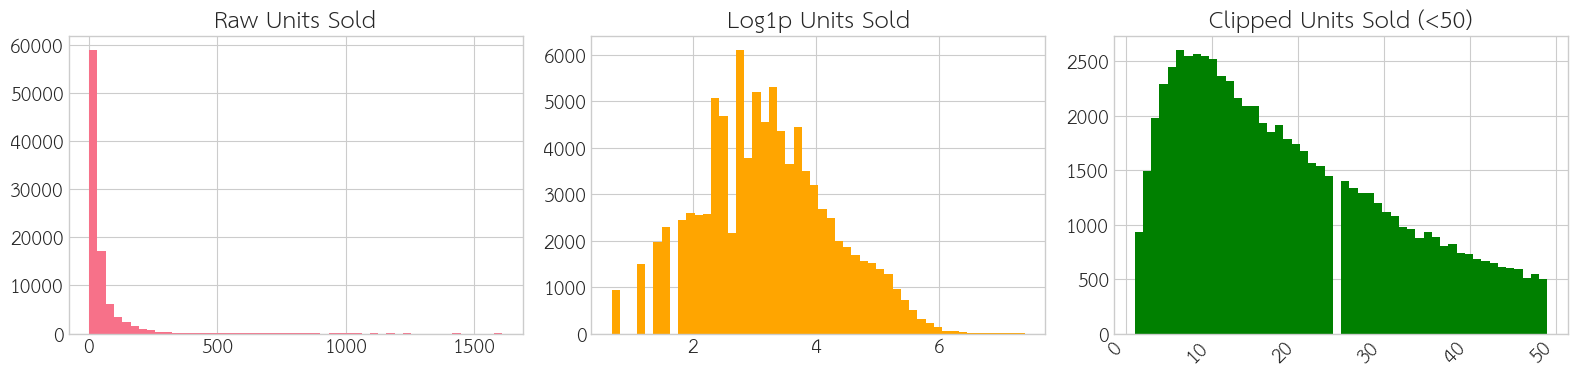

In [3]:
daily = df.groupby(['date', 'store_id', 'category'])['units_sold'].sum().reset_index()
fig, axes = plt.subplots(1,3,figsize=(16,4))
daily['units_sold'].hist(bins=50, ax=axes[0])
axes[0].set_title('Raw Units Sold')
np.log1p(daily['units_sold']).hist(bins=50, ax=axes[1], color='orange')
axes[1].set_title('Log1p Units Sold')
daily[daily['units_sold']<50]['units_sold'].hist(bins=50, ax=axes[2], color='green')
axes[2].set_title('Clipped Units Sold (<50)')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 2: Full Time Series Trend
### แผนภูมิที่ 2: แนวโน้ม Time Series แบบเต็มรูปแบบ

**Description:**
A continuous line plot charting the aggregate daily units sold across the entire historical data window.

**คำอธิบาย:**
กราฟเส้นต่อเนื่องที่แสดงยอดขายรายวันรวมตลอดช่วงข้อมูลประวัติทั้งหมด

**Actionable Insight:**
Exposes the macro trend of the business. If the overall trajectory is flat but features high volatility spikes, the model must rely heavily on external covariates (holidays, promos) rather than autoregressive baseline drift.

**Insight ที่นำไปใช้ได้:**
เผยให้เห็นแนวโน้มมหภาคของธุรกิจ หากแนวโน้มโดยรวมค่อนข้างคงที่แต่มีความผันผวนสูง โมเดลต้องพึ่งพาปัจจัยภายนอก (วันหยุด, โปรโมชัน) มากกว่าการดรีฟต์ autoregressive พื้นฐาน

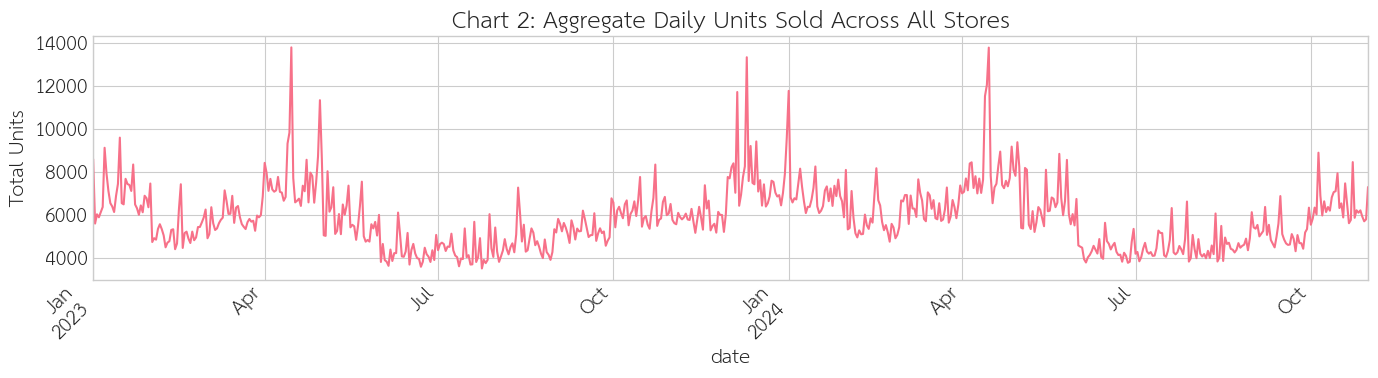

In [4]:
daily_total = df.groupby('date')['units_sold'].sum()
plt.figure(figsize=(14,4))
daily_total.plot()
plt.title('Chart 2: Aggregate Daily Units Sold Across All Stores')
plt.ylabel('Total Units')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 3: Autocorrelation (ACF) of Daily Demand
### แผนภูมิที่ 3: Autocorrelation (ACF) ของความต้องการรายวัน

**Description:**
A correlogram mapping the statistical correlation between today's sales and sales from previous days.

**คำอธิบาย:**
กราฟ correlogram ที่แสดงความสัมพันธ์ทางสถิติระหว่างยอดขายวันนี้กับยอดขายในวันก่อนหน้า

**Actionable Insight:**
Mathematically proves the presence of cyclical patterns. Strong correlations at Lag 7 and Lag 14 dictate that the most powerful predictive features for any tree-based model will be the exact sales volume from one and two weeks prior.

**Insight ที่นำไปใช้ได้:**
พิสูจน์ทางคณิตศาสตร์ถึงการมีอยู่ของรูปแบบวงจร ความสัมพันธ์ที่แข็งแกร่งที่ Lag 7 และ Lag 14 บ่งบอกว่าฟีเจอร์ที่มีพลังทำนายสูงสุดสำหรับโมเดล tree-based คือยอดขายจากหนึ่งและสองสัปดาห์ก่อนหน้า

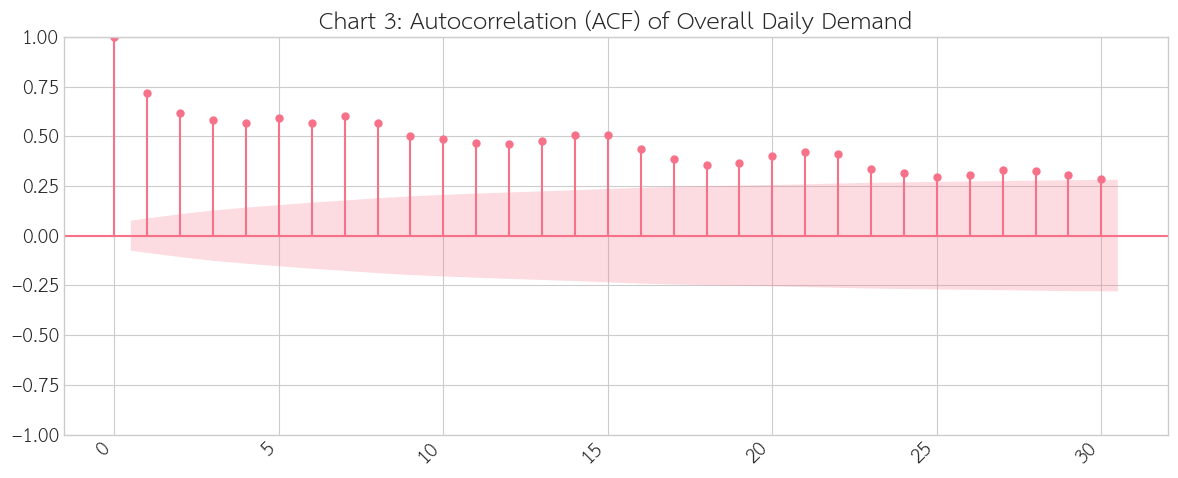

In [5]:
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(12,5))
plot_acf(daily_total, lags=30, ax=plt.gca())
plt.title('Chart 3: Autocorrelation (ACF) of Overall Daily Demand')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 4: Average Daily Revenue (Day vs Month Heatmap)
### แผนภูมิที่ 4: รายได้เฉลี่ยรายวัน (Heatmap วัน vs เดือน)

**Description:**
A 2D calendar heatmap plotting the month on one axis and the day of the month on the other, colored by average revenue.

**คำอธิบาย:**
Heatmap ปฏิทิน 2 มิติที่แสดงเดือนบนแกนหนึ่งและวันของเดือนบนอีกแกน ระบายสีตามรายได้เฉลี่ย

**Actionable Insight:**
Visually exposes macro calendar patterns. If the bottom rows (days 28-31) are significantly brighter, it proves a systemic end-of-month spending surge that a time-series model must capture via specific calendar features.

**Insight ที่นำไปใช้ได้:**
เผยรูปแบบปฏิทินมหภาคอย่างชัดเจน หากแถวล่าง (วันที่ 28-31) สว่างกว่าอย่างมีนัยสำคัญ แสดงว่ามีการใช้จ่ายพุ่งสูงปลายเดือนอย่างเป็นระบบที่โมเดลต้องจับด้วยฟีเจอร์ปฏิทินเฉพาะ

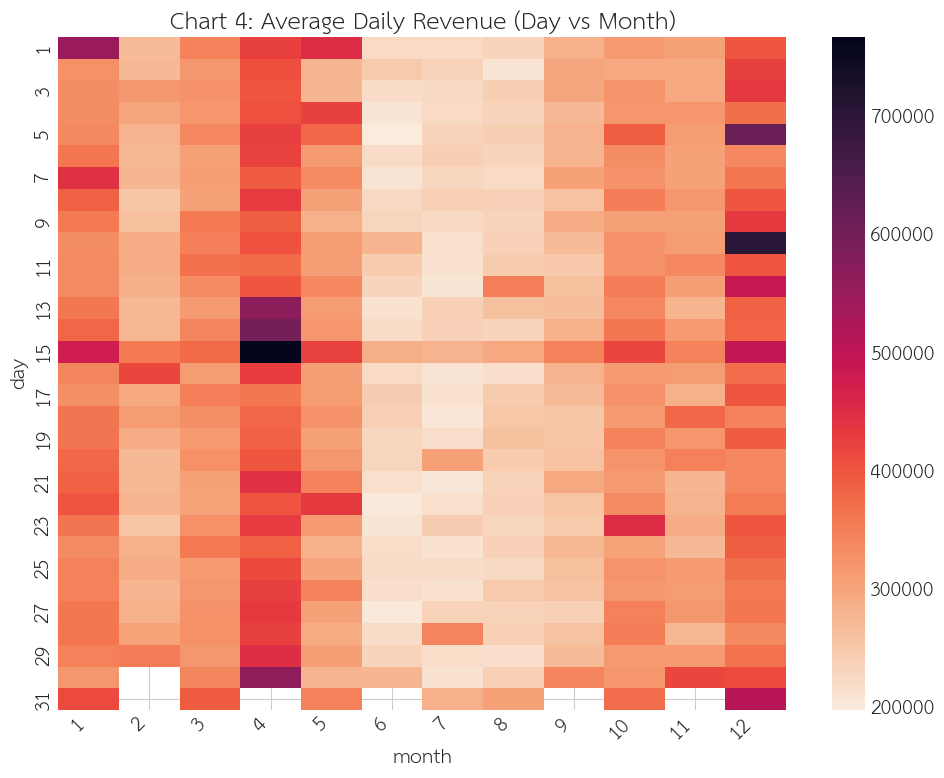

In [6]:
daily_rev = df.groupby('date')['revenue'].sum().reset_index()
daily_rev['day'] = daily_rev['date'].dt.day
daily_rev['month'] = daily_rev['date'].dt.month
sales_cal = daily_rev.pivot_table(index='day', columns='month', values='revenue', aggfunc='mean')
plt.figure(figsize=(10,8))
sns.heatmap(sales_cal, cmap='rocket_r')
plt.title('Chart 4: Average Daily Revenue (Day vs Month)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 5: Revenue Volatility by Store
### แผนภูมิที่ 5: ความผันผวนของรายได้ตามสาขา

**Description:**
A horizontal bar chart ranking every store based on the standard deviation of its daily revenue.

**คำอธิบาย:**
แผนภูมิแท่งแนวนอนที่จัดอันดับทุกสาขาตามค่าเบี่ยงเบนมาตรฐานของรายได้รายวัน

**Actionable Insight:**
Stores with extreme volatility are the primary source of Mean Absolute Error (MAE). Identifying these stores allows for the training of specialized, robust sub-models just for the highly volatile branches.

**Insight ที่นำไปใช้ได้:**
สาขาที่มีความผันผวนสูงเป็นแหล่งหลักของ Mean Absolute Error (MAE) การระบุสาขาเหล่านี้ช่วยให้สามารถฝึกโมเดลย่อยเฉพาะทางสำหรับสาขาที่ผันผวนสูงได้

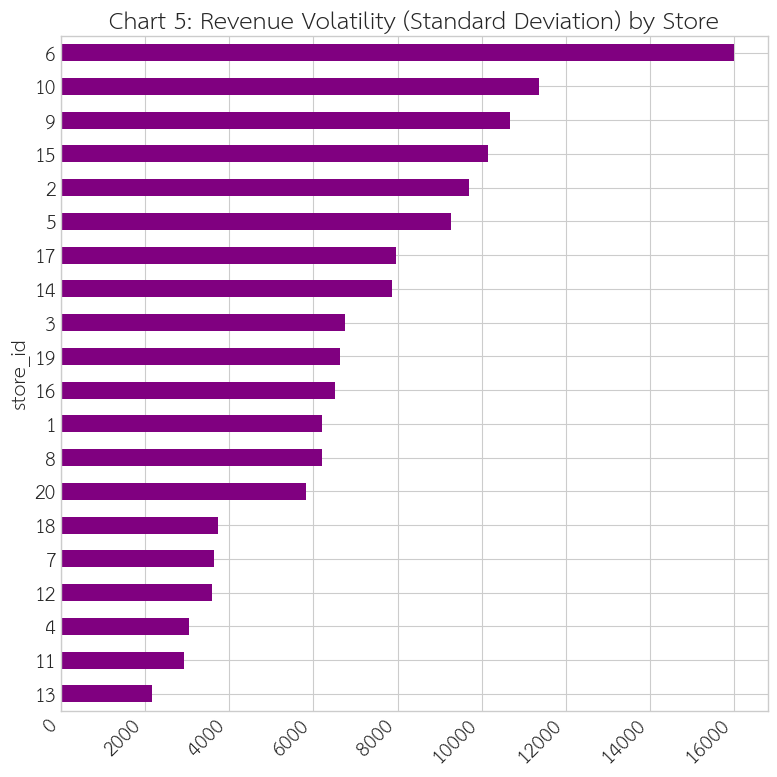

In [7]:
store_volatility = df.groupby(['store_id', 'date'])['revenue'].sum().groupby('store_id').std().sort_values()
plt.figure(figsize=(8,8))
store_volatility.plot(kind='barh', color='purple')
plt.title('Chart 5: Revenue Volatility (Standard Deviation) by Store')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

## Section 2: Calendar & Weather Effects
## หมวดที่ 2: ผลกระทบของปฏิทินและสภาพอากาศ

### Chart 6: Calendar Effects Overview
### แผนภูมิที่ 6: ภาพรวมผลกระทบของปฏิทิน

**Description:**
Boxplots aggregating sales by day of the week to isolate calendar-driven seasonality.

**คำอธิบาย:**
Boxplot ที่รวบรวมยอดขายตามวันในสัปดาห์เพื่อแยกฤดูกาลที่ขับเคลื่อนด้วยปฏิทิน

**Actionable Insight:**
Human consumption of coffee is habitual. Identifying which day of the week represents the global peak allows the model to assign high-weight autoregressive lags to capture weekly repeating patterns.

**Insight ที่นำไปใช้ได้:**
การบริโภคกาแฟของมนุษย์เป็นนิสัย การระบุวันในสัปดาห์ที่เป็นจุดสูงสุดทั่วโลกช่วยให้โมเดลสามารถกำหนดน้ำหนัก lag autoregressive สูงเพื่อจับรูปแบบที่ซ้ำทุกสัปดาห์

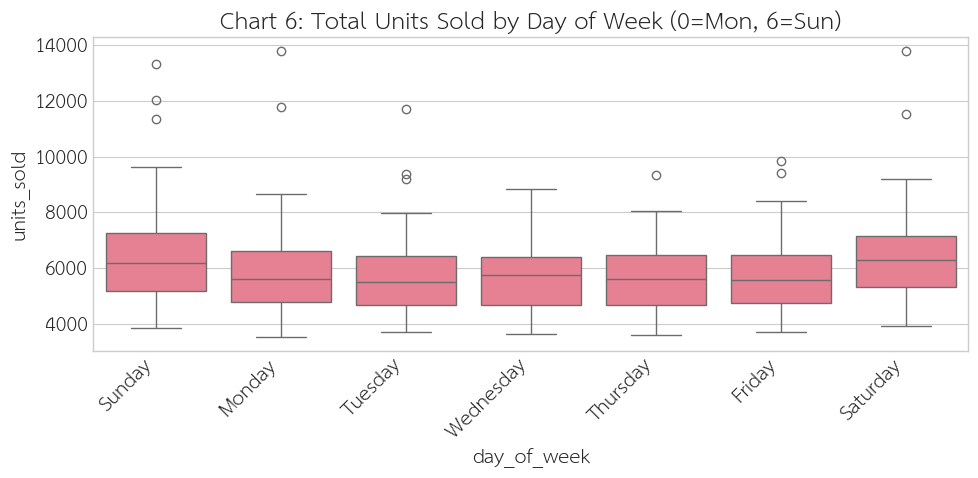

In [8]:
dow_df = df.merge(date_dim[['date', 'day_of_week']], on='date')
dow_sales = dow_df.groupby(['date', 'day_of_week'])['units_sold'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.boxplot(data=dow_sales, x='day_of_week', y='units_sold')
plt.title('Chart 6: Total Units Sold by Day of Week (0=Mon, 6=Sun)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 6.5: 90-Day 'Bridge Holiday' Exodus
### แผนภูมิที่ 6.5: การอพยพ 'วันหยุดสะพาน' 90 วัน

**Description:**
A 90-day time-series (April - June) tracking an Office store versus a Residential store. Gray dashed lines indicate Public Holidays.

**คำอธิบาย:**
Time-series 90 วัน (เมษายน - มิถุนายน) ติดตามสาขา Office เทียบกับสาขา Residential เส้นประสีเทาบ่งชี้วันหยุดราชการ

**Actionable Insight (Product/Solution Opportunity):**
When a holiday falls on a Wednesday or Thursday, the adjacent Friday becomes a 'Bridge Holiday'. The chart proves that Office branch sales completely die on these Fridays (as workers take leave), while Residential sales boom. The solution is a **'Smart Holiday Staff Roster'** that detects Bridge Holidays and automatically slashes staff and fresh pastry inventory at Office branches, reallocating them to Residential branches.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
เมื่อวันหยุดตกในวันพุธหรือพฤหัสบดี วันศุกร์ถัดมากลายเป็น 'วันหยุดสะพาน' กราฟพิสูจน์ว่ายอดขายสาขา Office ดับสนิทในวันศุกร์นั้น (เพราะพนักงานลาหยุด) ในขณะที่สาขา Residential เพิ่มสูง วิธีแก้คือ **'Smart Holiday Staff Roster'** ที่ตรวจจับวันหยุดสะพานและลดพนักงานและสต็อกเบเกอรี่สดที่สาขา Office อัตโนมัติ พร้อมโยกทรัพยากรไปสาขา Residential

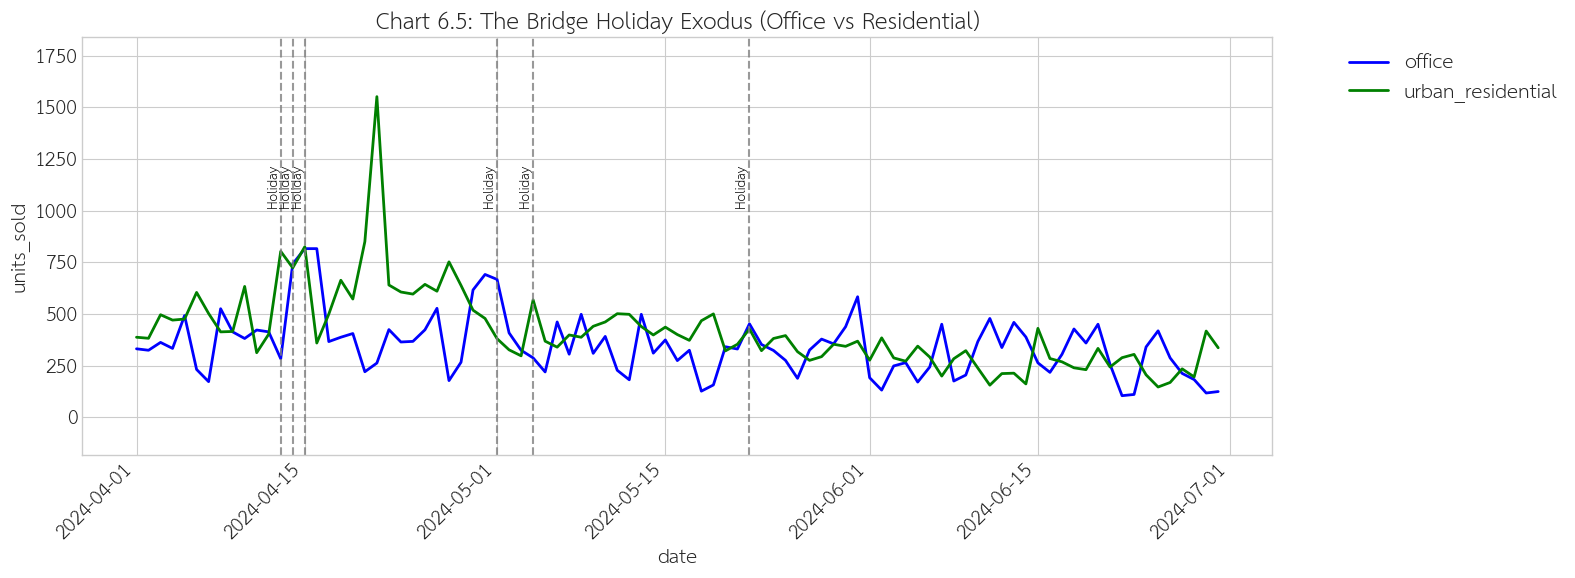

In [9]:
q2_bridge = df[(df['date'] >= '2024-04-01') & (df['date'] <= '2024-06-30')]
office = store[store['neighborhood_type'] == 'office']['store_id'].unique()[0]
res = store[store['neighborhood_type'] == 'urban_residential']['store_id'].unique()[0]
bridge_ts = q2_bridge[q2_bridge['store_id'].isin([office, res])].groupby(['date', 'neighborhood_type'])['units_sold'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=bridge_ts, x='date', y='units_sold', hue='neighborhood_type', palette=['blue', 'green'], linewidth=2)
holidays = date_dim[(date_dim['date'] >= '2024-04-01') & (date_dim['date'] <= '2024-06-30') & (date_dim['is_holiday'])]
for d in holidays['date']:
    plt.axvline(d, color='gray', linestyle='--', alpha=0.8)
    plt.text(d, plt.ylim()[1]*0.75, ' Holiday', color='black', rotation=90, va='top', ha='right', fontsize=9)
plt.title('Chart 6.5: The Bridge Holiday Exodus (Office vs Residential)', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Chart 7: Day-of-Week Volatility by Store
### แผนภูมิที่ 7: ความผันผวนตามวันในสัปดาห์แยกตามสาขา

**Description:**
A boxplot distribution of daily revenue across the 7 days of the week for a sample of stores, heavily emphasizing the variance.

**คำอธิบาย:**
การกระจาย Boxplot ของรายได้รายวันตลอด 7 วันในสัปดาห์สำหรับกลุ่มตัวอย่างสาขา โดยเน้นที่ความแปรปรวน

**Actionable Insight:**
Shows which days are highly unpredictable. If Friday has massive variance, the model's confidence interval for Fridays must be widened. Predictability is not uniform across the week.

**Insight ที่นำไปใช้ได้:**
แสดงให้เห็นว่าวันใดคาดเดาได้ยาก หากวันศุกร์มีความแปรปรวนมาก ช่วงความเชื่อมั่นของโมเดลสำหรับวันศุกร์ต้องกว้างขึ้น ความสามารถในการทำนายไม่สม่ำเสมอตลอดทั้งสัปดาห์

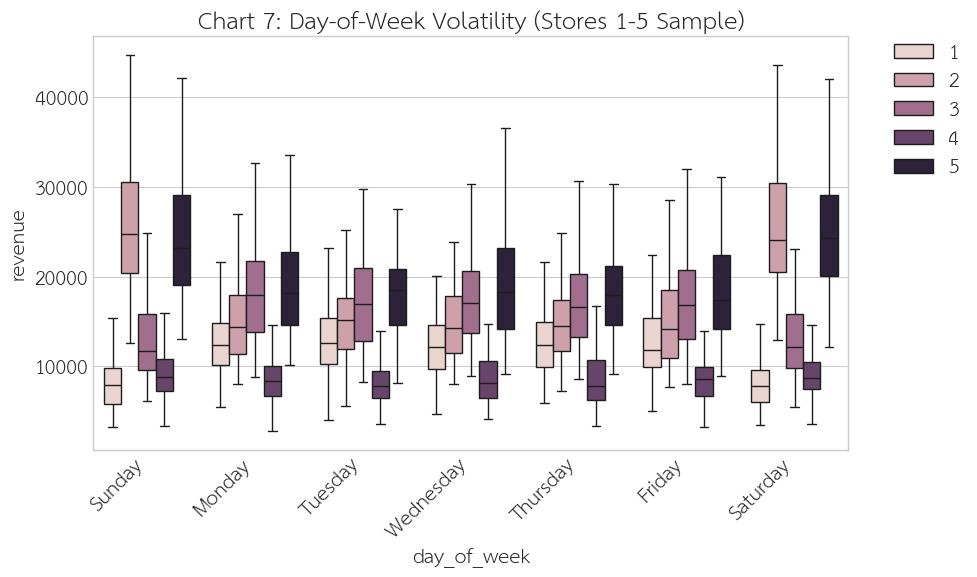

In [10]:
dow_vol_store = dow_df.groupby(['store_id', 'date', 'day_of_week'])['revenue'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.boxplot(data=dow_vol_store[dow_vol_store['store_id'] <= 5], x='day_of_week', y='revenue', hue='store_id', showfliers=False)
plt.title('Chart 7: Day-of-Week Volatility (Stores 1-5 Sample)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 8: Impact of Rainy Season by Neighborhood
### แผนภูมิที่ 8: ผลกระทบของฤดูฝนตามประเภทย่าน

**Description:**
An interaction plot demonstrating how the Rainy Season alters the volume of sales across different store neighborhood types.

**คำอธิบาย:**
Interaction plot แสดงให้เห็นว่าฤดูฝนเปลี่ยนแปลงปริมาณการขายในประเภทย่านที่ตั้งสาขาต่างๆ อย่างไร

**Actionable Insight:**
Weather acts as an asymmetric substitute driver. Rain might cripple foot-traffic at Tourist locations while boosting Office locations. The model needs an interaction term to avoid applying a universal weather penalty.

**Insight ที่นำไปใช้ได้:**
สภาพอากาศทำหน้าที่เป็นตัวขับเคลื่อนทดแทนแบบไม่สมมาตร ฝนอาจทำลาย foot-traffic ที่สาขา Tourist ในขณะที่บูสต์สาขา Office โมเดลต้องการ interaction term เพื่อหลีกเลี่ยงการใช้ weather penalty สากล

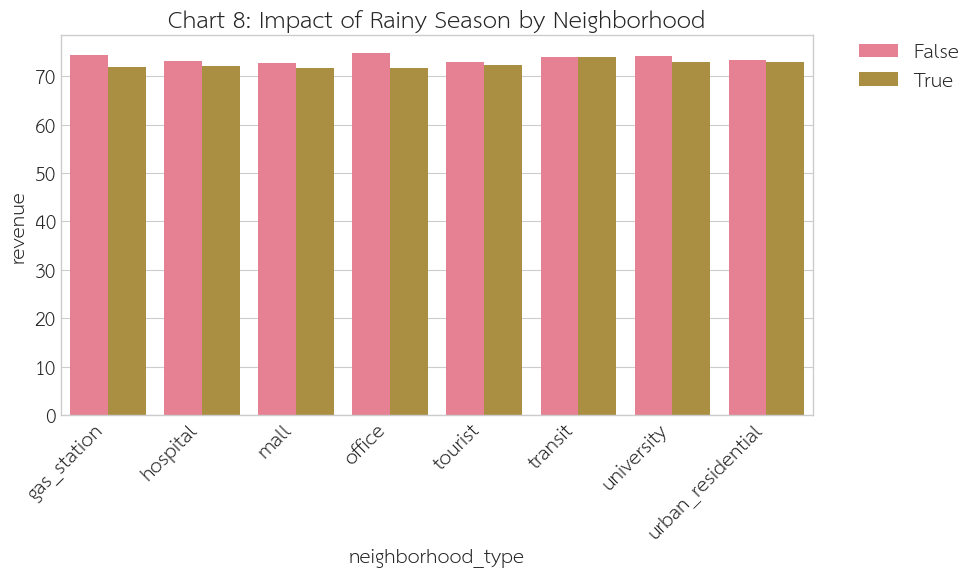

In [11]:
rainy_df = df.merge(date_dim[['date', 'is_rainy_season']], on='date')
rainy_impact = rainy_df.groupby(['neighborhood_type', 'is_rainy_season'])['revenue'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=rainy_impact, x='neighborhood_type', y='revenue', hue='is_rainy_season')
plt.title('Chart 8: Impact of Rainy Season by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 9: Serve Type Performance in Rainy Season
### แผนภูมิที่ 9: ประสิทธิภาพประเภทการเสิร์ฟในฤดูฝน

**Description:**
A clustered bar chart comparing the average daily units sold of Hot vs. Iced vs. Frappe beverages, toggled by the rainy season flag.

**คำอธิบาย:**
แผนภูมิแท่งแบบกลุ่มที่เปรียบเทียบยอดขายรายวันเฉลี่ยของเครื่องดื่ม Hot vs. Iced vs. Frappe แยกตามช่วงฤดูฝน

**Actionable Insight:**
Weather drastically alters the product mix. While overall sales might drop during rain, Hot beverages spike. An AutoGluon model predicting at the Product Level needs the Serve_Type x Rainy_Season interaction to shift volume accurately.

**Insight ที่นำไปใช้ได้:**
สภาพอากาศเปลี่ยนส่วนผสมสินค้าอย่างรุนแรง แม้ยอดขายรวมอาจลดลงในช่วงฝน แต่เครื่องดื่ม Hot จะพุ่งสูง โมเดลที่ทำนายระดับสินค้าต้องการ Serve_Type × Rainy_Season interaction เพื่อปรับ volume ได้อย่างแม่นยำ

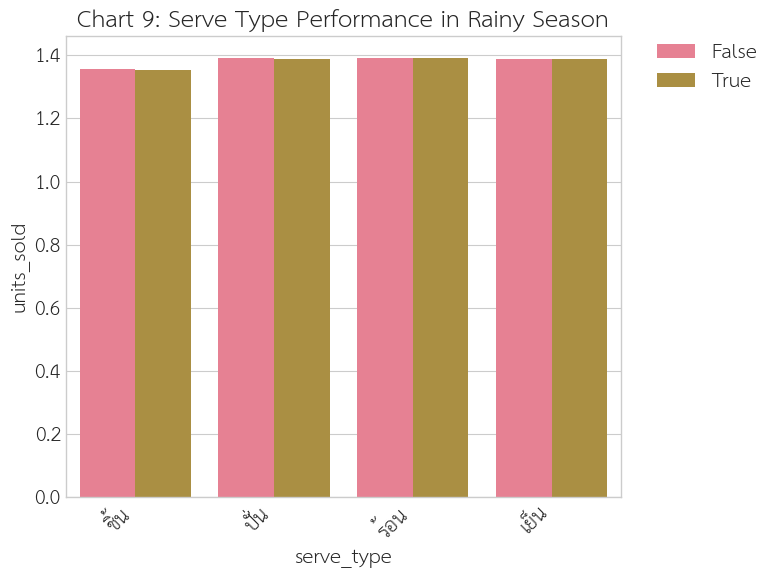

In [12]:
serve_weather = rainy_df.groupby(['serve_type', 'is_rainy_season'])['units_sold'].mean().reset_index()
plt.figure(figsize=(8,6))
sns.barplot(data=serve_weather, x='serve_type', y='units_sold', hue='is_rainy_season')
plt.title('Chart 9: Serve Type Performance in Rainy Season')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 9.5: 90-Day Weather Disruption Dynamics (Drive-Through vs Transit)
### แผนภูมิที่ 9.5: พลวัตการหยุดชะงักจากสภาพอากาศ 90 วัน (Drive-Through vs Transit)

**Description:**
A 90-day time-series focusing on the Peak Rainy Season (August 1 - October 31, 2023). This chart contrasts the daily revenue of a typical Drive-Through store against a Walk-in Transit store, with blue shaded regions indicating the active rainy season block.

**คำอธิบาย:**
Time-series 90 วันช่วงพีคฤดูฝน (1 ส.ค. - 31 ต.ค. 2566) เปรียบเทียบรายได้รายวันของสาขา Drive-Through ปกติกับสาขา Walk-in Transit โดยมีพื้นที่สีน้ำเงินบ่งชี้ช่วงฤดูฝนที่กำลังดำเนินอยู่

**Actionable Insight (Product/Solution Opportunity):**
This is the foundation for a **'Weather-Adaptive Supply Routing System'**. Basic bar charts show overall weather penalties, but this time-series visually proves demand transfer. Notice how Transit store revenue drops during prolonged rain blocks, while Drive-Through revenue simultaneously spikes as customers refuse to walk in the rain. By feeding weather forecasts into the ML model, the business can automatically reroute fresh pastry deliveries from Transit branches to Drive-Through branches, preventing waste and capturing the transferred demand.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
นี่คือรากฐานของ **'Weather-Adaptive Supply Routing System'** กราฟแท่งพื้นฐานแสดงเพียง weather penalty รวม แต่ time-series นี้พิสูจน์ด้วยภาพถึงการโอนย้ายความต้องการ สาขา Transit ลดลงช่วงฝนนาน ขณะที่สาขา Drive-Through พุ่งสูงพร้อมกันเพราะลูกค้าไม่อยากเดินกลางฝน ด้วยการป้อนพยากรณ์อากาศเข้าโมเดล ML ธุรกิจสามารถกำหนดเส้นทางขนส่งเบเกอรี่สดจากสาขา Transit ไปยังสาขา Drive-Through ได้อัตโนมัติ ป้องกันของเสียและจับความต้องการที่ย้ายมา

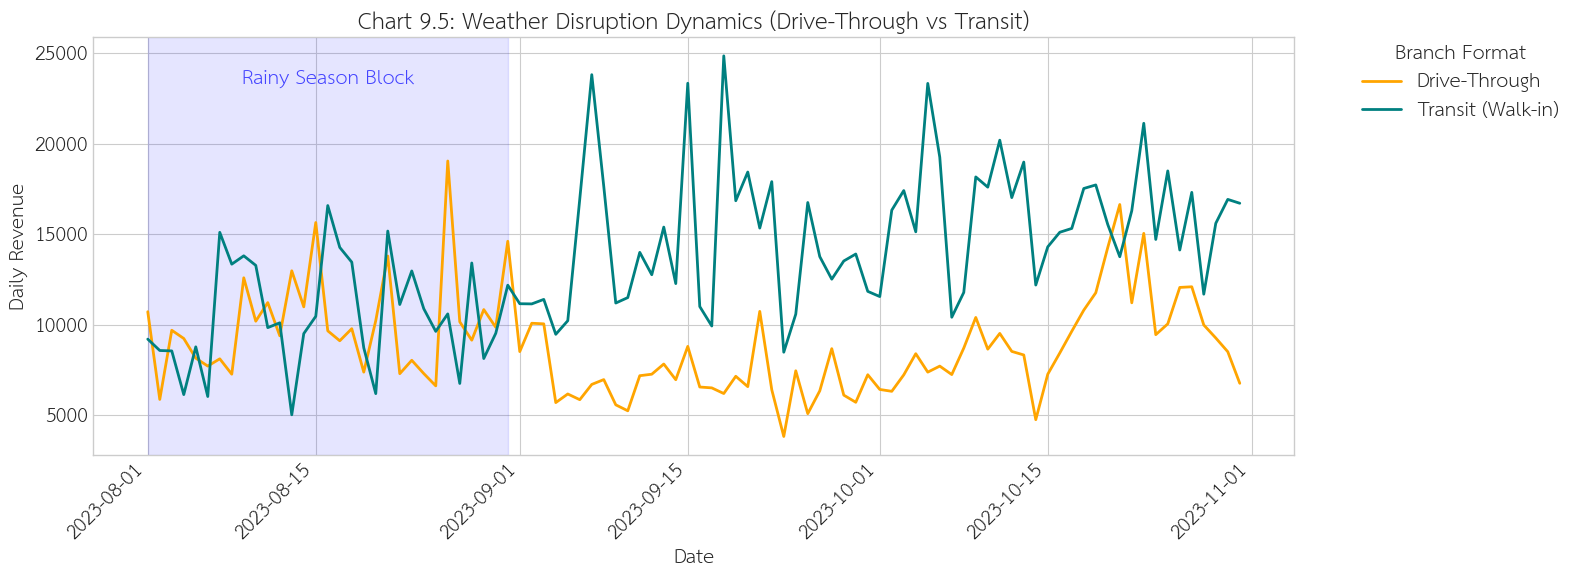

In [13]:
q3_weather = df[(df['date'] >= '2023-08-01') & (df['date'] <= '2023-10-31')].copy()
dt_stores = store[store['has_drive_through'] == True]['store_id'].unique()
transit_stores = store[store['neighborhood_type'] == 'transit']['store_id'].unique()

sample_dt = dt_stores[0] if len(dt_stores) > 0 else 1
sample_tr = transit_stores[0] if len(transit_stores) > 0 else 2

weather_ts = q3_weather[q3_weather['store_id'].isin([sample_dt, sample_tr])].groupby(['date', 'store_id', 'has_drive_through'])['revenue'].sum().reset_index()
weather_ts['Store_Type'] = weather_ts['has_drive_through'].map({True: 'Drive-Through', False: 'Transit (Walk-in)'})

plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=weather_ts, x='date', y='revenue', hue='Store_Type', palette=['orange', 'teal'], linewidth=2)

rain_days = date_dim[(date_dim['date'] >= '2023-08-01') & (date_dim['date'] <= '2023-10-31') & (date_dim['is_rainy_season'])]
if not rain_days.empty:
    rain_groups = (rain_days['date'] != rain_days['date'].shift(1) + pd.Timedelta(days=1)).cumsum()
    for _, group in rain_days.groupby(rain_groups):
        plt.axvspan(group['date'].min(), group['date'].max(), color='blue', alpha=0.1)
        plt.text(group['date'].min() + (group['date'].max() - group['date'].min())/2, plt.ylim()[1]*0.9, 'Rainy Season Block', color='blue', ha='center', alpha=0.7)

plt.title('Chart 9.5: Weather Disruption Dynamics (Drive-Through vs Transit)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Revenue')
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Branch Format')
plt.tight_layout()
plt.show()

### Chart 10: Payday Splurge Effect by Neighborhood
### แผนภูมิที่ 10: ผลกระทบการใช้จ่ายฟุ่มเฟือยวันเงินเดือนตามย่าน

**Description:**
A barplot comparing average daily revenue on regular days versus Paydays, split geographically.

**คำอธิบาย:**
Barplot เปรียบเทียบรายได้รายวันเฉลี่ยในวันธรรมดาเทียบกับวันเงินเดือน แยกตามภูมิศาสตร์

**Actionable Insight:**
The Payday effect is drastically amplified in Office and Hospital locations compared to Transit locations. A generic payday feature will incorrectly boost predictions for all stores equally.

**Insight ที่นำไปใช้ได้:**
ผลกระทบวันเงินเดือนขยายตัวอย่างมากในสาขา Office และ Hospital เมื่อเทียบกับสาขา Transit ฟีเจอร์วันเงินเดือนทั่วไปจะบูสต์การทำนายทุกสาขาเท่ากันอย่างผิดพลาด

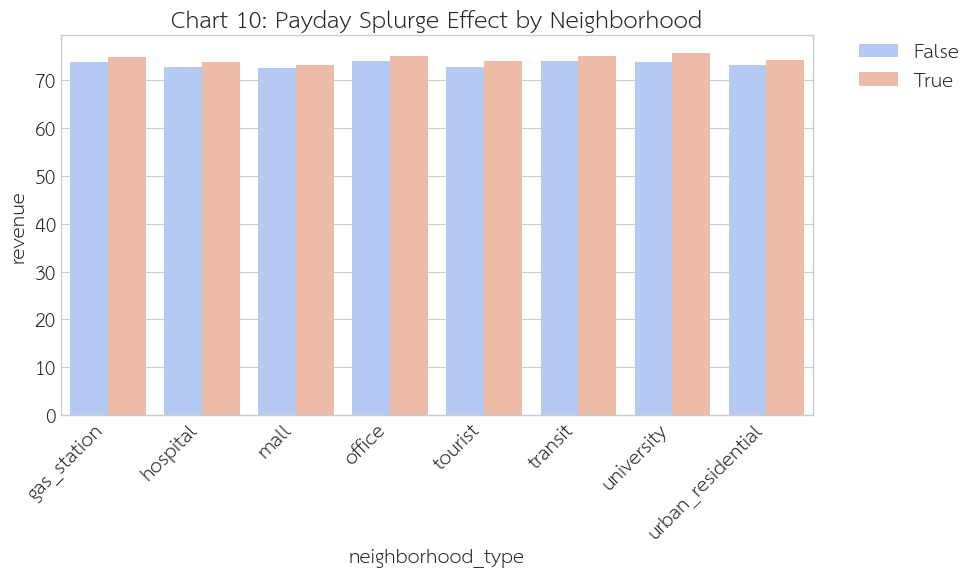

In [14]:
payday_df = df.merge(date_dim[['date', 'is_payday']], on='date')
payday_impact = payday_df.groupby(['neighborhood_type', 'is_payday'])['revenue'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=payday_impact, x='neighborhood_type', y='revenue', hue='is_payday', palette='coolwarm')
plt.title('Chart 10: Payday Splurge Effect by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 11: School Break Effect
### แผนภูมิที่ 11: ผลกระทบของปิดเทอม

**Description:**
An assessment of demand shifts during official school holiday periods.

**คำอธิบาย:**
การประเมินการเปลี่ยนแปลงความต้องการในช่วงปิดเทอมราชการ

**Actionable Insight:**
School breaks alter the geographic distribution of demand. Stores near universities will see structural crashes, while mall stores will see sustained elevated baselines. This requires a School_Break x Store_Location interaction.

**Insight ที่นำไปใช้ได้:**
ปิดเทอมเปลี่ยนการกระจายทางภูมิศาสตร์ของความต้องการ สาขาใกล้มหาวิทยาลัยจะเห็นยอดดิ่งลงเชิงโครงสร้าง ในขณะที่สาขาห้างสรรพสินค้าจะเห็นยอดพื้นฐานสูงขึ้นต่อเนื่อง ต้องการ School_Break × Store_Location interaction

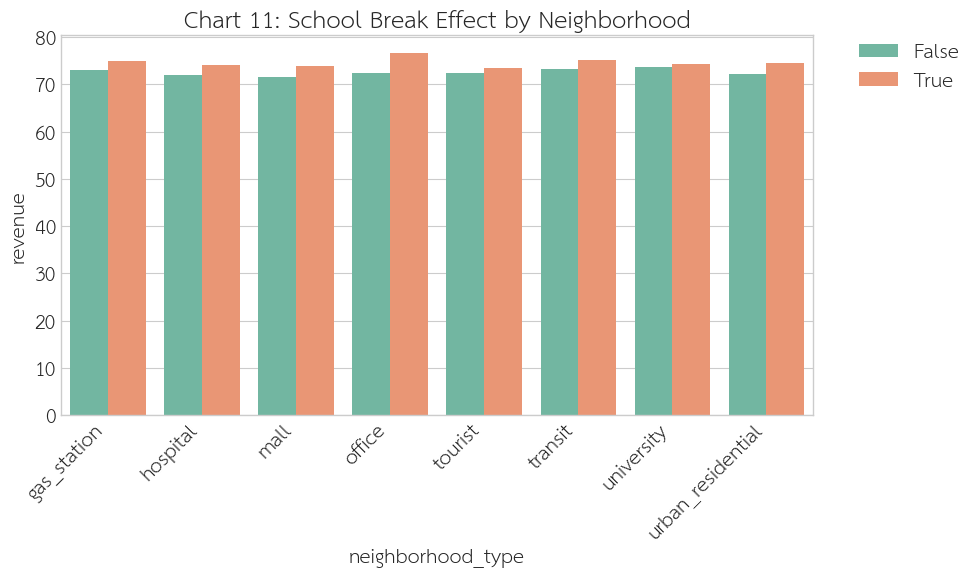

In [15]:
sb_df = df.merge(date_dim[['date', 'is_school_break']], on='date')
sb_impact = sb_df.groupby(['neighborhood_type', 'is_school_break'])['revenue'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=sb_impact, x='neighborhood_type', y='revenue', hue='is_school_break', palette='Set2')
plt.title('Chart 11: School Break Effect by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 12: Weekend Revenue Uplift % by Neighborhood
### แผนภูมิที่ 12: % การเพิ่มขึ้นของรายได้วันหยุดสุดสัปดาห์ตามย่าน

**Description:**
A bar chart isolating the percentage revenue multiplier achieved on weekends relative to the weekday baseline.

**คำอธิบาย:**
แผนภูมิแท่งที่แยกตัวคูณรายได้เปอร์เซ็นต์ที่ทำได้ในวันหยุดสุดสัปดาห์เมื่อเทียบกับค่าพื้นฐานวันธรรมดา

**Actionable Insight:**
Office locations suffer a massive negative uplift on weekends, while Tourist locations experience positive uplift. Applying a raw weekend feature destroys accuracy without interacting it with the store's geography.

**Insight ที่นำไปใช้ได้:**
สาขา Office ประสบการเพิ่มขึ้นติดลบอย่างมากในวันหยุดสุดสัปดาห์ ขณะที่สาขา Tourist ประสบการเพิ่มขึ้นเชิงบวก การใช้ฟีเจอร์วันหยุดสุดสัปดาห์แบบดิบๆ จะทำลายความแม่นยำหากไม่ทำ interaction กับภูมิศาสตร์ของสาขา

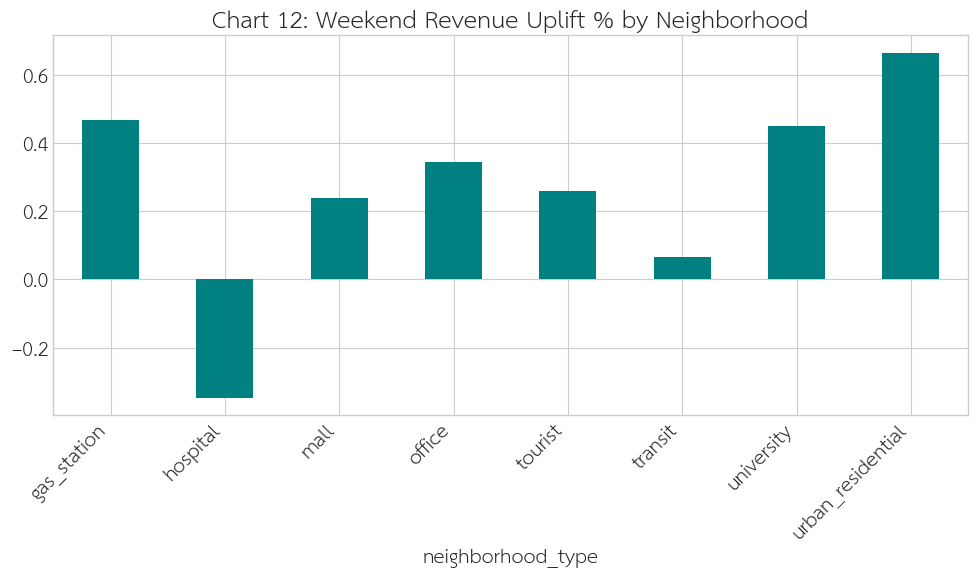

In [16]:
wknd_df = df.merge(date_dim[['date', 'is_weekend']], on='date')
wknd_impact = wknd_df.groupby(['neighborhood_type', 'is_weekend'])['revenue'].mean().unstack()
wknd_impact['uplift_pct'] = (wknd_impact[True] - wknd_impact[False]) / wknd_impact[False] * 100
plt.figure(figsize=(10,6))
wknd_impact['uplift_pct'].plot(kind='bar', color='teal')
plt.title('Chart 12: Weekend Revenue Uplift % by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 12.5: 90-Day Time-Series Dynamics (Paydays & School Breaks)
### แผนภูมิที่ 12.5: พลวัต Time-Series 90 วัน (วันเงินเดือนและปิดเทอม)

**Description:**
A highly detailed 90-day time-series slice (March 1 - May 31, 2024) tracking the daily revenue of 20 distinct store branches, color-coded by their neighborhood type. Vertical dashed lines represent Paydays, and the red shaded regions highlight the massive Thai Summer School Break.

**คำอธิบาย:**
ส่วนตัด time-series 90 วันที่ละเอียดมาก (1 มี.ค. - 31 พ.ค. 2567) ติดตามรายได้รายวันของ 20 สาขาเฉพาะ ระบายสีตามประเภทย่าน เส้นประแนวตั้งแทนวันเงินเดือน พื้นที่สีแดงเน้นช่วงปิดเทอมฤดูร้อนไทยขนาดใหญ่

**Actionable Insight (Product/Solution Opportunity):**
This is the ultimate operational view. Notice how University stores (and some Transit) crash into the red zone during the School Break, while Mall/Residential stores might remain stable or rise. By clustering these 20 stores based on their visual waveform, you can build a **'Dynamic Roster Product'** (shifting baristas from University branches to Mall branches during mid-March to May) or an **'Automated Inventory Rebalancer'** (cutting pastry orders for University branches by 60% before the red zone hits). Furthermore, Payday spikes (blue lines) prove that short-term promotions should be targeted exclusively around the 1st and 16th to maximize the FOMO effect when customers have high purchasing power.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
นี่คือมุมมองปฏิบัติการขั้นสูงสุด สาขา University (และบาง Transit) ดิ่งสู่โซนแดงในช่วงปิดเทอม ในขณะที่สาขา Mall/Residential อาจคงที่หรือเพิ่มขึ้น ด้วยการ cluster สาขาตาม waveform สามารถสร้าง **'Dynamic Roster Product'** (ย้ายบาริสต้าจากสาขามหาวิทยาลัยไปห้าง กลางมีนาคมถึงพฤษภาคม) หรือ **'Automated Inventory Rebalancer'** (ลดออเดอร์เบเกอรี่ที่สาขามหาวิทยาลัย 60% ก่อนโซนแดง) นอกจากนี้สไปก์วันเงินเดือน (เส้นสีน้ำเงิน) พิสูจน์ว่าโปรโมชันระยะสั้นควร target รอบวันที่ 1 และ 16 เพื่อเพิ่ม FOMO สูงสุดเมื่อลูกค้ามีกำลังซื้อสูง

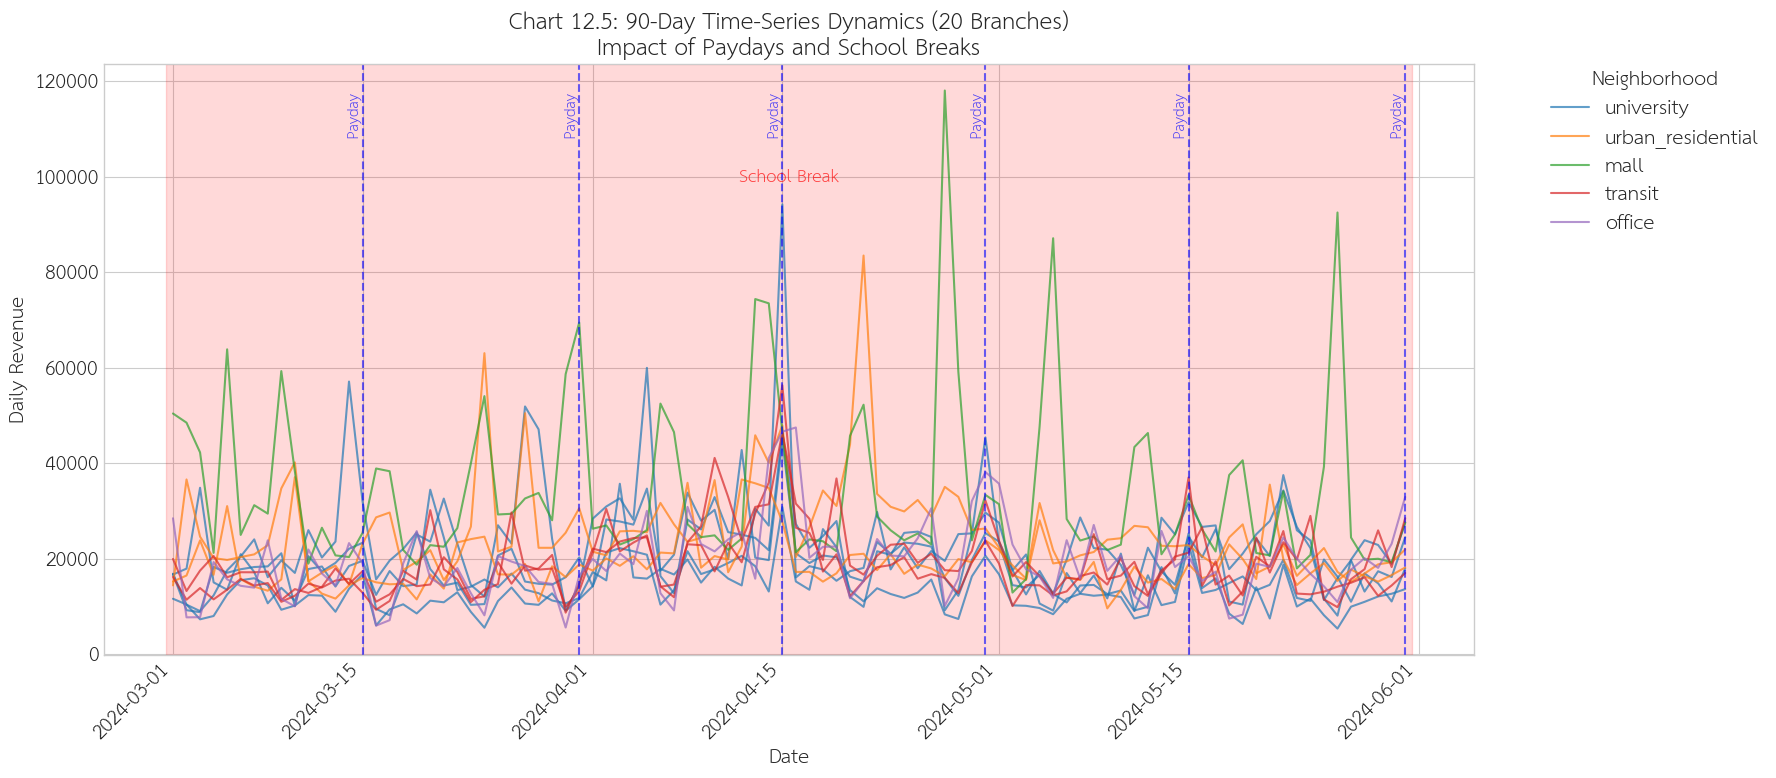

In [17]:
# Filter Data to Q2 2024 (90 Days) to capture both Paydays and Summer School Break
q2_df = df[(df['date'] >= '2024-03-01') & (df['date'] <= '2024-05-31')].copy()

# Select 20 specific stores across different neighborhoods to avoid a messy spaghetti chart
np.random.seed(42)
selected_stores = []
for n_type in ['university', 'mall', 'office', 'transit', 'urban_residential']:
    stores_in_type = store[store['neighborhood_type'] == n_type]['store_id'].unique()
    if len(stores_in_type) > 0:
        selected_stores.extend(np.random.choice(stores_in_type, min(4, len(stores_in_type)), replace=False))

ts_data = q2_df[q2_df['store_id'].isin(selected_stores)].groupby(['date', 'store_id', 'neighborhood_type'])['revenue'].sum().reset_index()

plt.figure(figsize=(18, 8))
ax = sns.lineplot(data=ts_data, x='date', y='revenue', hue='neighborhood_type', units='store_id', estimator=None, alpha=0.7, linewidth=1.5, palette='tab10')

# Highlight Paydays (Vertical Dashed Lines)
paydays = date_dim[(date_dim['date'] >= '2024-03-01') & (date_dim['date'] <= '2024-05-31') & (date_dim['is_payday'])]
for d in paydays['date']:
    plt.axvline(d, color='blue', linestyle='--', alpha=0.6)
    plt.text(d, plt.ylim()[1]*0.95, ' Payday', color='blue', rotation=90, va='top', ha='right', fontsize=10, alpha=0.7)

# Highlight School Breaks (Red Shaded Regions)
breaks = date_dim[(date_dim['date'] >= '2024-03-01') & (date_dim['date'] <= '2024-05-31') & (date_dim['is_school_break'])]
if not breaks.empty:
    break_groups = (breaks['date'] != breaks['date'].shift(1) + pd.Timedelta(days=1)).cumsum()
    for _, group in breaks.groupby(break_groups):
        start_date = group['date'].min() - pd.Timedelta(hours=12)
        end_date = group['date'].max() + pd.Timedelta(hours=12)
        plt.axvspan(start_date, end_date, color='red', alpha=0.15)
        plt.text(start_date + (end_date - start_date)/2, plt.ylim()[1]*0.8, 'School Break', color='red', ha='center', fontsize=12, fontweight='bold', alpha=0.7)

plt.title('Chart 12.5: 90-Day Time-Series Dynamics (20 Branches)\nImpact of Paydays and School Breaks', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Revenue')
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Neighborhood')
plt.tight_layout()
plt.show()

## Section 3: Promotions & Cannibalization
## หมวดที่ 3: โปรโมชันและการกินส่วนแบ่ง (Cannibalization)

In [18]:
# Promotion Data Preparation
daily_sales = df.groupby(['store_id', 'date', 'category'])['units_sold'].sum().reset_index()
daily_sales = daily_sales.merge(date_dim[['date', 'day_of_week']], on='date', how='left')

promo_expanded = []
for _, r in promo.iterrows():
    dates = pd.date_range(r['start_date'], r['end_date'])
    for d in dates:
        promo_expanded.append({
            'store_id': r['store_id'], 'date': d, 'product_id': r['product_id'],
            'promo_type': r['promo_type'], 'discount_pct': r['discount_pct'],
            'email_sent': r['email_sent'], 'social_campaign': r['social_campaign']
        })
promo_df = pd.DataFrame(promo_expanded).drop_duplicates(subset=['store_id', 'date', 'product_id'])
promo_df = promo_df.merge(prod[['product_id', 'category']], on='product_id', how='left')
promo_daily = promo_df.groupby(['store_id', 'date', 'category']).agg({
    'promo_type': 'first', 'discount_pct': 'max', 'email_sent': 'max', 'social_campaign': 'max'
}).reset_index()

daily_promo = daily_sales.merge(promo_daily, on=['store_id', 'date', 'category'], how='left')
daily_promo['has_promo'] = daily_promo['promo_type'].notna()

### Chart 13: Units Sold by Promotion Type
### แผนภูมิที่ 13: ยอดขายตามประเภทโปรโมชัน

**Description:**
A comparative boxplot mapping the daily volume of items sold against the specific type of promotion active on that day.

**คำอธิบาย:**
Boxplot เปรียบเทียบปริมาณสินค้าที่ขายได้รายวันกับประเภทโปรโมชันที่ใช้งานในวันนั้น

**Actionable Insight:**
Not all promotions are created equal. Buy One Get One (BOGO) heavily inflates the units sold target variable but halves the average unit revenue. Recognizing which promo mechanic yields the highest raw volume lift is essential for accurate demand planning.

**Insight ที่นำไปใช้ได้:**
โปรโมชันไม่ได้เท่ากันทั้งหมด Buy One Get One (BOGO) เพิ่มยอดขายอย่างมากแต่ลดรายได้ต่อหน่วยลงครึ่งหนึ่ง การรู้ว่ากลไกโปรโมชันใดให้ volume lift สูงสุดเป็นสิ่งสำคัญสำหรับการวางแผนความต้องการที่แม่นยำ

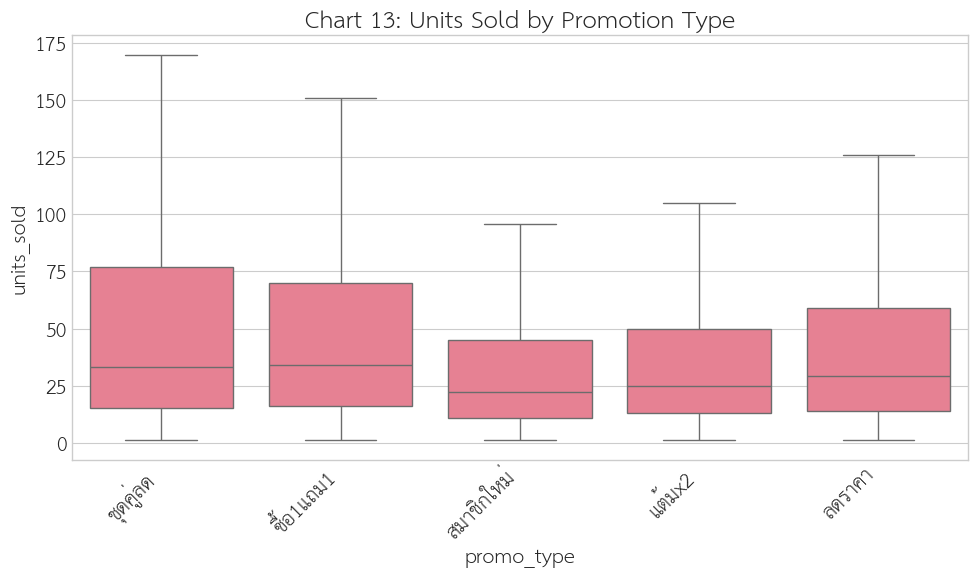

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=daily_promo[daily_promo['has_promo']], x='promo_type', y='units_sold', showfliers=False)
plt.title('Chart 13: Units Sold by Promotion Type')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 14: Average Units Sold by Discount Tier
### แผนภูมิที่ 14: ยอดขายเฉลี่ยตามระดับส่วนลด

**Description:**
A barplot grouping active promotions into distinct percentage-off buckets to observe the corresponding sales volume.

**คำอธิบาย:**
Barplot จัดกลุ่มโปรโมชันที่ใช้งานออกเป็นระดับเปอร์เซ็นต์ส่วนลดต่างๆ เพื่อดูปริมาณขายที่สอดคล้อง

**Actionable Insight:**
Identifies the psychological discount sweet spot. In many environments, a minor 10% discount creates the exact same customer urgency as a massive 30% discount. The model needs to learn these non-linear thresholds to avoid over-forecasting deep discounts.

**Insight ที่นำไปใช้ได้:**
ระบุจุดหวาน (sweet spot) ทางจิตวิทยาของส่วนลด ในหลายสภาพแวดล้อม ส่วนลดเล็กน้อย 10% สร้างความเร่งด่วนแก่ลูกค้าเท่ากับส่วนลด 30% โมเดลต้องเรียนรู้เกณฑ์ไม่เชิงเส้นเหล่านี้เพื่อหลีกเลี่ยงการทำนายส่วนลดลึกสูงเกินจริง

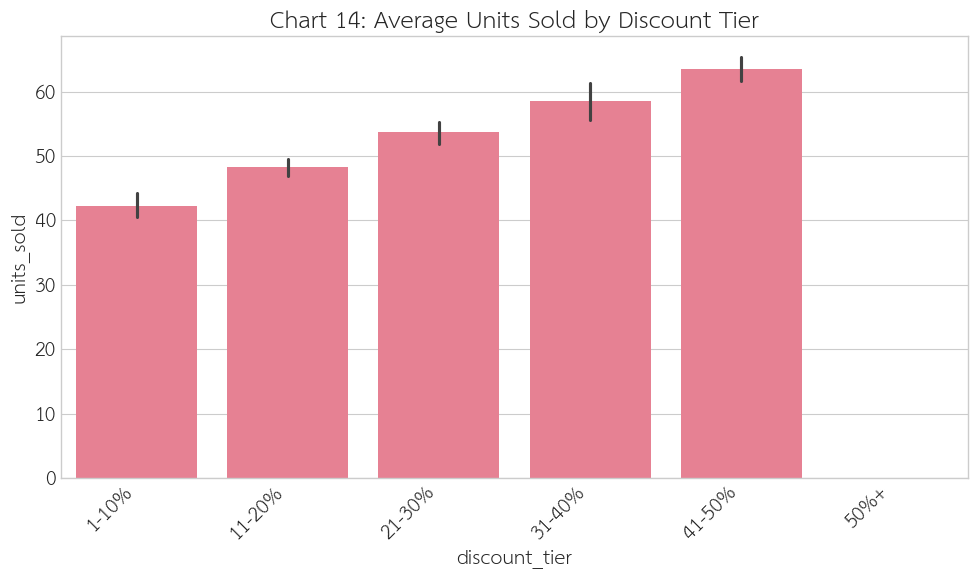

In [20]:
daily_promo['discount_tier'] = pd.cut(daily_promo['discount_pct'], bins=[0, 10, 20, 30, 40, 50, 100], labels=['1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '50%+'])
plt.figure(figsize=(10,6))
sns.barplot(data=daily_promo, x='discount_tier', y='units_sold')
plt.title('Chart 14: Average Units Sold by Discount Tier')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 15: Distribution of Applied Discounts (%)
### แผนภูมิที่ 15: การกระจายของส่วนลดที่ใช้ (%)

**Description:**
A density histogram mapping the exact frequency of varying discount depths applied across all historical transactions.

**คำอธิบาย:**
ฮิสโตแกรมความหนาแน่นที่แสดงความถี่ที่แน่นอนของระดับส่วนลดต่างๆ ที่ใช้กับธุรกรรมทั้งหมดในประวัติ

**Actionable Insight:**
Reveals the organization's pricing strategy. If the vast majority of discounts are clustered tightly around 10%, the model will struggle to extrapolate the demand curve if an unprecedented 40% discount is applied in the test set.

**Insight ที่นำไปใช้ได้:**
เผยกลยุทธ์การตั้งราคาขององค์กร หากส่วนลดส่วนใหญ่กระจุกตัวแน่นรอบ 10% โมเดลจะยากที่จะ extrapolate เส้นโค้งความต้องการหากมีการใช้ส่วนลด 40% ที่ไม่เคยเห็นมาก่อนในชุดทดสอบ

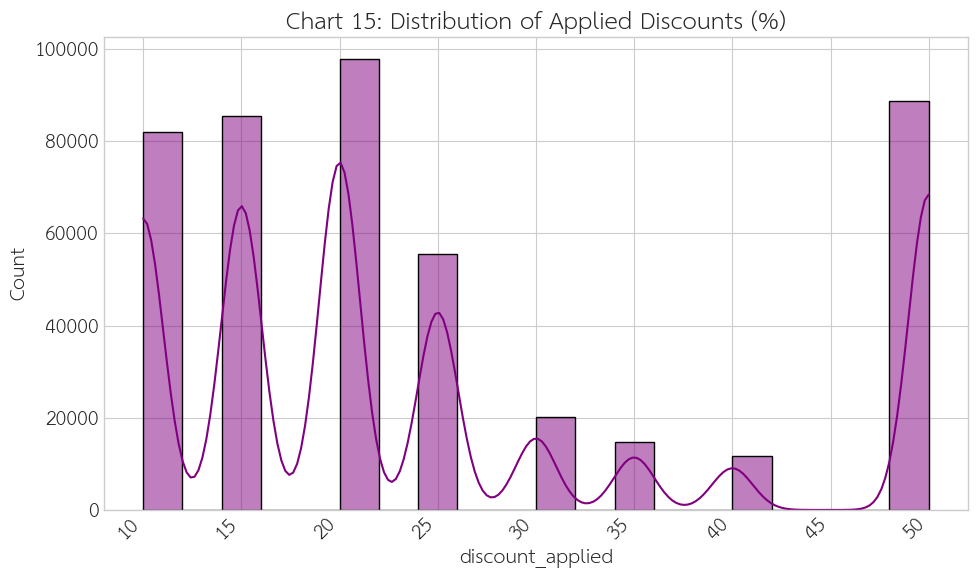

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['discount_applied'] > 0]['discount_applied'], bins=20, kde=True, color='purple')
plt.title('Chart 15: Distribution of Applied Discounts (%)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 16: Promotion Lift by Day of Week
### แผนภูมิที่ 16: Promotion Lift ตามวันในสัปดาห์

**Description:**
A line plot illustrating the average units sold grouped by the day of the week, with separate trend lines for promotional vs. non-promotional days.

**คำอธิบาย:**
กราฟเส้นที่แสดงยอดขายเฉลี่ยจัดกลุ่มตามวันในสัปดาห์ มีเส้นแนวโน้มแยกสำหรับวันที่มีและไม่มีโปรโมชัน

**Actionable Insight:**
Highlights the mid-week magic. Running a promotion on a saturated Saturday often yields a tiny marginal lift. Conversely, Thursday promotions might double normal volume.

**Insight ที่นำไปใช้ได้:**
เน้นความมหัศจรรย์กลางสัปดาห์ การทำโปรโมชันในวันเสาร์ที่อิ่มตัวมักให้ lift ส่วนเพิ่มเล็กน้อย ในทางกลับกัน โปรโมชันวันพฤหัสบดีอาจเพิ่มปริมาณเป็นสองเท่า

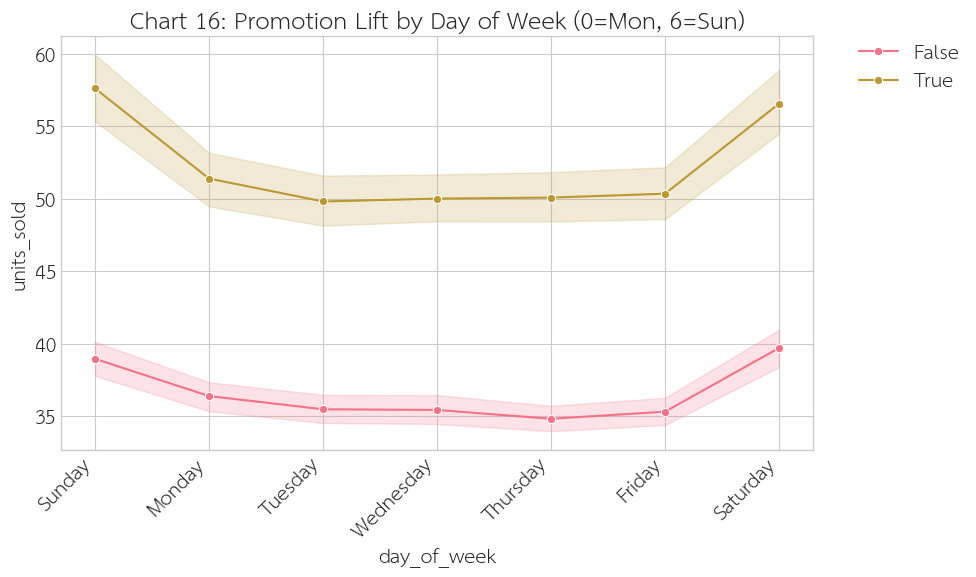

In [22]:
plt.figure(figsize=(10,6))
sns.lineplot(data=daily_promo, x='day_of_week', y='units_sold', hue='has_promo', marker='o')
plt.title('Chart 16: Promotion Lift by Day of Week (0=Mon, 6=Sun)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 16.5: 90-Day Promotion Fatigue & Baseline Bleed
### แผนภูมิที่ 16.5: Promotion Fatigue และ Baseline Bleed 90 วัน

**Description:**
A 90-day time-series for a store running consecutive promotions. Yellow blocks indicate active promotion periods.

**คำอธิบาย:**
Time-series 90 วันสำหรับสาขาที่ทำโปรโมชันต่อเนื่อง บล็อกสีเหลืองบ่งชี้ช่วงโปรโมชันที่ใช้งานอยู่

**Actionable Insight (Product/Solution Opportunity):**
This reveals the 'Coupon Clipper' effect. The first promo generates a massive spike. However, notice how the baseline sales *between* the later promos begin to drop below the historical average. Customers are being trained to wait for discounts. The solution is a **'Promo Cooldown Recommender'**—an ML module that enforces a mandatory 21-day cool-down period between heavy discounts to protect organic baseline revenue.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
เผย 'Coupon Clipper Effect' โปรโมชันแรกสร้างสไปก์มหาศาล อย่างไรก็ตาม สังเกตว่ายอดขายพื้นฐาน *ระหว่าง* โปรโมชันหลังๆ เริ่มต่ำกว่าค่าเฉลี่ยประวัติ ลูกค้ากำลังถูกฝึกให้รอส่วนลด วิธีแก้คือ **'Promo Cooldown Recommender'** โมดูล ML ที่บังคับใช้ช่วงพักบังคับ 21 วันระหว่างส่วนลดหนักๆ เพื่อปกป้องรายได้ organic พื้นฐาน

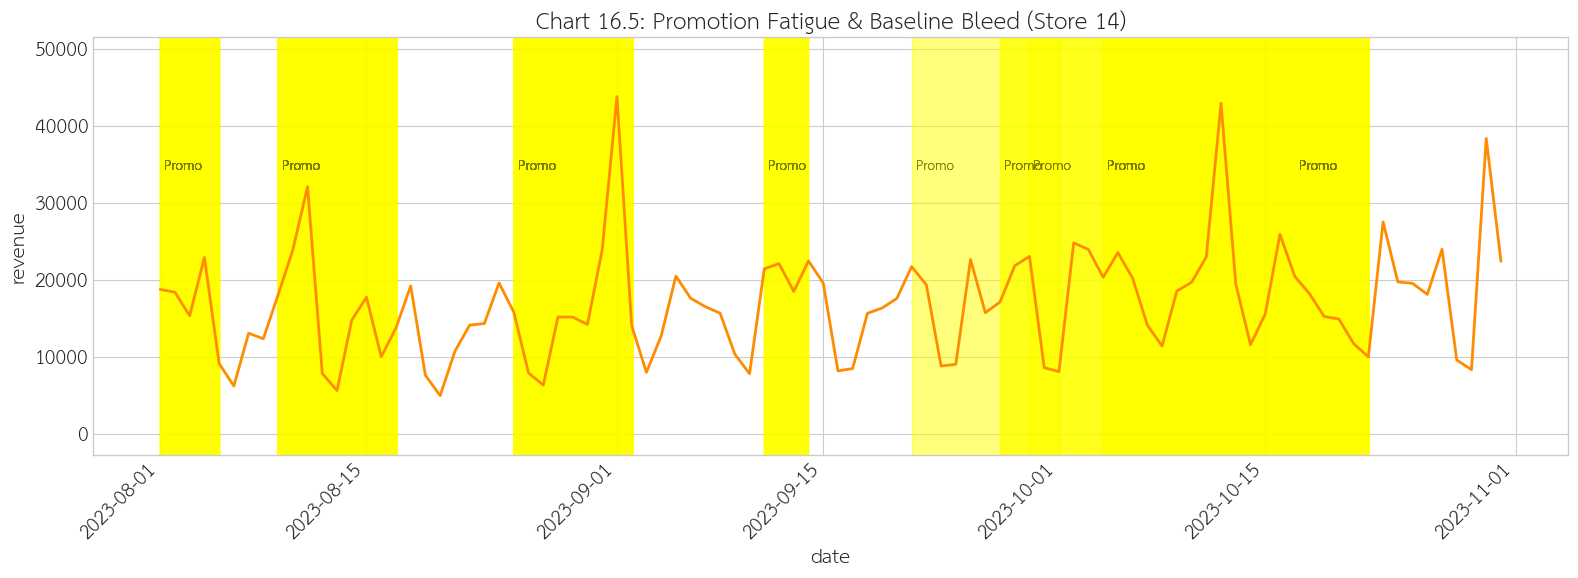

In [23]:
p_store = promo['store_id'].value_counts().index[0]
q3_fatigue = df[(df['store_id'] == p_store) & (df['date'] >= '2023-08-01') & (df['date'] <= '2023-10-31')]
fatigue_ts = q3_fatigue.groupby('date')['revenue'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=fatigue_ts, x='date', y='revenue', color='darkorange', linewidth=2)
active_promos = promo[(promo['store_id'] == p_store) & (promo['start_date'] <= '2023-10-31') & (promo['end_date'] >= '2023-08-01')]
for _, r in active_promos.iterrows():
    start = max(r['start_date'], pd.Timestamp('2023-08-01'))
    end = min(r['end_date'], pd.Timestamp('2023-10-31'))
    plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.text(start, plt.ylim()[1]*0.75, ' Promo', color='olive', fontsize=9)
plt.title(f'Chart 16.5: Promotion Fatigue & Baseline Bleed (Store {p_store})', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 17: Impact of Marketing Channels
### แผนภูมิที่ 17: ผลกระทบของช่องทางการตลาด

**Description:**
A bar chart analyzing the volume lift driven strictly by the communication medium used to advertise the promotion.

**คำอธิบาย:**
แผนภูมิแท่งที่วิเคราะห์การเพิ่มขึ้นของ volume ที่ขับเคลื่อนโดยสื่อการสื่อสารที่ใช้โฆษณาโปรโมชัน

**Actionable Insight:**
Just having a discount isn't enough; customers must know about it. If Social Media drives significantly higher volume than Email, we must treat the social campaign binary flag as a high-weight modifier.

**Insight ที่นำไปใช้ได้:**
การมีส่วนลดเพียงอย่างเดียวไม่เพียงพอ ลูกค้าต้องรู้เกี่ยวกับมัน หาก Social Media ขับ volume สูงกว่า Email อย่างมีนัยสำคัญ เราต้องถือว่า flag ไบนารีของแคมเปญโซเชียลเป็นตัวปรับน้ำหนักสูง

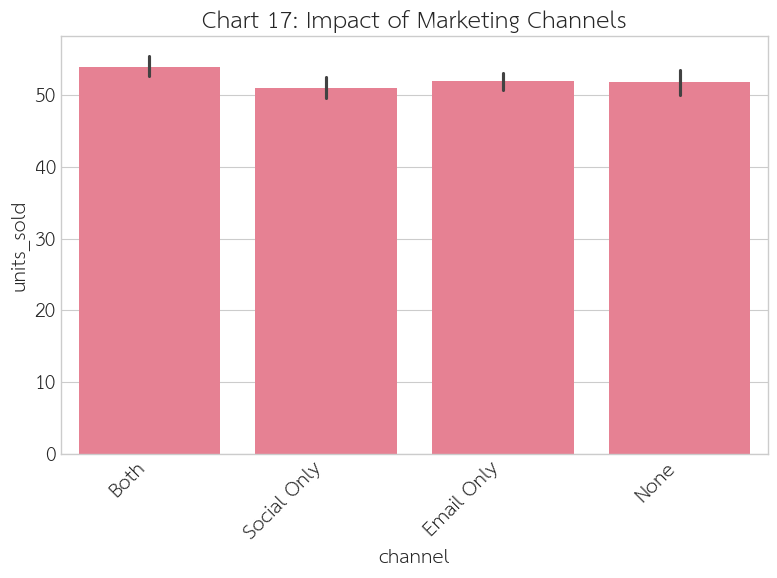

In [24]:
daily_promo['channel'] = 'None'
daily_promo.loc[(daily_promo['email_sent'] == True) & (daily_promo['social_campaign'] == False), 'channel'] = 'Email Only'
daily_promo.loc[(daily_promo['email_sent'] == False) & (daily_promo['social_campaign'] == True), 'channel'] = 'Social Only'
daily_promo.loc[(daily_promo['email_sent'] == True) & (daily_promo['social_campaign'] == True), 'channel'] = 'Both'
plt.figure(figsize=(8,6))
sns.barplot(data=daily_promo[daily_promo['has_promo']], x='channel', y='units_sold')
plt.title('Chart 17: Impact of Marketing Channels')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 18: Promo Responsiveness by Neighborhood
### แผนภูมิที่ 18: การตอบสนองต่อโปรโมชันตามย่าน

**Description:**
A barplot comparing how different geographic store locations react to active promotions versus baseline days.

**คำอธิบาย:**
Barplot เปรียบเทียบว่าสาขาในทำเลภูมิศาสตร์ต่างๆ ตอบสนองต่อโปรโมชันที่ใช้งานอยู่เทียบกับวันปกติอย่างไร

**Actionable Insight:**
Office workers might buy coffee regardless of price, showing low price sensitivity. Conversely, university students might aggressively hoard products during promo days.

**Insight ที่นำไปใช้ได้:**
พนักงาน Office อาจซื้อกาแฟโดยไม่คำนึงถึงราคา แสดงความไวต่อราคาต่ำ ในทางกลับกัน นักศึกษามหาวิทยาลัยอาจกักตุนสินค้าอย่างจริงจังในวันโปรโมชัน

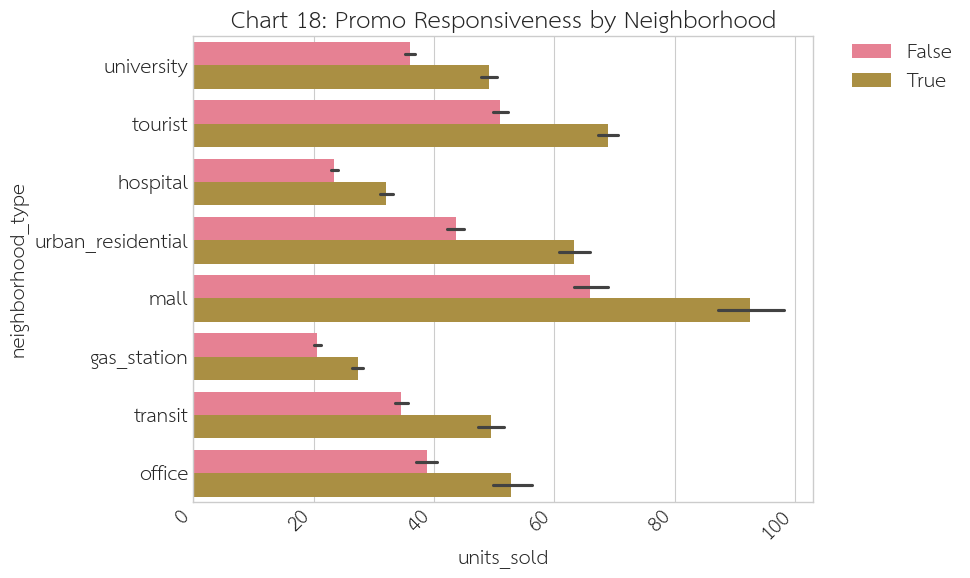

In [25]:
daily_promo_nh = daily_promo.merge(store[['store_id', 'neighborhood_type']], on='store_id', how='left')
plt.figure(figsize=(10,6))
sns.barplot(data=daily_promo_nh, y='neighborhood_type', x='units_sold', hue='has_promo')
plt.title('Chart 18: Promo Responsiveness by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 19: Bakery Sales when Coffee is on Promo (Cannibalization)
### แผนภูมิที่ 19: ยอดขายเบเกอรี่เมื่อกาแฟลดราคา (Cannibalization)

**Description:**
A boxplot testing cross-category elasticity by plotting Bakery sales specifically on days when Coffee is heavily discounted.

**คำอธิบาย:**
Boxplot ทดสอบ cross-category elasticity โดยแสดงยอดขายเบเกอรี่โดยเฉพาะในวันที่กาแฟลดราคาหนัก

**Actionable Insight:**
If discounting Coffee increases Bakery sales, it is a Halo Effect. If Bakery sales plummet, it is Cannibalization. The model must map these cross-elastic dependencies to avoid overestimating total store revenue.

**Insight ที่นำไปใช้ได้:**
หากการลดราคากาแฟเพิ่มยอดขายเบเกอรี่ นั่นคือ Halo Effect หากยอดขายเบเกอรี่ตก นั่นคือ Cannibalization โมเดลต้องแมป cross-elastic dependencies เหล่านี้เพื่อหลีกเลี่ยงการประเมินรายได้รวมสาขาสูงเกินจริง

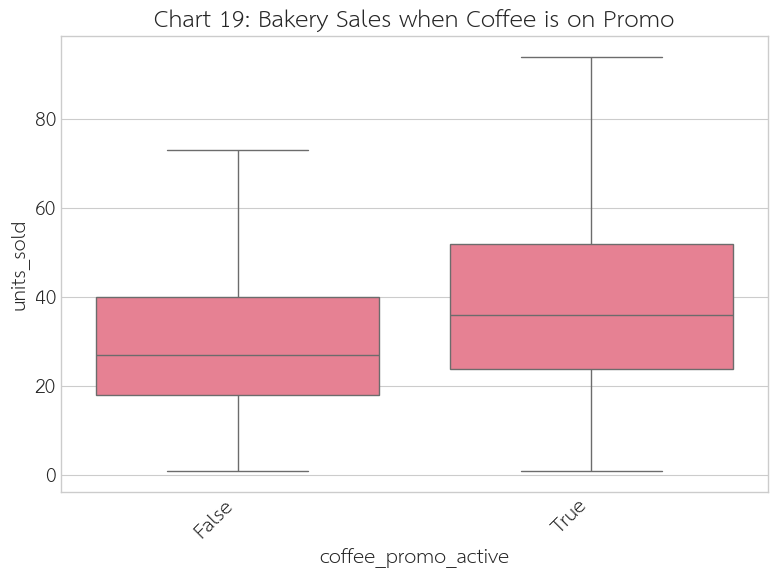

In [26]:
coffee_promo_dates = daily_promo[(daily_promo['category']=='Coffee') & daily_promo['has_promo']][['store_id', 'date']].drop_duplicates()
coffee_promo_dates['coffee_promo_active'] = True
bakery_sales = daily_promo[daily_promo['category']=='Bakery'].merge(coffee_promo_dates, on=['store_id', 'date'], how='left')
bakery_sales['coffee_promo_active'] = bakery_sales['coffee_promo_active'].fillna(False)
plt.figure(figsize=(8,6))
sns.boxplot(data=bakery_sales, x='coffee_promo_active', y='units_sold', showfliers=False)
plt.title('Chart 19: Bakery Sales when Coffee is on Promo')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 19.5: 90-Day Promotion Halo vs Cannibalization Dynamics
### แผนภูมิที่ 19.5: Promotion Halo vs Cannibalization Dynamics 90 วัน

**Description:**
A 90-day time-series isolating a single high-performing store. It plots two distinct lines: total units of Coffee sold versus total units of Bakery items sold. Yellow shaded regions indicate periods when a major Coffee discount was active.

**คำอธิบาย:**
Time-series 90 วันสำหรับสาขาที่มีประสิทธิภาพสูงสาขาหนึ่ง แสดงสองเส้นที่ชัดเจน: ยอดกาแฟรวมที่ขาย vs ยอดเบเกอรี่รวมที่ขาย พื้นที่สีเหลืองบ่งชี้ช่วงที่มีส่วนลดกาแฟหลักที่ใช้งานอยู่

**Actionable Insight (Product/Solution Opportunity):**
This visualizes the core logic needed for a **'Smart Bundle Recommendation Engine'**. When a Coffee promotion launches (yellow zone), the coffee line spikes. But does the Bakery line rise with it (Halo Effect), or stay flat/drop (Cannibalization)? If bakery sales fail to scale during a coffee traffic surge, the store is bleeding potential margin. The solution is an ML model that explicitly detects these dead zones and automatically triggers 'Bundle Deals' (e.g., Buy Coffee, get Croissant 50% off) exclusively on those dates to force cross-selling.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
กราฟนี้แสดงตรรกะหลักที่จำเป็นสำหรับ **'Smart Bundle Recommendation Engine'** เมื่อโปรโมชันกาแฟเปิดตัว (โซนเหลือง) เส้นกาแฟพุ่งสูง แต่เส้นเบเกอรี่ขึ้นตาม (Halo Effect) หรืออยู่นิ่ง/ลด (Cannibalization)? หากยอดเบเกอรี่ไม่ scale ในช่วง traffic กาแฟสูง สาขาสูญเสียกำไรที่ควรได้ วิธีแก้คือโมเดล ML ที่ตรวจจับโซนตายเหล่านี้และทริกเกอร์ 'Bundle Deals' อัตโนมัติ (เช่น ซื้อกาแฟ ได้ Croissant ลด 50%) เฉพาะวันเหล่านั้นเพื่อบังคับ cross-selling

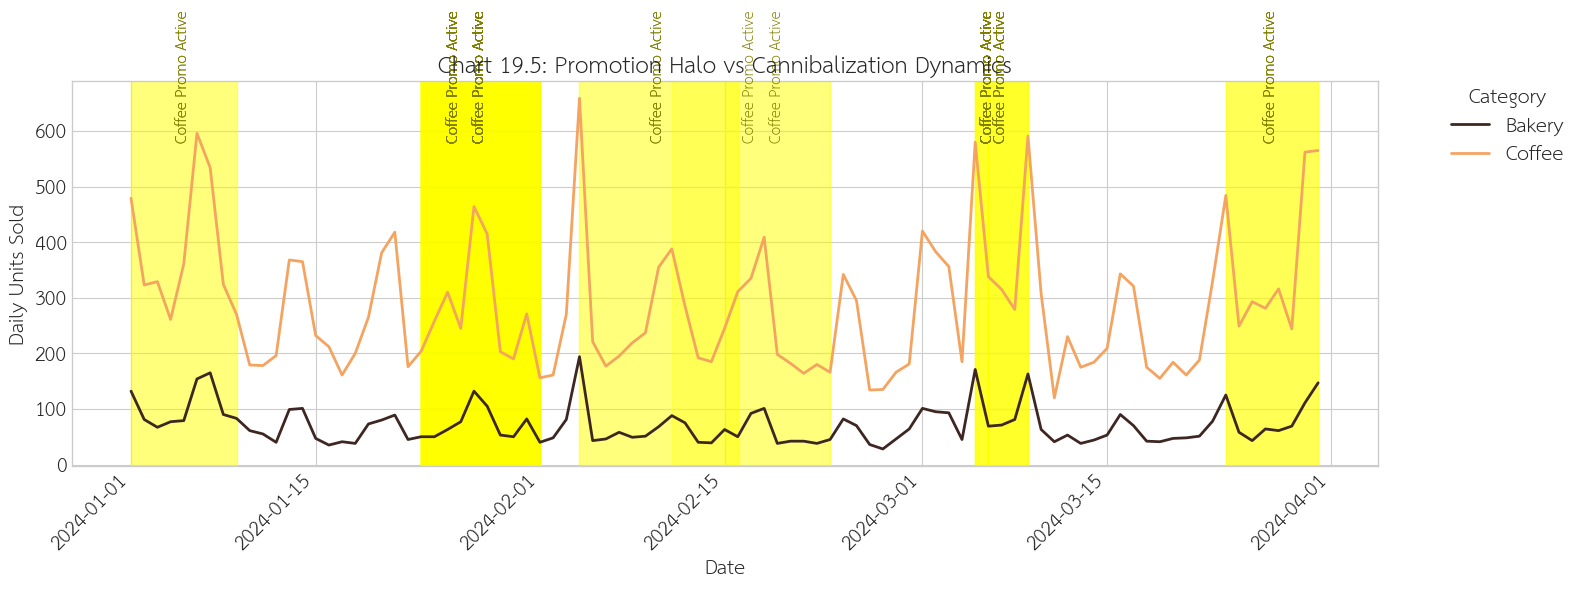

In [27]:
q1_promo = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-03-31')].copy()
top_store = q1_promo.groupby('store_id')['units_sold'].sum().idxmax()
cross_sell = q1_promo[(q1_promo['store_id'] == top_store) & (q1_promo['category'].isin(['Coffee', 'Bakery']))]
cross_ts = cross_sell.groupby(['date', 'category'])['units_sold'].sum().reset_index()

promo_active = promo[(promo['store_id'] == top_store) & (promo['product_id'].isin(prod[prod['category']=='Coffee']['product_id'])) & (promo['discount_pct'] >= 10)]

plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=cross_ts, x='date', y='units_sold', hue='category', palette=['#3e2723', '#f4a460'], linewidth=2)

for _, r in promo_active.iterrows():
    start = max(r['start_date'], pd.Timestamp('2024-01-01'))
    end = min(r['end_date'], pd.Timestamp('2024-03-31'))
    if start <= end:
        plt.axvspan(start, end, color='yellow', alpha=0.3)
        plt.text(start + (end-start)/2, plt.ylim()[1]*0.85, 'Coffee Promo Active', color='olive', ha='center', fontsize=10, rotation=90)

plt.title('Chart 19.5: Promotion Halo vs Cannibalization Dynamics', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Units Sold')
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Category')
plt.tight_layout()
plt.show()

## Section 4: Local Events & Store Operations
## หมวดที่ 4: อีเวนต์ท้องถิ่นและการดำเนินงานสาขา

### Chart 20: Local Event Impact by Category
### แผนภูมิที่ 20: ผลกระทบของอีเวนต์ท้องถิ่นตามหมวดสินค้า

**Description:**
A bar chart detailing how local events alter the sales volume of specific product categories disproportionately.

**คำอธิบาย:**
แผนภูมิแท่งที่รายละเอียดว่าอีเวนต์ท้องถิ่นเปลี่ยนแปลงปริมาณขายของหมวดสินค้าเฉพาะอย่างไม่สมส่วนอย่างไร

**Actionable Insight:**
A massive public event might cause a 200% spike in grab-and-go Beverages but entirely cannibalize Dine-in Bakery items because the store is too crowded to sit down. This proves that Event_Active must be multiplied by Category in the modeling phase.

**Insight ที่นำไปใช้ได้:**
อีเวนต์สาธารณะขนาดใหญ่อาจทำให้เครื่องดื่ม grab-and-go พุ่งสูง 200% แต่กินส่วนแบ่งเบเกอรี่ Dine-in เพราะร้านแน่นเกินจะนั่ง ซึ่งพิสูจน์ว่า Event_Active ต้องคูณด้วย Category ในขั้นตอนการสร้างโมเดล

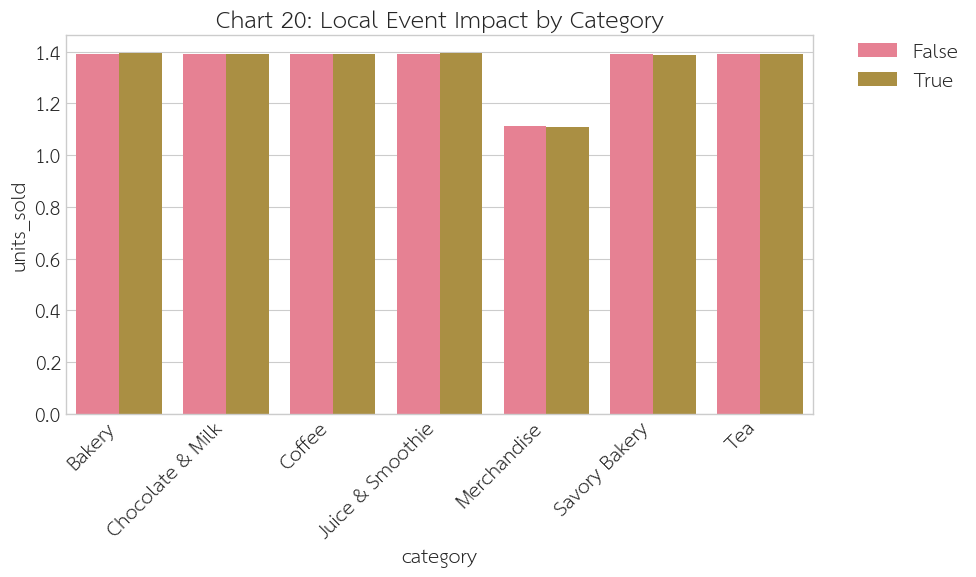

In [28]:
event_cat = df.merge(event[['store_id', 'date', 'event_type']], on=['store_id', 'date'], how='left')
event_cat['has_event'] = event_cat['event_type'].notna()
event_cat_lift = event_cat.groupby(['category', 'has_event'])['units_sold'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=event_cat_lift, x='category', y='units_sold', hue='has_event')
plt.title('Chart 20: Local Event Impact by Category')
plt.xticks(rotation=45)
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 21: Revenue Distribution by Local Event Type
### แผนภูมิที่ 21: การกระจายรายได้ตามประเภทอีเวนต์ท้องถิ่น

**Description:**
A boxplot analyzing the direct monetary impact of specific localized events taking place near the store.

**คำอธิบาย:**
Boxplot วิเคราะห์ผลกระทบทางการเงินโดยตรงของอีเวนต์ท้องถิ่นเฉพาะที่เกิดขึ้นใกล้สาขา

**Actionable Insight:**
Certain events attract massive crowds but zero customers (e.g., marathons blocking road access), while others (e.g., Food Festivals) drive massive foot traffic. The event type categorical variable is highly predictive of anomalous daily spikes.

**Insight ที่นำไปใช้ได้:**
บางอีเวนต์ดึงฝูงชนมหาศาลแต่ไม่มีลูกค้าเลย (เช่น มาราธอนที่ปิดถนน) ในขณะที่บางอีเวนต์ (เช่น Food Festival) ขับ foot traffic มหาศาล ตัวแปร categorical ประเภทอีเวนต์มีความสามารถทำนายสไปก์รายวันผิดปกติสูงมาก

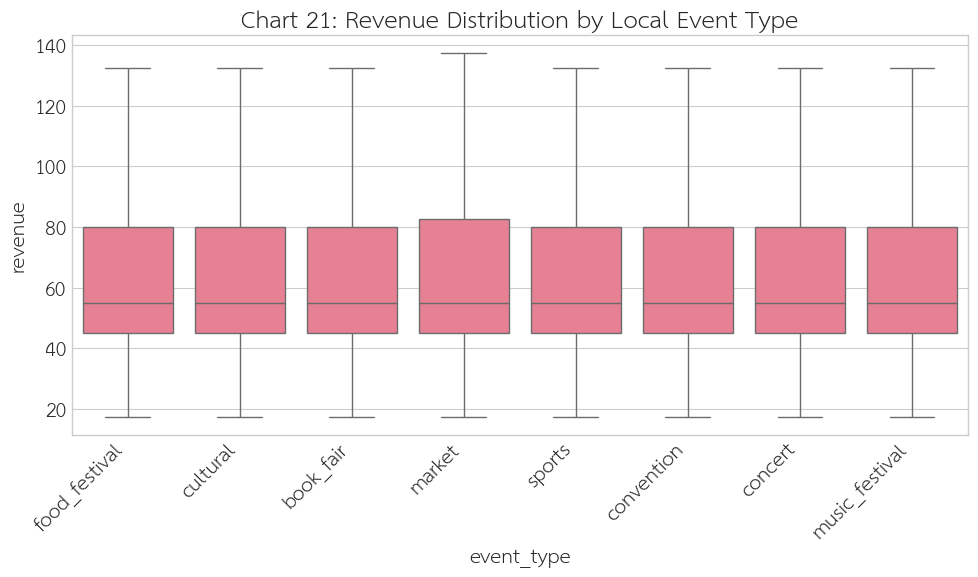

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data=event_cat, x='event_type', y='revenue', showfliers=False)
plt.title('Chart 21: Revenue Distribution by Local Event Type')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 21.5: 90-Day Local Event Demand Shock & Hangover
### แผนภูมิที่ 21.5: Demand Shock และ Hangover ของอีเวนต์ท้องถิ่น 90 วัน

**Description:**
A 90-day time-series for a specific store that hosted a major local event. The red dashed lines pinpoint the exact dates the event took place, plotting the raw units sold before, during, and after the shock.

**คำอธิบาย:**
Time-series 90 วันสำหรับสาขาเฉพาะที่จัดอีเวนต์ท้องถิ่นใหญ่ เส้นประสีแดงระบุวันที่แน่นอนที่อีเวนต์เกิดขึ้น แสดงยอดขาย raw ก่อน ระหว่าง และหลังจาก shock

**Actionable Insight (Product/Solution Opportunity):**
This graph reveals the exact anatomy of an anomaly, justifying an **'Event-Driven Inventory Buffer Model'**. While basic models see a single spike, this time-series exposes both the 'Demand Shock' (a massive single-day spike causing stockouts) and the critical 'Hangover Effect' (sales plunging below baseline the day after because inventory is depleted or customers hoarded goods). A successful product must run an isolated forecasting module specifically for event days to inject a calculated safety buffer, preventing the post-event hangover.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
กราฟนี้เผยกายวิภาคที่แน่ชัดของความผิดปกติ สนับสนุน **'Event-Driven Inventory Buffer Model'** ในขณะที่โมเดลพื้นฐานเห็นแค่สไปก์เดียว time-series นี้เผยทั้ง 'Demand Shock' (สไปก์รายวันมหาศาลที่ทำให้สินค้าหมด) และ 'Hangover Effect' (ยอดขายดิ่งต่ำกว่าค่าพื้นฐานวันถัดมาเพราะสินค้าหมดหรือลูกค้ากักตุน) โมเดลที่ประสบความสำเร็จต้องมีโมดูลพยากรณ์แยกสำหรับวันอีเวนต์เพื่อใส่ safety buffer ที่คำนวณแล้ว ป้องกัน post-event hangover

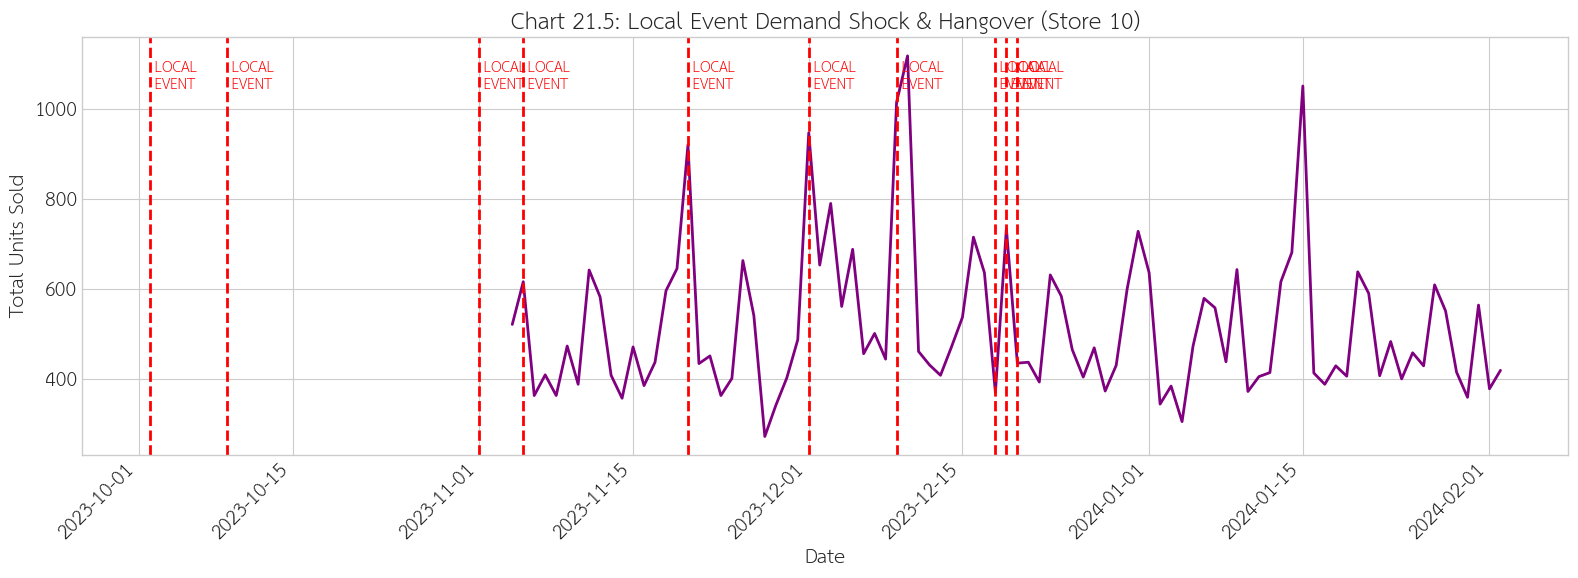

In [30]:
q4_event = event[(event['date'] >= '2023-10-01') & (event['date'] <= '2023-12-31')]
if not q4_event.empty:
    event_store = q4_event['store_id'].iloc[0]
    event_date = q4_event['date'].iloc[0]
    start_win = event_date - pd.Timedelta(days=45)
    end_win = event_date + pd.Timedelta(days=45)
    
    shock_df = df[(df['store_id'] == event_store) & (df['date'] >= start_win) & (df['date'] <= end_win)]
    shock_ts = shock_df.groupby('date')['units_sold'].sum().reset_index()
    
    plt.figure(figsize=(16, 6))
    ax = sns.lineplot(data=shock_ts, x='date', y='units_sold', color='purple', linewidth=2)
    
    event_dates = q4_event[q4_event['store_id'] == event_store]['date']
    for ed in event_dates:
        plt.axvline(ed, color='red', linestyle='--', linewidth=2)
        plt.text(ed, plt.ylim()[1]*0.9, ' LOCAL\n EVENT', color='red', fontsize=10, fontweight='bold', ha='left')

    plt.title(f'Chart 21.5: Local Event Demand Shock & Hangover (Store {event_store})', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Total Units Sold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Chart 22: Store Revenue vs Capacity
### แผนภูมิที่ 22: รายได้สาขา vs ความจุ

**Description:**
A bubble scatterplot mapping physical seating capacity against gross revenue, with the bubble size representing the total staff count.

**คำอธิบาย:**
Bubble scatterplot ที่แมปความจุที่นั่งทางกายภาพกับรายได้รวม โดย bubble size แทนจำนวนพนักงานทั้งหมด

**Actionable Insight:**
Examines operational efficiency boundaries. Does a massive seating area guarantee high revenue, or do tiny, heavily-staffed transit kiosks outperform them? This highlights the non-linear relationship between physical assets and demand throughput.

**Insight ที่นำไปใช้ได้:**
ตรวจสอบขอบเขตประสิทธิภาพการดำเนินงาน พื้นที่นั่งขนาดมหึมาการันตีรายได้สูงหรือไม่ หรือ kiosk transit ขนาดเล็กที่มีพนักงานเยอะทำได้ดีกว่า? นี่เน้นความสัมพันธ์ไม่เชิงเส้นระหว่างสินทรัพย์ทางกายภาพและ demand throughput

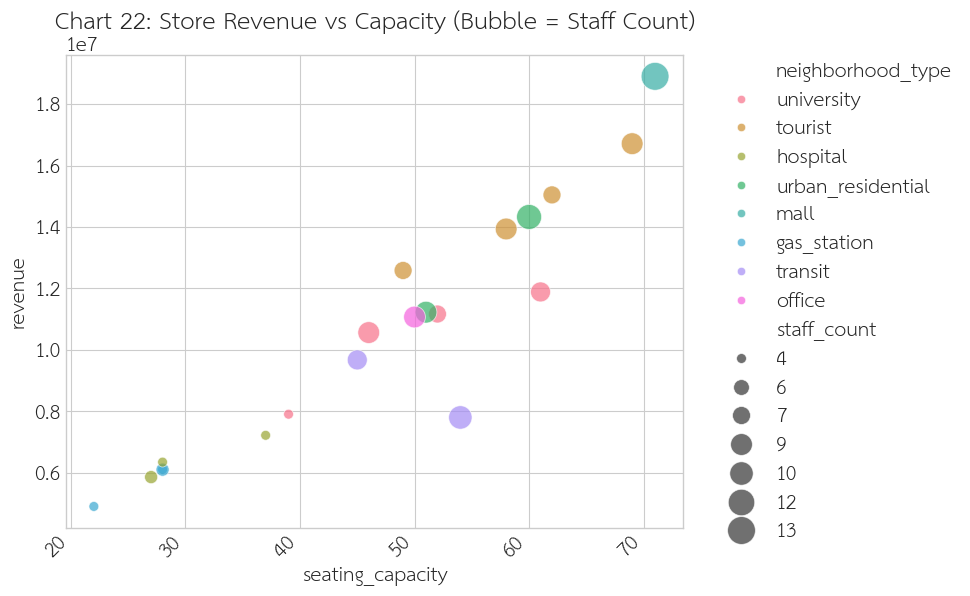

In [31]:
store_rev = df.groupby('store_id')['revenue'].sum().reset_index()
store_rev = store_rev.merge(store, on='store_id')
plt.figure(figsize=(10,6))
sns.scatterplot(data=store_rev, x='seating_capacity', y='revenue', size='staff_count', sizes=(50, 400), hue='neighborhood_type', alpha=0.7)
plt.title('Chart 22: Store Revenue vs Capacity (Bubble = Staff Count)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 23: Staff Efficiency vs Store Age
### แผนภูมิที่ 23: ประสิทธิภาพพนักงาน vs อายุสาขา

**Description:**
A regression plot analyzing the relationship between how long a store has been open and the average revenue generated per staff member.

**คำอธิบาย:**
Regression plot วิเคราะห์ความสัมพันธ์ระหว่างระยะเวลาที่สาขาเปิดกิจการกับรายได้เฉลี่ยต่อพนักงาน

**Actionable Insight:**
Do mature stores operate more smoothly, or do brand-new Grand Opening stores enjoy higher hype? If older stores are systematically more efficient, store age becomes a critical continuous feature for forecasting.

**Insight ที่นำไปใช้ได้:**
สาขาที่โตเต็มที่ดำเนินงานราบรื่นกว่าหรือสาขาใหม่ที่เพิ่งเปิดมีกระแสฮาย์ปสูงกว่า? หากสาขาเก่ามีประสิทธิภาพอย่างเป็นระบบ อายุสาขากลายเป็นฟีเจอร์ต่อเนื่องสำคัญสำหรับการพยากรณ์

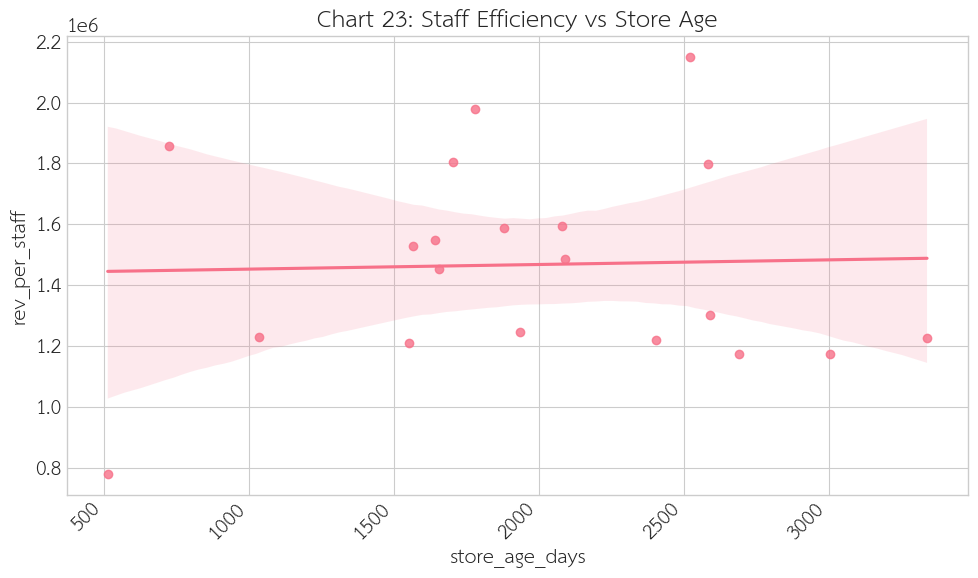

In [32]:
store_rev['store_age_days'] = (pd.Timestamp('2024-11-01') - store_rev['opened_date']).dt.days
store_rev['rev_per_staff'] = store_rev['revenue'] / store_rev['staff_count']
plt.figure(figsize=(10,6))
sns.regplot(data=store_rev, x='store_age_days', y='rev_per_staff')
plt.title('Chart 23: Staff Efficiency vs Store Age')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 24: Staff Stress Index vs Basket Size
### แผนภูมิที่ 24: Staff Stress Index vs ขนาด Basket

**Description:**
A regression plot showing the mathematical relationship between the Stress Index (Orders / Staff Count) and Average Basket Size.

**คำอธิบาย:**
Regression plot แสดงความสัมพันธ์ทางคณิตศาสตร์ระหว่าง Stress Index (จำนวนออเดอร์/จำนวนพนักงาน) กับขนาด Basket เฉลี่ย

**Actionable Insight:**
Proves that rushed service reduces upsells. When a single barista is overwhelmed, they do not have the time to ask 'Would you like a croissant?', causing units-per-order to plummet. This caps maximum theoretical store revenue during peak rushes.

**Insight ที่นำไปใช้ได้:**
พิสูจน์ว่าการบริการที่รีบเร่งลด upsell บาริสต้าที่ล้นมือไม่มีเวลาถามว่า 'ต้องการ croissant ไหม?' ทำให้ units-per-order ดิ่ง ซึ่งจำกัดรายได้ทางทฤษฎีสูงสุดของสาขาในช่วง peak rush

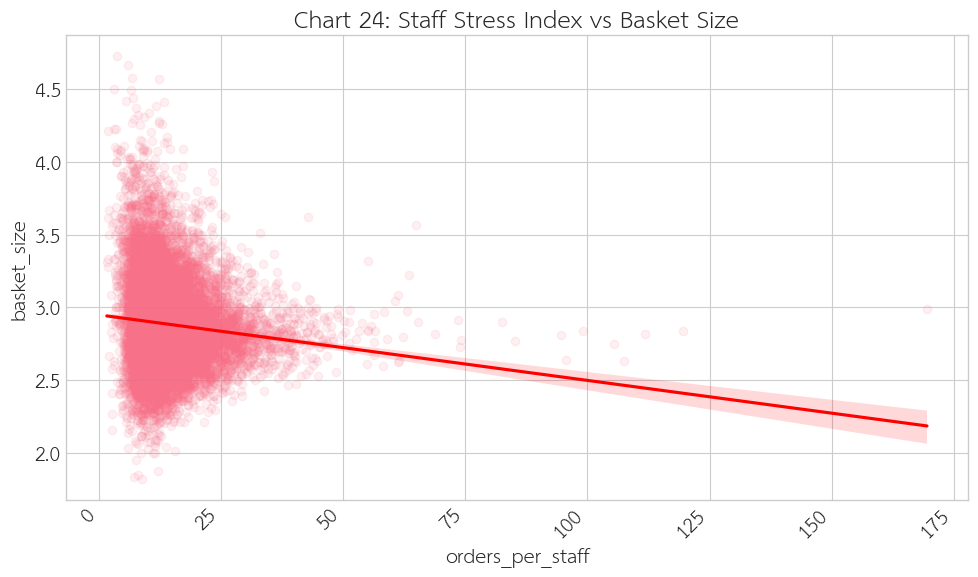

In [33]:
staff_stress = df.groupby(['store_id', 'date']).agg({'order_id': 'nunique', 'units_sold': 'sum', 'staff_count': 'first'}).reset_index()
staff_stress['orders_per_staff'] = staff_stress['order_id'] / staff_stress['staff_count']
staff_stress['basket_size'] = staff_stress['units_sold'] / staff_stress['order_id']
plt.figure(figsize=(10, 6))
sns.regplot(data=staff_stress, x='orders_per_staff', y='basket_size', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Chart 24: Staff Stress Index vs Basket Size')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 25: Daily Order Volume (Drive-Through vs Standard)
### แผนภูมิที่ 25: ปริมาณออเดอร์รายวัน (Drive-Through vs มาตรฐาน)

**Description:**
A boxplot contrasting the total daily order throughput between branches equipped with a Drive-Through window versus standard walk-in cafes.

**คำอธิบาย:**
Boxplot เปรียบเทียบ throughput ออเดอร์รายวันทั้งหมดระหว่างสาขาที่มีหน้าต่าง Drive-Through กับร้านกาแฟ walk-in มาตรฐาน

**Actionable Insight:**
Drive-Through stores have a vastly higher theoretical capacity ceiling during rush hour because they process cars and walk-ins simultaneously. Models should inherently allow higher maximum predictions for these stores.

**Insight ที่นำไปใช้ได้:**
สาขา Drive-Through มีเพดานความจุทางทฤษฎีสูงกว่ามากในช่วง rush hour เพราะประมวลผลรถยนต์และ walk-in พร้อมกัน โมเดลควรอนุญาตการทำนายสูงสุดที่สูงกว่าสำหรับสาขาเหล่านี้โดยเนื้อแท้

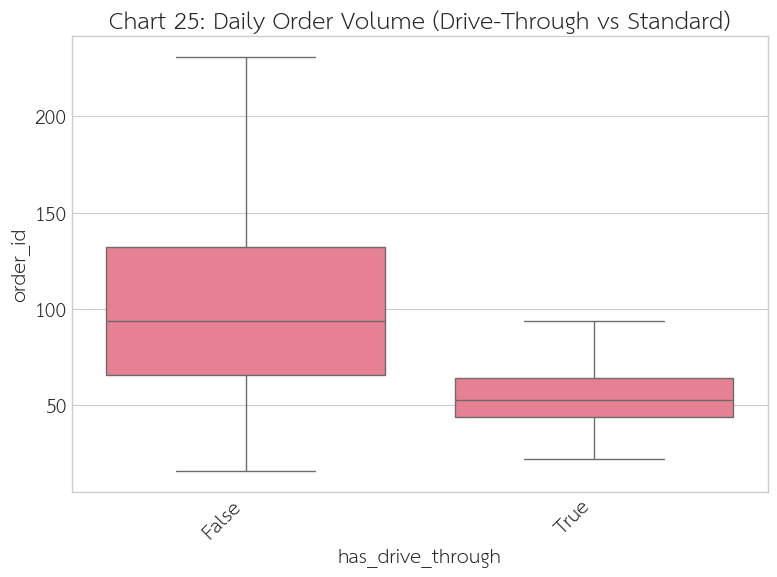

In [34]:
dt_impact = df.groupby(['store_id', 'date']).agg({'order_id': 'nunique', 'has_drive_through': 'first'})
plt.figure(figsize=(8,6))
sns.boxplot(data=dt_impact, x='has_drive_through', y='order_id', showfliers=False)
plt.title('Chart 25: Daily Order Volume (Drive-Through vs Standard)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 26: Operating Hours Effect
### แผนภูมิที่ 26: ผลกระทบของชั่วโมงเปิดทำการ

**Description:**
An analysis correlating a store's total daily sales capacity against its designated operating hours.

**คำอธิบาย:**
การวิเคราะห์ที่ correlate ความจุยอดขายรายวันรวมของสาขากับชั่วโมงเปิดทำการที่กำหนด

**Actionable Insight:**
Stores with extended operating hours inherently possess a higher throughput ceiling. If operating hours change over time, the historical baseline must be normalized to prevent the model from misinterpreting a revenue jump as structural demand growth.

**Insight ที่นำไปใช้ได้:**
สาขาที่มีชั่วโมงเปิดทำการขยาย มีเพดาน throughput สูงกว่าโดยเนื้อแท้ หากชั่วโมงเปิดทำการเปลี่ยนแปลงเมื่อเวลาผ่านไป ค่าพื้นฐานประวัติต้องถูก normalize เพื่อป้องกันไม่ให้โมเดลตีความการกระโดดของรายได้ว่าเป็นการเติบโตความต้องการเชิงโครงสร้าง

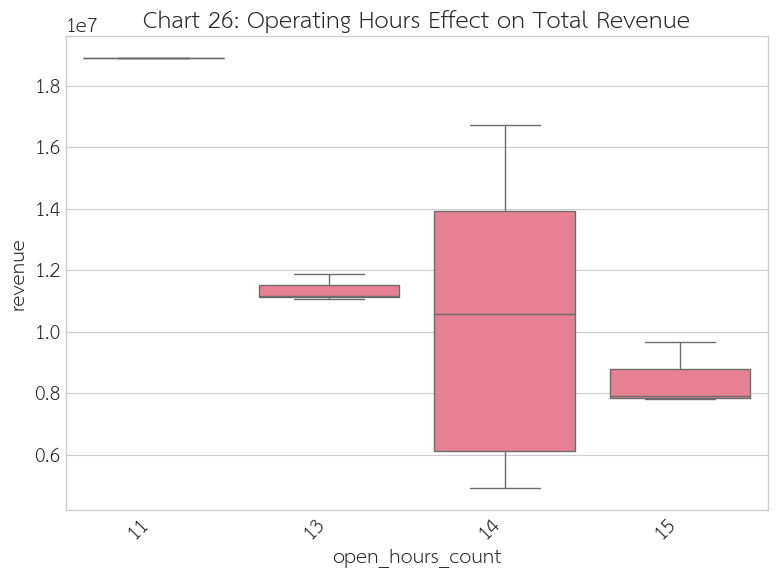

In [35]:
store['open_hours_count'] = store['close_time'].str[:2].astype(int) - store['open_time'].str[:2].astype(int)
store_op = store_rev.merge(store[['store_id', 'open_hours_count']], on='store_id')
plt.figure(figsize=(8,6))
sns.boxplot(data=store_op, x='open_hours_count', y='revenue')
plt.title('Chart 26: Operating Hours Effect on Total Revenue')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

## Section 5: Customer Retention & Demographics
## หมวดที่ 5: การรักษาลูกค้าและประชากรศาสตร์

### Chart 27: Total Revenue by Membership
### แผนภูมิที่ 27: รายได้รวมตามสมาชิกภาพ

**Description:**
A pie chart illustrating the macroeconomic revenue split between Walk-in customers and registered Members.

**คำอธิบาย:**
Pie chart แสดงการแบ่งรายได้มหภาคระหว่างลูกค้า Walk-in และสมาชิกที่ลงทะเบียน

**Actionable Insight:**
Understanding the baseline share of wallet reveals if our business is heavily reliant on a small pool of loyalists or sustained by high-volume foot traffic. Member Sales represent stable demand, whereas Walk-in Sales are highly volatile.

**Insight ที่นำไปใช้ได้:**
การเข้าใจส่วนแบ่งกระเป๋าเงินพื้นฐานเผยให้เห็นว่าธุรกิจพึ่งพา loyalists กลุ่มเล็กหรือ foot traffic ปริมาณสูง ยอดขายสมาชิกแทนความต้องการที่เสถียร ขณะที่ยอดขาย Walk-in มีความผันผวนสูง

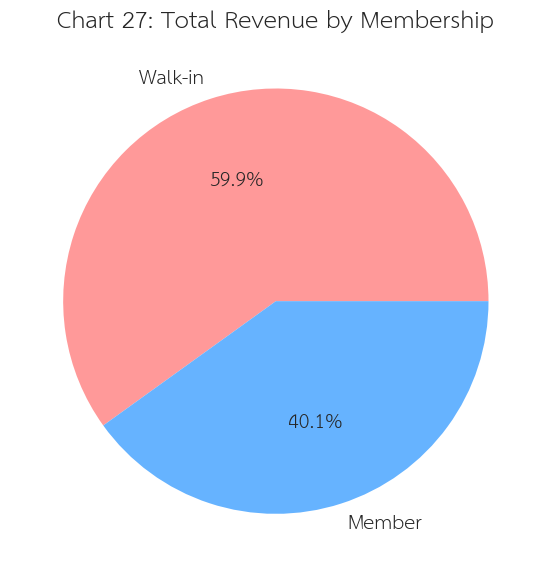

In [36]:
rev_split = df.groupby('is_member')['revenue'].sum()
plt.figure(figsize=(6,6))
plt.pie(rev_split, labels=['Walk-in', 'Member'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Chart 27: Total Revenue by Membership')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 28: Order Frequency by Hour of Day
### แผนภูมิที่ 28: ความถี่ออเดอร์ตามชั่วโมงของวัน

**Description:**
A line plot displaying the total number of unique orders placed throughout the 24-hour cycle, separated by membership status.

**คำอธิบาย:**
กราฟเส้นแสดงจำนวนออเดอร์เฉพาะทั้งหมดที่สั่งตลอด 24 ชั่วโมง แยกตามสถานะสมาชิก

**Actionable Insight:**
Members often exhibit sharp spikes during morning commutes, while walk-ins might drive afternoon/weekend volume. This variance strongly suggests creating an 'is_morning_rush' interaction feature.

**Insight ที่นำไปใช้ได้:**
สมาชิกมักมีสไปก์ชัดเจนในช่วง morning commute ขณะที่ walk-in อาจขับ volume บ่าย/สุดสัปดาห์ ความแปรปรวนนี้ชี้แนะอย่างแข็งขันให้สร้าง interaction feature 'is_morning_rush'

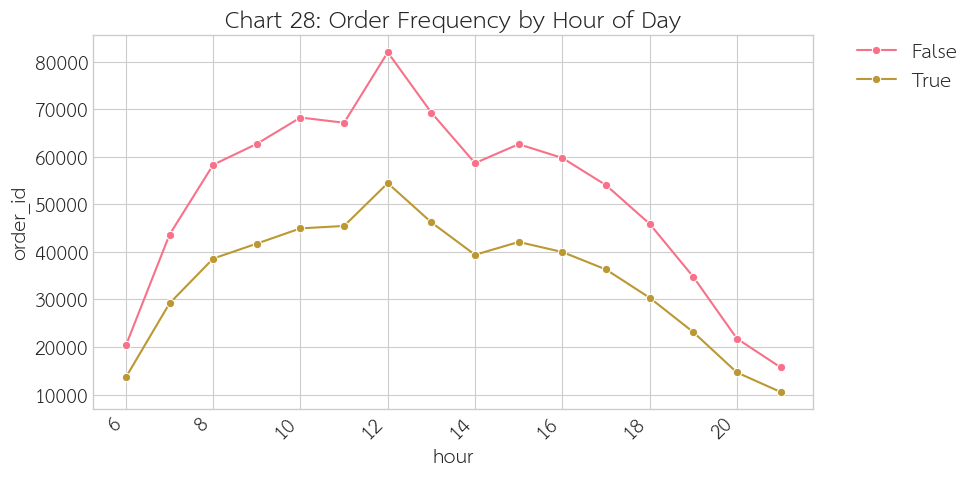

In [37]:
hourly = df.groupby(['hour', 'is_member'])['order_id'].nunique().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly, x='hour', y='order_id', hue='is_member', marker='o')
plt.title('Chart 28: Order Frequency by Hour of Day')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 28.5: 90-Day Temperature-Driven Category Crossover
### แผนภูมิที่ 28.5: Category Crossover ที่ขับเคลื่อนด้วยอุณหภูมิ 90 วัน

**Description:**
A 90-day time-series transitioning from February to May (heading into the extreme Thai Summer). It compares 'Coffee' units vs 'Juice & Smoothie' units. The red zone marks Peak Summer.

**คำอธิบาย:**
Time-series 90 วันจากกุมภาพันธ์ถึงพฤษภาคม (เข้าสู่ฤดูร้อนไทยสุดขีด) เปรียบเทียบยอด 'Coffee' vs 'Juice & Smoothie' โซนสีแดงบ่งชี้ช่วง Peak Summer

**Actionable Insight (Product/Solution Opportunity):**
Observe the specific week where the Juice/Smoothie line surges upwards and crosses the baseline. This proves temperature alters the category mix. The solution is a **'Climate-Triggered Packaging Rebalance'**—an automated supply chain rule that triggers a 300% increase in orders for clear plastic cups and dome lids exactly two weeks before this historical crossover, preventing catastrophic stockouts of cold packaging.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
สังเกตสัปดาห์ที่เส้น Juice/Smoothie พุ่งขึ้นและข้ามเส้นพื้นฐาน ซึ่งพิสูจน์ว่าอุณหภูมิเปลี่ยน category mix วิธีแก้คือ **'Climate-Triggered Packaging Rebalance'** กฎ supply chain อัตโนมัติที่ทริกเกอร์การเพิ่มออเดอร์ถ้วยพลาสติกใสและฝาโดม 300% สองสัปดาห์ก่อน crossover ประวัติศาสตร์นี้ ป้องกัน stockout หายนะของบรรจุภัณฑ์เย็น

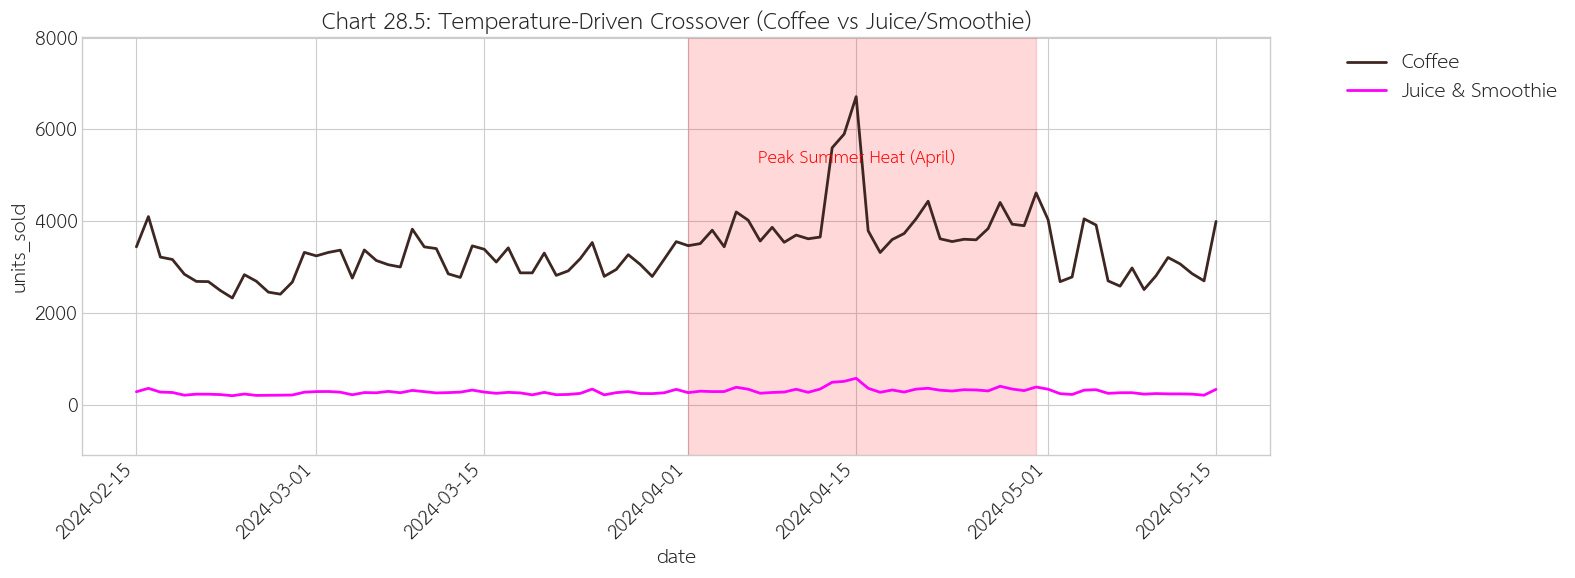

In [38]:
q2_temp = df[(df['date'] >= '2024-02-15') & (df['date'] <= '2024-05-15')]
temp_ts = q2_temp[q2_temp['category'].isin(['Coffee', 'Juice & Smoothie'])].groupby(['date', 'category'])['units_sold'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=temp_ts, x='date', y='units_sold', hue='category', palette=['#3e2723', 'magenta'], linewidth=2)
plt.axvspan(pd.Timestamp('2024-04-01'), pd.Timestamp('2024-04-30'), color='red', alpha=0.15)
plt.text(pd.Timestamp('2024-04-15'), plt.ylim()[1]*0.75, 'Peak Summer Heat (April)', color='red', ha='center', fontsize=12, fontweight='bold')
plt.title('Chart 28.5: Temperature-Driven Crossover (Coffee vs Juice/Smoothie)', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Chart 29: Category Preference Share
### แผนภูมิที่ 29: สัดส่วนความต้องการตามหมวดสินค้า

**Description:**
A 100% stacked bar chart that normalizes the volume of products sold within each category, split by membership status.

**คำอธิบาย:**
100% stacked bar chart ที่ normalize ปริมาณสินค้าที่ขายในแต่ละหมวด แยกตามสถานะสมาชิก

**Actionable Insight:**
Reveals if Members lean more heavily towards high-margin Coffee or add-on Bakery items. If Walk-ins rarely buy Merchandise, inventory forecasting models must dynamically weigh Walk-in foot traffic predictions strictly towards beverage supplies.

**Insight ที่นำไปใช้ได้:**
เผยว่าสมาชิกเอนเอียงต่อกาแฟ margin สูงหรือสินค้าเบเกอรี่ add-on มากกว่า หาก Walk-in แทบไม่ซื้อ Merchandise โมเดลพยากรณ์สินค้าคงคลังต้องถ่วงน้ำหนักการทำนาย foot traffic Walk-in ไปที่อุปกรณ์เครื่องดื่มเท่านั้นอย่างไดนามิก

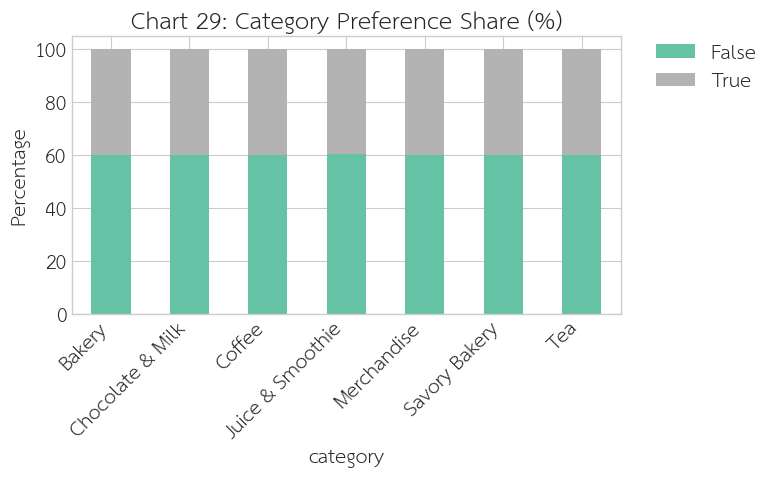

In [39]:
cat_pref = df.groupby(['category', 'is_member'])['units_sold'].sum().unstack()
cat_pref = cat_pref.div(cat_pref.sum(axis=1), axis=0) * 100
cat_pref.plot(kind='bar', stacked=True, colormap='Set2', figsize=(8,5))
plt.title('Chart 29: Category Preference Share (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 30: Monthly Active Users (MAU) Trend
### แผนภูมิที่ 30: แนวโน้ม Monthly Active Users (MAU)

**Description:**
A chronological bar chart plotting the number of unique customers engaging with the brand every month.

**คำอธิบาย:**
แผนภูมิแท่งตามลำดับเวลาที่แสดงจำนวนลูกค้าเฉพาะที่มีส่วนร่วมกับแบรนด์ทุกเดือน

**Actionable Insight:**
Identifies macro-level business health. If MAU is steadily growing, baseline sales predictions for future horizons must be naturally elevated regardless of promotions or seasons, reflecting the growing customer pool.

**Insight ที่นำไปใช้ได้:**
ระบุสุขภาพระดับมหภาคของธุรกิจ หาก MAU เติบโตต่อเนื่อง การทำนายยอดขายพื้นฐานสำหรับขอบฟ้าอนาคตต้องสูงขึ้นตามธรรมชาติโดยไม่คำนึงถึงโปรโมชันหรือฤดูกาล สะท้อน customer pool ที่กำลังเติบโต

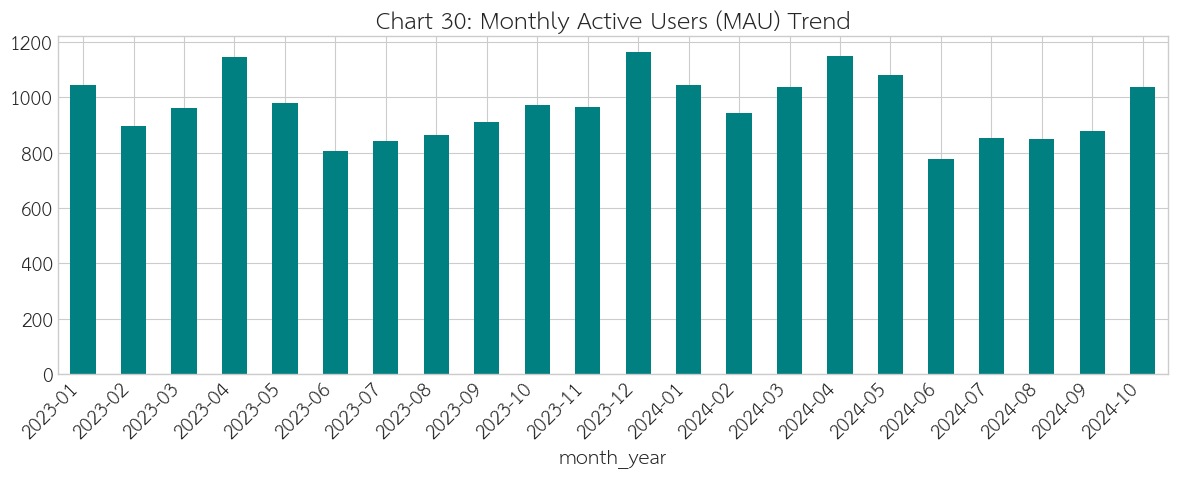

In [40]:
order['month_year'] = order['date'].dt.to_period('M')
mau = order.dropna(subset=['customer_id']).groupby('month_year')['customer_id'].nunique()
plt.figure(figsize=(12, 5))
mau.plot(kind='bar', color='teal')
plt.title('Chart 30: Monthly Active Users (MAU) Trend')
plt.xticks(rotation=45)
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 31: Customer Cohort Retention Heatmap
### แผนภูมิที่ 31: Heatmap การรักษาลูกค้า Cohort

**Description:**
A triangular heatmap tracking groups of customers based on the month they made their first purchase.

**คำอธิบาย:**
Heatmap สามเหลี่ยมติดตามกลุ่มลูกค้าตามเดือนที่ซื้อครั้งแรก

**Actionable Insight:**
A massive drop-off in Month 2 indicates poor onboarding. Consistent long-term retention allows us to mathematically calculate Customer Lifetime Value (LTV) and predict stable future revenue streams.

**Insight ที่นำไปใช้ได้:**
การหลุดลอดมากในเดือนที่ 2 บ่งบอก onboarding ที่แย่ การรักษาในระยะยาวที่สม่ำเสมอช่วยให้เราคำนวณ Customer Lifetime Value (LTV) ทางคณิตศาสตร์และทำนายกระแสรายได้ในอนาคตที่มั่นคงได้

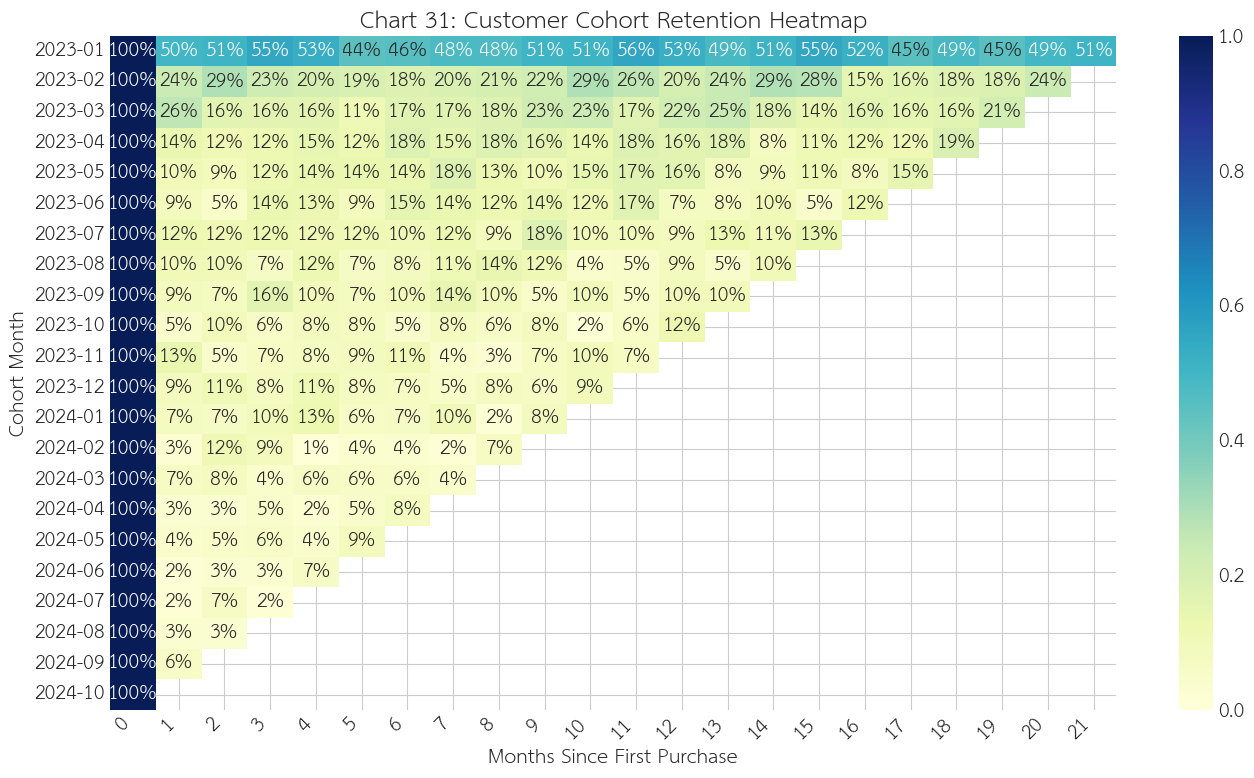

In [41]:
cohorts = order.dropna(subset=['customer_id'])[['customer_id', 'date']].copy()
cohorts['cohort_month'] = cohorts.groupby('customer_id')['date'].transform('min').dt.to_period('M')
cohorts['order_month'] = cohorts['date'].dt.to_period('M')
cohort_group = cohorts.groupby(['cohort_month', 'order_month'])['customer_id'].nunique().reset_index()
cohort_group['period_number'] = (cohort_group['order_month'] - cohort_group['cohort_month']).apply(lambda x: x.n)
cohort_pivot = cohort_group.pivot(index='cohort_month', columns='period_number', values='customer_id')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=1.0)
plt.title('Chart 31: Customer Cohort Retention Heatmap')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 32: Customer LTV by Home Neighborhood
### แผนภูมิที่ 32: LTV ของลูกค้าตาม Home Neighborhood

**Description:**
A boxplot evaluating the Lifetime Value of customers grouped by the primary neighborhood type they reside or work in.

**คำอธิบาย:**
Boxplot ประเมิน Lifetime Value ของลูกค้าที่จัดกลุ่มตามประเภทย่านหลักที่พวกเขาอาศัยหรือทำงาน

**Actionable Insight:**
Helps identify the geographic source of high-value customers. If customers living near Hospitals have exceptionally high LTVs, any new store opened near a hospital should mathematically expect a higher baseline revenue curve.

**Insight ที่นำไปใช้ได้:**
ช่วยระบุแหล่งทางภูมิศาสตร์ของลูกค้ามูลค่าสูง หากลูกค้าที่อยู่ใกล้โรงพยาบาลมี LTV สูงผิดปกติ สาขาใหม่ที่เปิดใกล้โรงพยาบาลควรคาดหวังเส้นโค้งรายได้พื้นฐานที่สูงกว่าทางคณิตศาสตร์

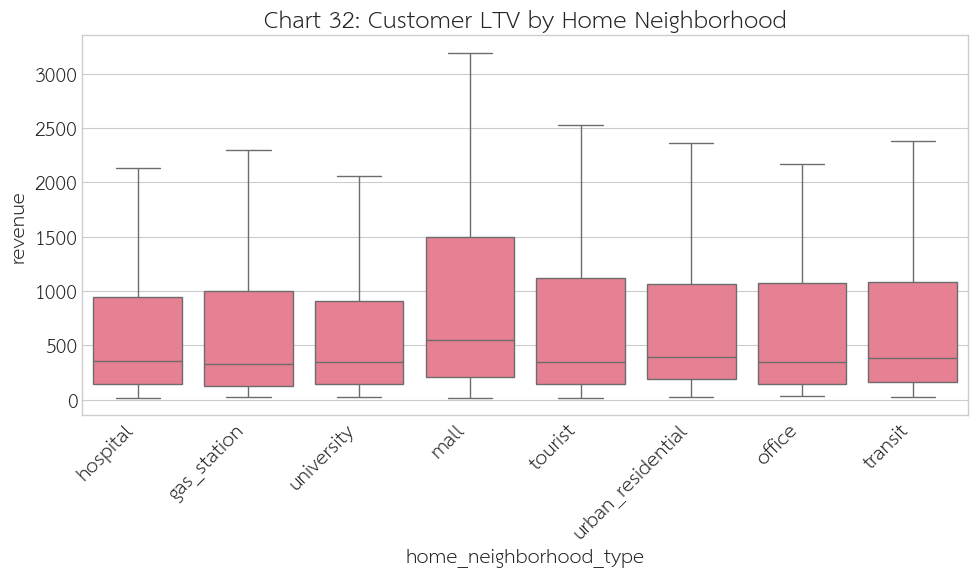

In [42]:
ltv = df.dropna(subset=['customer_id']).groupby('customer_id')['revenue'].sum().reset_index()
ltv = ltv.merge(cust[['customer_id', 'home_neighborhood_type']], on='customer_id')
plt.figure(figsize=(10,6))
sns.boxplot(data=ltv, x='home_neighborhood_type', y='revenue', showfliers=False)
plt.title('Chart 32: Customer LTV by Home Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 33: Avg LTV by Registration Year (Vintage)
### แผนภูมิที่ 33: LTV เฉลี่ยตามปีลงทะเบียน (Vintage)

**Description:**
A bar chart comparing the Lifetime Value of Early Adopter customers versus newly acquired customers.

**คำอธิบาย:**
แผนภูมิแท่งเปรียบเทียบ Lifetime Value ของลูกค้า Early Adopter กับลูกค้าที่ได้รับมาใหม่

**Actionable Insight:**
Reveals if the customer base is degrading in quality. If older cohorts spend significantly more per month than new cohorts, long-term revenue growth is highly vulnerable to early-adopter churn.

**Insight ที่นำไปใช้ได้:**
เผยว่าฐานลูกค้ากำลังเสื่อมคุณภาพหรือไม่ หาก cohort เก่าใช้จ่ายต่อเดือนมากกว่า cohort ใหม่อย่างมีนัยสำคัญ การเติบโตรายได้ระยะยาวเสี่ยงสูงต่อการ churn ของ early adopter

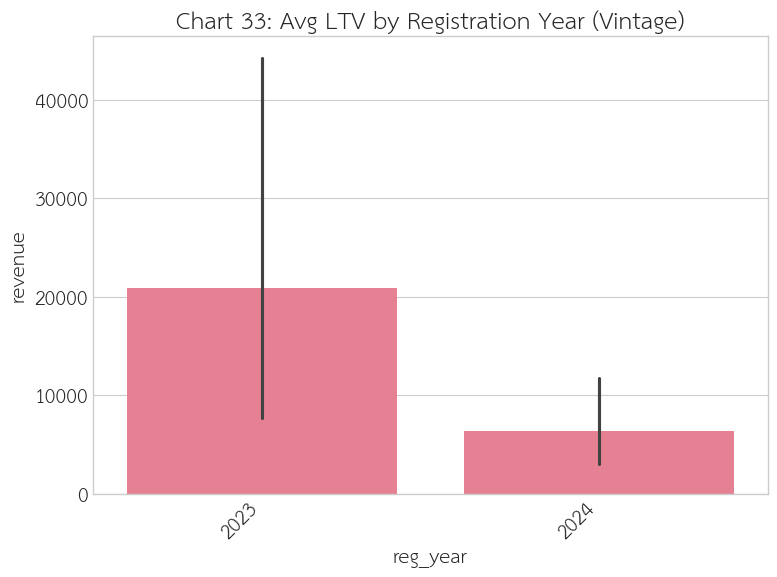

In [43]:
vintage = ltv.merge(cust[['customer_id', 'registration_date']], on='customer_id')
vintage['reg_year'] = vintage['registration_date'].dt.year
plt.figure(figsize=(8,6))
sns.barplot(data=vintage, x='reg_year', y='revenue')
plt.title('Chart 33: Avg LTV by Registration Year (Vintage)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 34: Cross-Store Shopping Behavior
### แผนภูมิที่ 34: พฤติกรรมการซื้อข้ามสาขา

**Description:**
A distribution bar chart counting how many distinct store branches a single customer visits.

**คำอธิบาย:**
Distribution bar chart นับจำนวนสาขาเฉพาะที่ลูกค้าคนเดียวเยี่ยมชม

**Actionable Insight:**
Measures brand loyalty versus location loyalty. If a massive segment visits 3+ stores, it implies that localized marketing campaigns will cannibalize sales from neighboring stores, creating a Spillover Effect.

**Insight ที่นำไปใช้ได้:**
วัดความภักดีต่อแบรนด์กับความภักดีต่อสถานที่ หากกลุ่มใหญ่เยี่ยมชม 3+ สาขา แสดงว่าแคมเปญการตลาดเฉพาะถิ่นจะกินส่วนแบ่งยอดขายจากสาขาใกล้เคียง สร้าง Spillover Effect

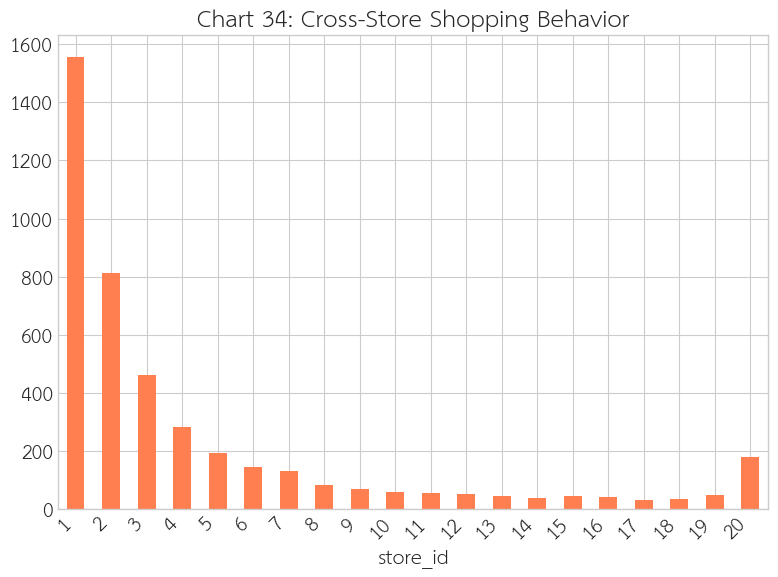

In [44]:
cross_store = order.dropna(subset=['customer_id']).groupby('customer_id')['store_id'].nunique().value_counts().sort_index()
plt.figure(figsize=(8,6))
cross_store.plot(kind='bar', color='coral')
plt.title('Chart 34: Cross-Store Shopping Behavior')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 35: Lorenz Curve (Revenue Concentration)
### แผนภูมิที่ 35: Lorenz Curve (ความเข้มข้นรายได้)

**Description:**
A cumulative distribution curve ranking all customers by total spend and plotting the cumulative percentage of revenue they generate.

**คำอธิบาย:**
Cumulative distribution curve จัดอันดับลูกค้าทั้งหมดตามยอดใช้จ่ายรวมและแสดงเปอร์เซ็นต์สะสมของรายได้ที่พวกเขาสร้าง

**Actionable Insight:**
Proves the Pareto Principle (80/20 rule). If the curve is extremely bowed, a tiny fraction of customers generate the vast majority of income. The forecasting model must be hyper-sensitive to the behavior of this micro-population.

**Insight ที่นำไปใช้ได้:**
พิสูจน์หลักการ Pareto (กฎ 80/20) หาก curve โค้งมากสุดขีด ลูกค้าเพียงส่วนน้อยสร้างรายได้ส่วนใหญ่ โมเดลพยากรณ์ต้องไวต่อพฤติกรรมของประชากรขนาดจิ๋วนี้อย่างมาก

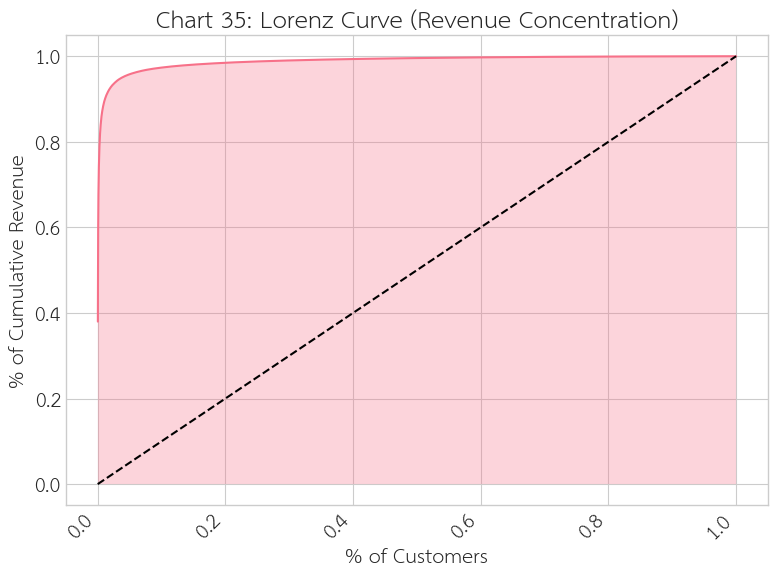

In [45]:
customer_revenue = df.dropna(subset=['customer_id']).groupby('customer_id')['revenue'].sum().sort_values(ascending=False)
cumulative_revenue = customer_revenue.cumsum() / customer_revenue.sum()
plt.figure(figsize=(8,6))
plt.plot(np.arange(1, len(cumulative_revenue)+1) / len(cumulative_revenue), cumulative_revenue.values)
plt.fill_between(np.arange(1, len(cumulative_revenue)+1) / len(cumulative_revenue), cumulative_revenue.values, alpha=0.3)
plt.title('Chart 35: Lorenz Curve (Revenue Concentration)')
plt.xlabel('% of Customers')
plt.ylabel('% of Cumulative Revenue')
plt.plot([0,1], [0,1], 'k--')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 35.5: 90-Day Weekend Micro-Migration (Residential vs Mall)
### แผนภูมิที่ 35.5: Weekend Micro-Migration 90 วัน (Residential vs Mall)

**Description:**
A 90-day time-series plotting an Urban Residential store against a Mall store. Yellow shaded regions highlight Weekends.

**คำอธิบาย:**
Time-series 90 วันแสดง Urban Residential store เทียบกับ Mall store พื้นที่สีเหลืองเน้นวันหยุดสุดสัปดาห์

**Actionable Insight (Product/Solution Opportunity):**
This graph shows perfectly inverse demand waves. Residential peaks on weekdays and crashes on weekends, while Mall stores explode on weekends. The solution is a **'Dynamic Part-Time Roster'**—an automated HR system that shares a pool of baristas, assigning them to Residential branches Monday-Friday, and shifting them to Mall branches Saturday-Sunday to optimize labor costs.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
กราฟนี้แสดงคลื่นความต้องการที่ผกผันอย่างสมบูรณ์ Residential สูงสุดวันธรรมดาและตกวันหยุดสุดสัปดาห์ ขณะที่ Mall ระเบิดวันหยุดสุดสัปดาห์ วิธีแก้คือ **'Dynamic Part-Time Roster'** ระบบ HR อัตโนมัติที่แชร์กลุ่มบาริสต้า มอบหมายให้สาขา Residential วันจันทร์-ศุกร์ และย้ายไปสาขา Mall วันเสาร์-อาทิตย์ เพื่อเพิ่มประสิทธิภาพต้นทุนแรงงาน

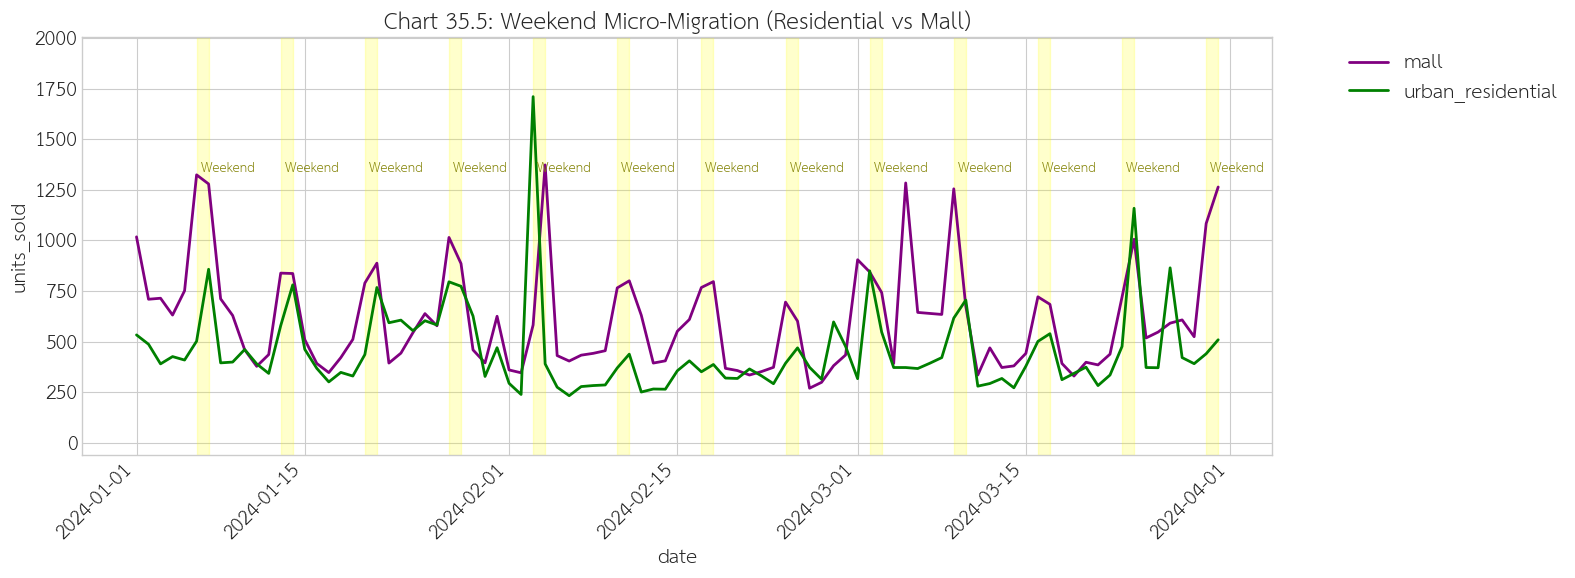

In [46]:
q1_mig = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-03-31')]
mall = store[store['neighborhood_type'] == 'mall']['store_id'].unique()[0]
res = store[store['neighborhood_type'] == 'urban_residential']['store_id'].unique()[0]
mig_ts = q1_mig[q1_mig['store_id'].isin([mall, res])].groupby(['date', 'neighborhood_type'])['units_sold'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=mig_ts, x='date', y='units_sold', hue='neighborhood_type', palette=['purple', 'green'], linewidth=2)
weekends = date_dim[(date_dim['date'] >= '2024-01-01') & (date_dim['date'] <= '2024-03-31') & (date_dim['is_weekend'])]
if not weekends.empty:
    we_groups = (weekends['date'] != weekends['date'].shift(1) + pd.Timedelta(days=1)).cumsum()
    for _, group in weekends.groupby(we_groups):
        plt.axvspan(group['date'].min(), group['date'].max(), color='yellow', alpha=0.2)
        plt.text(group['date'].min(), plt.ylim()[1]*0.75, ' Weekend', color='olive', fontsize=9)
plt.title('Chart 35.5: Weekend Micro-Migration (Residential vs Mall)', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Chart 36: Active Whales Over Time
### แผนภูมิที่ 36: Whale ที่ยังใช้งานตลอดเวลา

**Description:**
A line plot isolating the monthly engagement exclusively for the Top 5% highest-spending Whale customers.

**คำอธิบาย:**
กราฟเส้นที่แยกการมีส่วนร่วมรายเดือนเฉพาะสำหรับลูกค้า Whale ที่ใช้จ่ายสูงสุด 5% แรก

**Actionable Insight:**
Losing a single Whale can crash a store's daily revenue average. Tracking their churn rate alerts us to structural demand shifts that general models might mistake as ordinary seasonal dips.

**Insight ที่นำไปใช้ได้:**
การสูญเสีย Whale เดียวสามารถทำให้ค่าเฉลี่ยรายได้รายวันของสาขาตกได้ การติดตาม churn rate ของพวกเขาแจ้งเตือนเราถึงการเปลี่ยนแปลงโครงสร้างความต้องการที่โมเดลทั่วไปอาจเข้าใจผิดว่าเป็นช่วงฤดูกาลปกติ

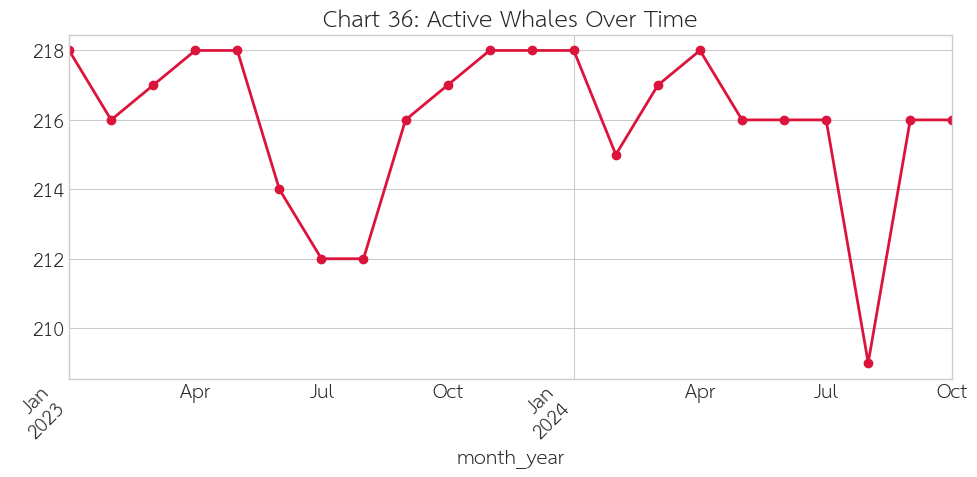

In [47]:
top_5_pct_threshold = customer_revenue.quantile(0.95)
whales = customer_revenue[customer_revenue >= top_5_pct_threshold].index
whale_orders = order[order['customer_id'].isin(whales)]
whale_mau = whale_orders.groupby('month_year')['customer_id'].nunique()
plt.figure(figsize=(10,5))
whale_mau.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Chart 36: Active Whales Over Time')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 36.5: 90-Day Payday Splurge Behavior (Luxury vs Necessity)
### แผนภูมิที่ 36.5: พฤติกรรมการใช้จ่ายฟุ่มเฟือยวันเงินเดือน 90 วัน (Luxury vs Necessity)

**Description:**
A 90-day time-series comparing the sales of 'Merchandise' (Luxury) vs 'Coffee' (Necessity), with vertical lines marking Paydays.

**คำอธิบาย:**
Time-series 90 วันเปรียบเทียบยอดขาย 'Merchandise' (Luxury) vs 'Coffee' (Necessity) พร้อมเส้นแนวตั้งบ่งชี้วันเงินเดือน

**Actionable Insight (Product/Solution Opportunity):**
Notice how Coffee sales are relatively stable across the month, but Merchandise sales experience violent spikes **exactly on Paydays**. This proves that marketing budgets for Tumblers and Premium items are wasted mid-month. The solution is **'Targeted FOMO Marketing'**—an automated ad engine that only deploys merchandise ads 48 hours around Payday to maximize ROI.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
สังเกตว่ายอดขายกาแฟค่อนข้างเสถียรตลอดเดือน แต่ยอดขาย Merchandise มีสไปก์รุนแรง **ตรงกับวันเงินเดือนพอดี** ซึ่งพิสูจน์ว่างบการตลาดสำหรับ Tumbler และสินค้า Premium สูญเปล่ากลางเดือน วิธีแก้คือ **'Targeted FOMO Marketing'** เครื่องมือโฆษณาอัตโนมัติที่ deploy โฆษณา merchandise เพียง 48 ชั่วโมงรอบวันเงินเดือนเพื่อเพิ่ม ROI สูงสุด

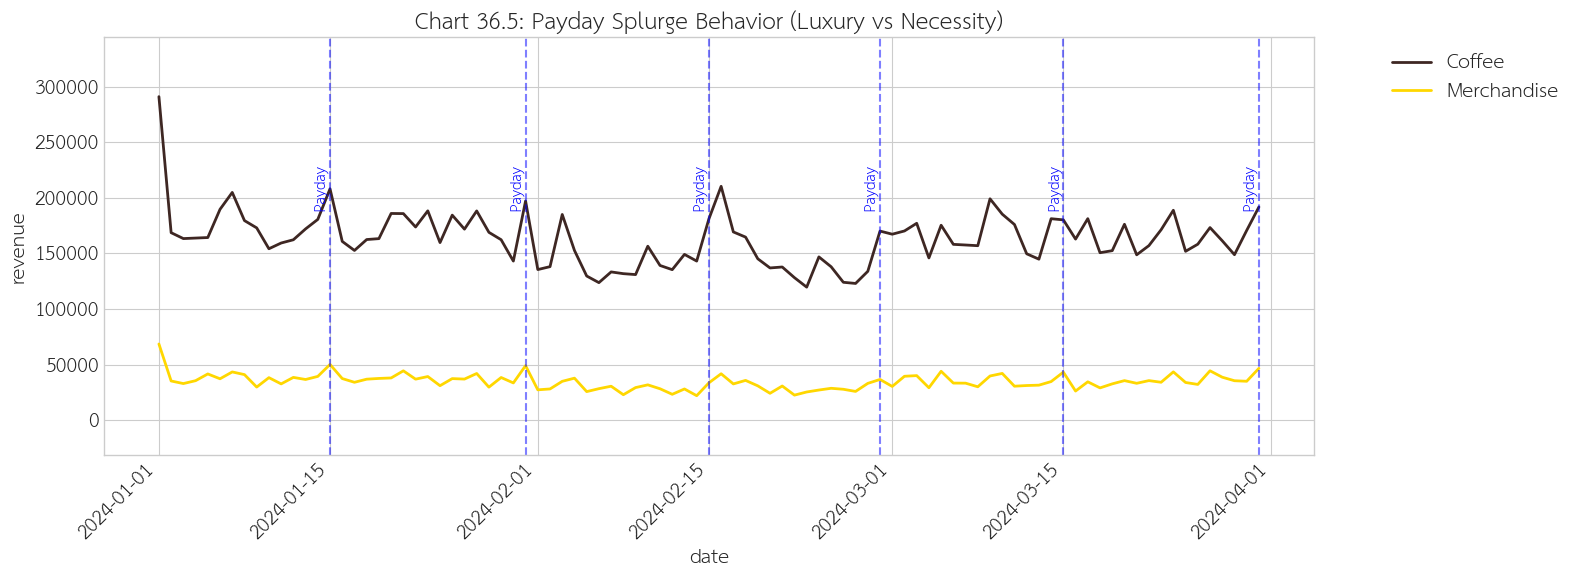

In [48]:
q1_splurge = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-03-31')]
splurge_ts = q1_splurge[q1_splurge['category'].isin(['Coffee', 'Merchandise'])].groupby(['date', 'category'])['revenue'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=splurge_ts, x='date', y='revenue', hue='category', palette=['#3e2723', 'gold'], linewidth=2)
paydays = date_dim[(date_dim['date'] >= '2024-01-01') & (date_dim['date'] <= '2024-03-31') & (date_dim['is_payday'])]
for d in paydays['date']:
    plt.axvline(d, color='blue', linestyle='--', alpha=0.5)
    plt.text(d, plt.ylim()[1]*0.75, ' Payday', color='blue', rotation=90, va='top', ha='right', fontsize=10)
plt.title('Chart 36.5: Payday Splurge Behavior (Luxury vs Necessity)', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
if ax.get_legend() is not None: plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Section 6: Product & Inventory Dynamics
## หมวดที่ 6: พลวัตสินค้าและสินค้าคงคลัง

### Chart 37: Category Co-occurrence Heatmap
### แผนภูมิที่ 37: Heatmap การเกิดร่วมกันของหมวดสินค้า

**Description:**
A matrix heatmap visualizing Market Basket Analysis. The numbers indicate how often two distinct product categories are purchased in the same order.

**คำอธิบาย:**
Matrix heatmap แสดง Market Basket Analysis ตัวเลขบ่งชี้ความถี่ที่หมวดสินค้าสองหมวดถูกซื้อในออเดอร์เดียวกัน

**Actionable Insight:**
Critical for cross-selling strategies. If Coffee and Bakery have massive co-occurrence, a stockout in Bakery will heavily depress Coffee sales, meaning inventory forecasts must be mathematically coupled.

**Insight ที่นำไปใช้ได้:**
สำคัญมากสำหรับกลยุทธ์ cross-selling หากกาแฟและเบเกอรี่มีการเกิดร่วมกันสูง stockout เบเกอรี่จะกดยอดกาแฟอย่างหนัก ซึ่งหมายความว่าการพยากรณ์สินค้าคงคลังต้องถูก couple ทางคณิตศาสตร์

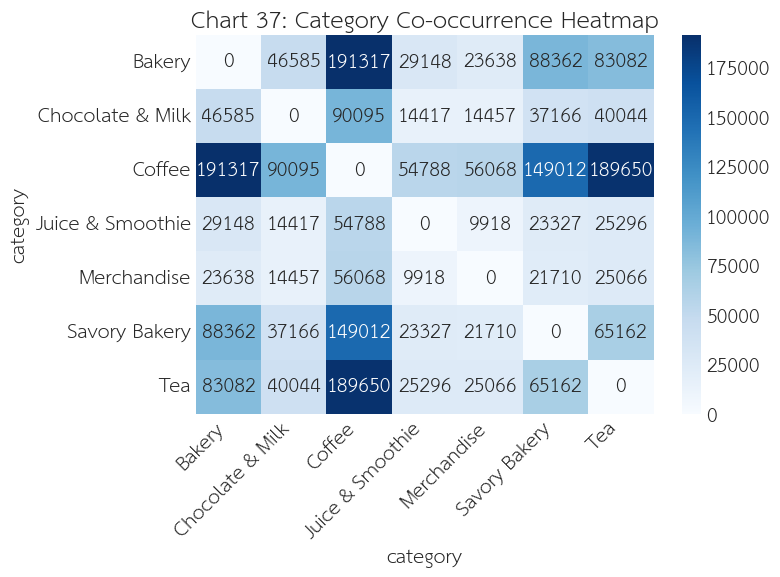

In [49]:
basket_matrix = df.groupby(['order_id', 'category'])['units_sold'].sum().unstack().fillna(0).apply(lambda x: (x>0).astype(int))
co_occurrence = basket_matrix.T.dot(basket_matrix)
np.fill_diagonal(co_occurrence.values, 0)
plt.figure(figsize=(8,6))
sns.heatmap(co_occurrence, cmap='Blues', annot=True, fmt='d')
plt.title('Chart 37: Category Co-occurrence Heatmap')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 38: Seasonal vs Regular Item Sales
### แผนภูมิที่ 38: ยอดขายสินค้า Seasonal vs Regular

**Description:**
A 7-Day Moving Average line plot tracking the lifecycle of Seasonal/Limited Time menu items versus permanent fixtures.

**คำอธิบาย:**
กราฟเส้น 7-Day Moving Average ติดตาม lifecycle ของสินค้าเมนู Seasonal/Limited Time เทียบกับรายการถาวร

**Actionable Insight:**
Seasonal items defy standard autoregressive patterns; they launch with a massive spike and exhibit exponential decay. Forecasting these items requires unique features such as 'days_since_launch'.

**Insight ที่นำไปใช้ได้:**
สินค้า Seasonal ต้านทาน pattern autoregressive มาตรฐาน พวกมันเปิดตัวด้วยสไปก์ใหญ่และแสดง exponential decay การพยากรณ์สินค้าเหล่านี้ต้องการฟีเจอร์เฉพาะเช่น 'days_since_launch'

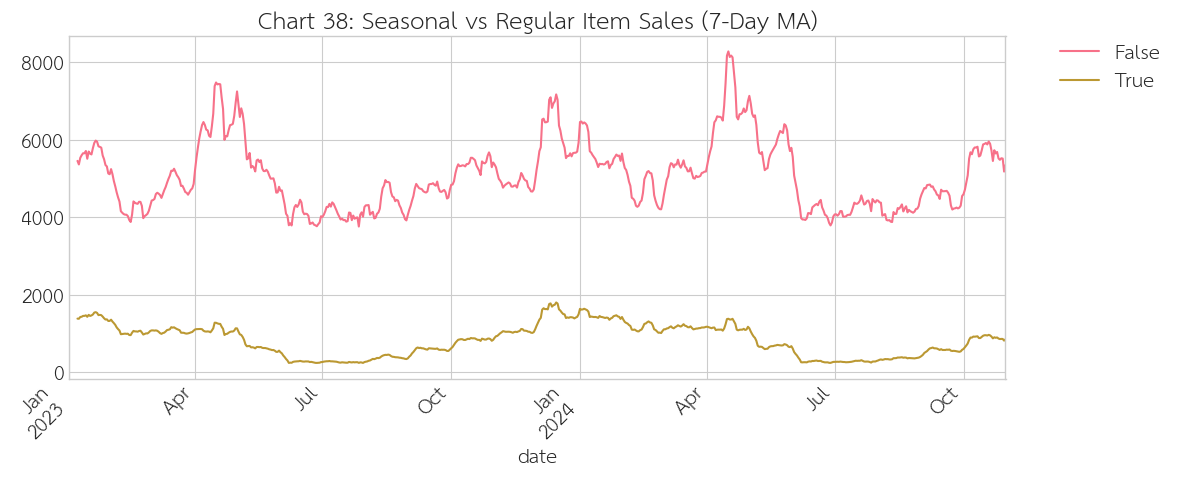

In [50]:
seasonal_perf = df.groupby(['date', 'is_seasonal'])['units_sold'].sum().unstack().rolling(7).mean()
plt.figure(figsize=(12,5))
seasonal_perf.plot(ax=plt.gca())
plt.title('Chart 38: Seasonal vs Regular Item Sales (7-Day MA)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 39: Macro Trend - Average Price Per Unit
### แผนภูมิที่ 39: แนวโน้มมหภาค - ราคาเฉลี่ยต่อหน่วย

**Description:**
A time-series line plot tracking the global average revenue generated per single unit sold over the entire historical window.

**คำอธิบาย:**
กราฟเส้น time-series ติดตามรายได้เฉลี่ยทั่วโลกต่อหน่วยที่ขายได้ตลอดช่วงประวัติทั้งหมด

**Actionable Insight:**
Acts as an indicator of menu inflation. If this line trends upwards steadily, any future horizon predictions must apply this inflationary multiplier to raw unit forecasts to predict accurate gross revenue.

**Insight ที่นำไปใช้ได้:**
ทำหน้าที่เป็นตัวบ่งชี้ภาวะเงินเฟ้อของเมนู หากเส้นนี้มีแนวโน้มสูงขึ้นอย่างต่อเนื่อง การทำนายขอบฟ้าอนาคตต้องใช้ตัวคูณเงินเฟ้อนี้กับการพยากรณ์หน่วย raw เพื่อทำนายรายได้รวมที่แม่นยำ

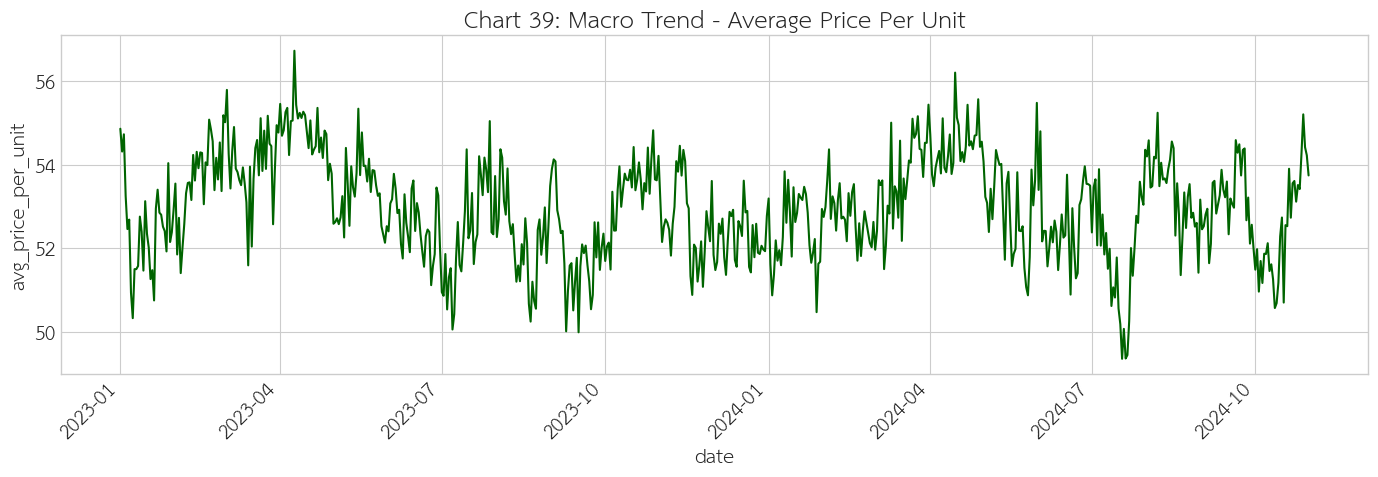

In [51]:
price_trend = df.groupby('date').agg({'revenue': 'sum', 'units_sold': 'sum'}).reset_index()
price_trend['avg_price_per_unit'] = price_trend['revenue'] / price_trend['units_sold']
plt.figure(figsize=(14, 5))
sns.lineplot(data=price_trend, x='date', y='avg_price_per_unit', color='darkgreen')
plt.title('Chart 39: Macro Trend - Average Price Per Unit')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 40: Stockout Duration Distribution
### แผนภูมิที่ 40: การกระจายระยะเวลา Stockout

**Description:**
A histogram charting the consecutive number of days a specific item remains in a Stockout state before being replenished.

**คำอธิบาย:**
ฮิสโตแกรมที่แสดงจำนวนวันต่อเนื่องที่สินค้าเฉพาะอยู่ในสถานะ Stockout ก่อนจะมีการเติมสินค้า

**Actionable Insight:**
Exposes severe supply chain bottlenecks. If items typically stay stocked out for 4-5 days, the forecasting model must zero out predictions for several days following an initial stockout flag.

**Insight ที่นำไปใช้ได้:**
เผยคอขวด supply chain ที่รุนแรง หากสินค้ามักหมดสต็อก 4-5 วัน โมเดลพยากรณ์ต้องทำให้การทำนายเป็นศูนย์ในหลายวันหลังจาก flag stockout เริ่มต้น

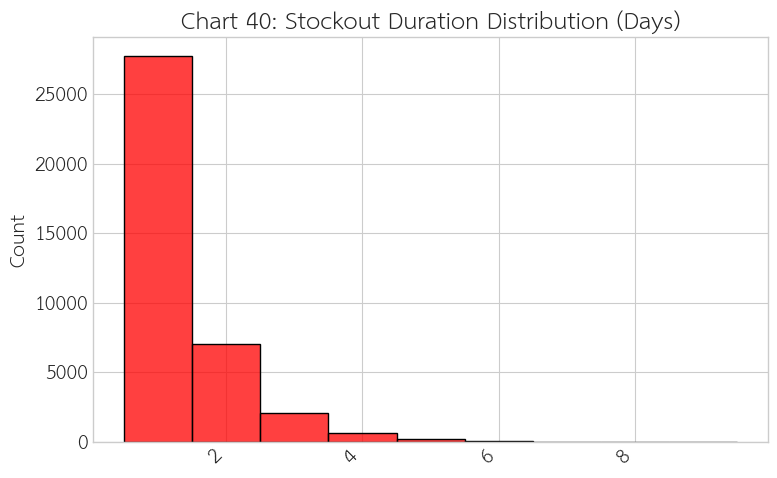

In [52]:
inventory['stockout_block'] = (inventory['is_stockout'] != inventory['is_stockout'].shift(1)).cumsum()
stockout_duration = inventory[inventory['is_stockout'] == True].groupby(['store_id', 'product_id', 'stockout_block']).size()
plt.figure(figsize=(8,5))
sns.histplot(stockout_duration[stockout_duration < 10], bins=9, discrete=True, color='red')
plt.title('Chart 40: Stockout Duration Distribution (Days)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 41: Stockout Rate by Neighborhood
### แผนภูมิที่ 41: อัตรา Stockout ตามย่าน

**Description:**
A bar chart representing the percentage of total operational days that stores in different neighborhoods experience inventory shortages.

**คำอธิบาย:**
แผนภูมิแท่งแสดงเปอร์เซ็นต์ของวันเปิดทำการทั้งหมดที่สาขาในย่านต่างๆ ประสบกับการขาดแคลนสินค้าคงคลัง

**Actionable Insight:**
Highlights locations with systemic logistical failures. Consistently high stockout rates artificially depress historical units sold labels, meaning the true unconstrained demand for these locations is much higher.

**Insight ที่นำไปใช้ได้:**
เน้นสถานที่ที่มีความล้มเหลวด้านโลจิสติกส์เชิงระบบ อัตรา stockout ที่สูงอย่างสม่ำเสมอกดยอดขายในอดีตเทียมๆ หมายความว่าความต้องการที่แท้จริงไม่จำกัดของสถานที่เหล่านี้สูงกว่ามาก

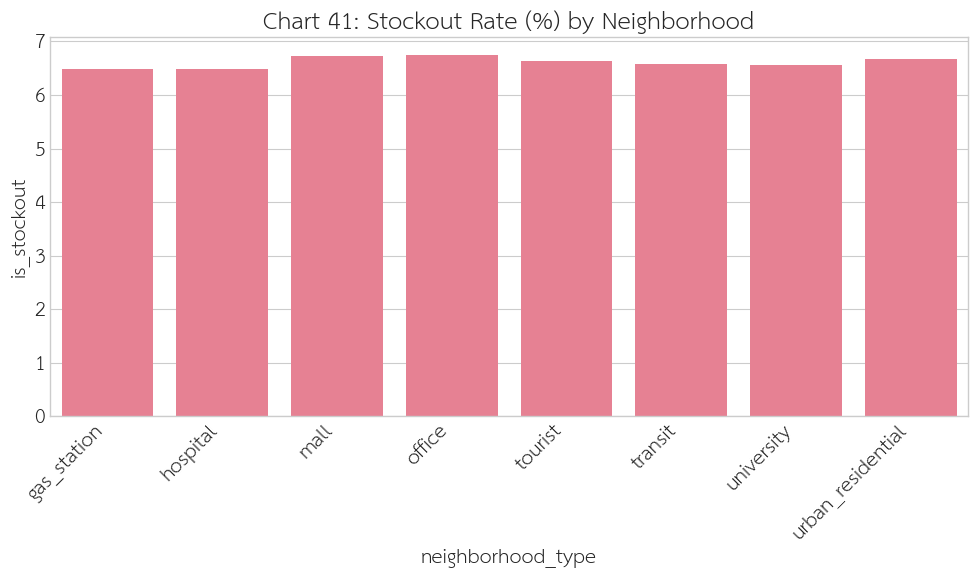

In [53]:
inv_store = inventory.merge(store[['store_id', 'neighborhood_type']], on='store_id')
stockout_rate = inv_store.groupby('neighborhood_type')['is_stockout'].mean().reset_index()
stockout_rate['is_stockout'] *= 100
plt.figure(figsize=(10,6))
sns.barplot(data=stockout_rate, x='neighborhood_type', y='is_stockout')
plt.title('Chart 41: Stockout Rate (%) by Neighborhood')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 42: Coffee Sales vs Merchandise Stockout
### แผนภูมิที่ 42: ยอดขายกาแฟ vs Stockout ของ Merchandise

**Description:**
A boxplot analyzing whether daily Coffee sales fluctuate when the Merchandise category is actively out of stock.

**คำอธิบาย:**
Boxplot วิเคราะห์ว่ายอดขายกาแฟรายวันผันผวนหรือไม่เมื่อหมวด Merchandise หมดสต็อก

**Actionable Insight:**
Tests for the Substitution Effect. If a customer walks in to buy a mug but it's out of stock, do they buy an expensive coffee out of frustration? If they do, Merchandise stockout becomes a positive predictive feature for Coffee.

**Insight ที่นำไปใช้ได้:**
ทดสอบ Substitution Effect หากลูกค้าเดินเข้ามาซื้อแก้วแต่หมดสต็อก พวกเขาซื้อกาแฟราคาแพงด้วยความหงุดหงิดหรือไม่? หากเป็นเช่นนั้น Merchandise stockout กลายเป็นฟีเจอร์ทำนายเชิงบวกสำหรับกาแฟ

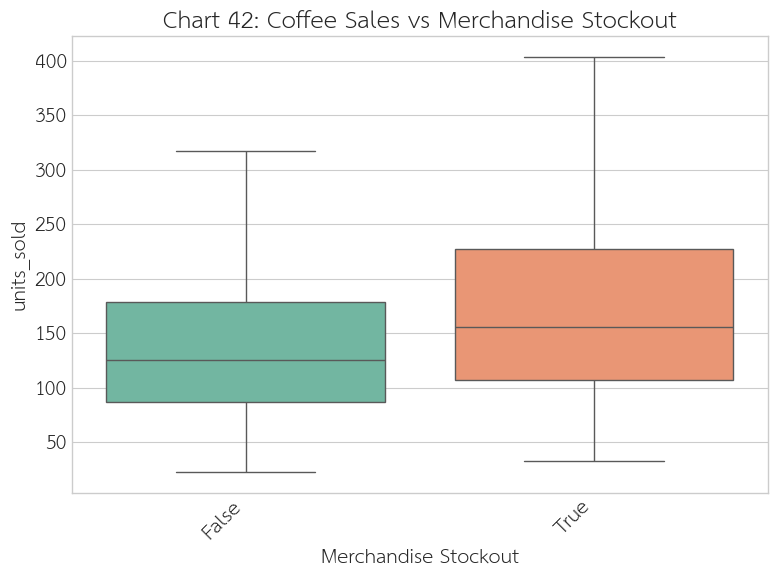

In [54]:
inv_cat = inv_store.merge(prod[['product_id', 'category']], on='product_id', how='left')
stockout_daily = inv_cat.groupby(['store_id', 'date', 'category'])['is_stockout'].max().unstack().fillna(False)
coffee_sales = df[df['category']=='Coffee'].groupby(['store_id', 'date'])['units_sold'].sum().reset_index()
coffee_vs_merch_stockout = coffee_sales.merge(stockout_daily[['Merchandise']], left_on=['store_id', 'date'], right_index=True, how='left')
plt.figure(figsize=(8, 6))
sns.boxplot(data=coffee_vs_merch_stockout, x='Merchandise', y='units_sold', showfliers=False, palette='Set2')
plt.title('Chart 42: Coffee Sales vs Merchandise Stockout')
plt.xlabel('Merchandise Stockout')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
if ax.get_legend() is not None:
    plt.setp(ax.get_legend().get_texts(), fontsize='10')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Chart 42.5: 90-Day Stockout Death Spiral (Cross-Selling Contagion)
### แผนภูมิที่ 42.5: Stockout Death Spiral 90 วัน (Cross-Selling Contagion)

**Description:**
A 90-day time-series of total store revenue, overlaid with red shaded blocks indicating days where a 'Core Coffee' item was completely out of stock.

**คำอธิบาย:**
Time-series 90 วันของรายได้รวมสาขา overlay ด้วยบล็อกสีแดงบ่งชี้วันที่สินค้ากาแฟหลักหมดสต็อกโดยสิ้นเชิง

**Actionable Insight (Product/Solution Opportunity):**
This graph reveals the 'Contagion Effect'. When a core item stocks out, it doesn't just reduce sales for that item—total revenue plummets because customers walk out without buying their usual bakery cross-sells. The solution is a **'Stockout Contagion Alert System'** that prioritizes emergency restocking based on an item's cross-selling weight, not just its individual sales volume.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
กราฟนี้เผย 'Contagion Effect' เมื่อสินค้าหลักหมดสต็อก มันไม่เพียงลดยอดขายสินค้านั้น รายได้รวมดิ่งเพราะลูกค้าเดินออกไปโดยไม่ซื้อเบเกอรี่ที่ cross-sell ปกติ วิธีแก้คือ **'Stockout Contagion Alert System'** ที่จัดลำดับความสำคัญการเติมฉุกเฉินตามน้ำหนัก cross-selling ของสินค้า ไม่ใช่ยอดขายรายบุคคล

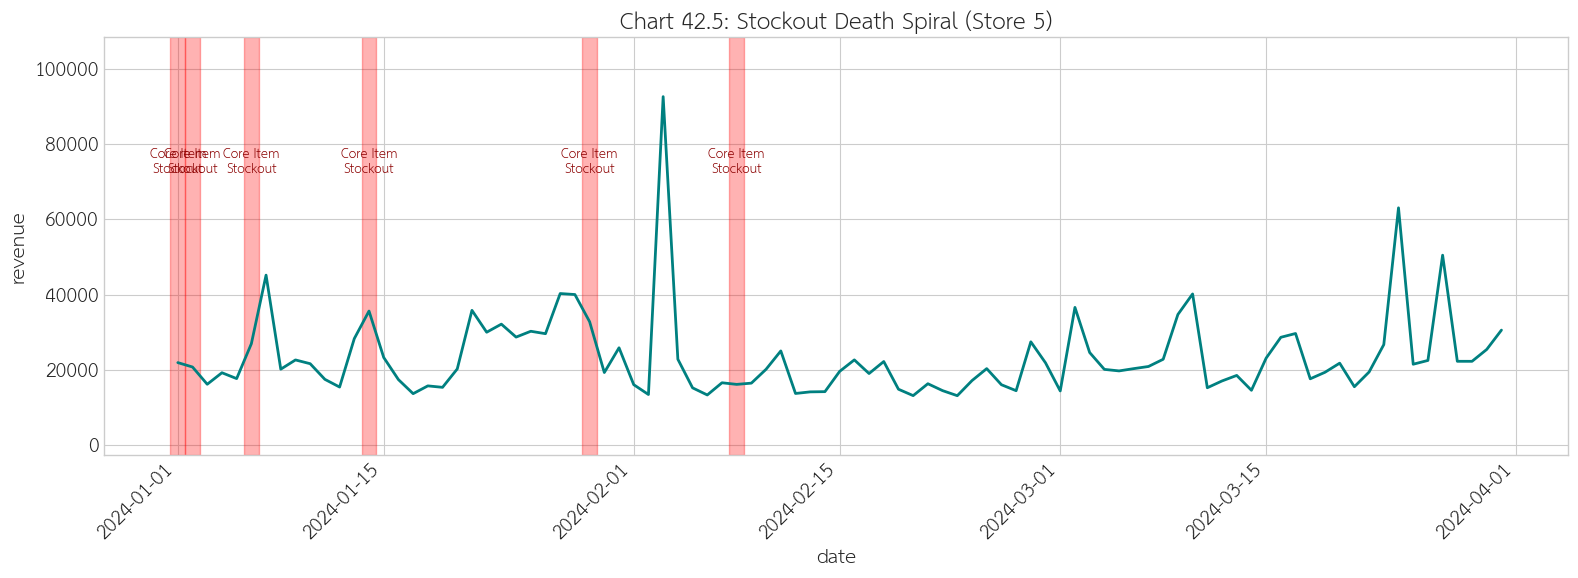

In [55]:
q1_stk = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-03-31')]
stk_store = 5
ts_rev = q1_stk[q1_stk['store_id'] == stk_store].groupby('date')['revenue'].sum().reset_index()
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=ts_rev, x='date', y='revenue', color='teal', linewidth=2)
stk_days = inventory[(inventory['store_id'] == stk_store) & (inventory['date'] >= '2024-01-01') & (inventory['date'] <= '2024-03-31') & (inventory['is_stockout']) & (inventory['product_id'] == 1)]
for d in stk_days['date'].unique():
    plt.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color='red', alpha=0.3)
    plt.text(d, plt.ylim()[1]*0.75, 'Core Item\nStockout', color='darkred', ha='center', fontsize=9)
plt.title(f'Chart 42.5: Stockout Death Spiral (Store {stk_store})', fontsize=16)
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Section 7: Unexpected Tabular Insights (Data Anomalies)
## หมวดที่ 7: Insight เชิงตารางที่ไม่คาดคิด (Data Anomalies)

### Table 1: Stores with Negative Promotion Lift
### ตารางที่ 1: สาขาที่มี Promotion Lift ติดลบ

**Description:**
A heatmap table listing the specific Store IDs where running an active promotion paradoxically resulted in a NEGATIVE percentage lift in units sold compared to their non-promo baseline.

**คำอธิบาย:**
ตาราง heatmap ที่แสดง Store ID เฉพาะที่การทำโปรโมชันที่ใช้งานอยู่ส่งผลให้ % lift ยอดขายเป็นลบ เมื่อเทียบกับค่าพื้นฐานที่ไม่มีโปรโมชัน

**Actionable Insight:**
Utterly counter-intuitive. This indicates stores where promotions either attract terrible cherry-picker customers who buy only loss-leaders, or where the promo mechanics actively confuse the local demographic. The business should immediately halt promotions at these branches.

**Insight ที่นำไปใช้ได้:**
ขัดกับสัญชาตญาณอย่างสิ้นเชิง บ่งชี้สาขาที่โปรโมชันดึงลูกค้าประเภท cherry-picker ที่แย่ (ซื้อเฉพาะสินค้า loss-leader) หรือกลไกโปรโมชันสับสนกลุ่มลูกค้าในท้องถิ่น ธุรกิจควรหยุดโปรโมชันที่สาขาเหล่านี้ทันที

In [56]:
promo_effect = daily_promo.groupby(['store_id', 'has_promo'])['units_sold'].mean().unstack()
promo_effect['promo_lift_pct'] = (promo_effect[True] - promo_effect[False]) / promo_effect[False] * 100
anti_promo = promo_effect.sort_values('promo_lift_pct').head(5)
anti_promo_stores = anti_promo.reset_index().merge(store[['store_id', 'neighborhood_type']], on='store_id')
anti_promo_stores.style.background_gradient(cmap='Reds_r', subset=['promo_lift_pct']).set_caption('Table 1: Stores with Lowest Promotion Lift (Bottom 5)')

,store_id,False,True,promo_lift_pct,neighborhood_type
0,12,22.970699,27.795486,21.004089,gas_station
1,7,26.752730,34.069320,27.348948,hospital
2,19,37.596635,48.215364,28.243828,university
3,9,54.447490,69.894235,28.369985,tourist
4,3,39.178420,51.968091,32.644682,university


### Table 2: High-Value Nomadic Customers
### ตารางที่ 2: ลูกค้า Nomadic มูลค่าสูง

**Description:**
A table identifying ultra-high-value Whale customers who spend massive amounts of money, but exhibit zero geographic loyalty (visiting 5 or more distinct store branches).

**คำอธิบาย:**
ตารางที่ระบุลูกค้า Whale มูลค่าสูงสุดที่ใช้จ่ายมหาศาล แต่แสดงความภักดีทางภูมิศาสตร์เป็นศูนย์ (เยี่ยมชม 5+ สาขาเฉพาะ)

**Actionable Insight:**
These customers are likely corporate couriers or regional sales reps. Because they are location-agnostic, their demand cannot be forecasted by looking at a single store's history. They act as nomadic demand shocks across the network.

**Insight ที่นำไปใช้ได้:**
ลูกค้าเหล่านี้น่าจะเป็นพนักงานส่งขององค์กรหรือตัวแทนขายระดับภูมิภาค เพราะพวกเขาไม่สนใจสถานที่ ความต้องการของพวกเขาไม่สามารถพยากรณ์ได้โดยการดูประวัติสาขาเดียว พวกเขาทำหน้าที่เป็น nomadic demand shocks ทั่วเครือข่าย

In [57]:
customer_loyalty = df.dropna(subset=['customer_id']).groupby('customer_id').agg(
    total_spend=('revenue', 'sum'),
    unique_stores=('store_id', 'nunique')
)
polygamists = customer_loyalty[customer_loyalty['unique_stores'] >= 5].sort_values('total_spend', ascending=False).head(10)
polygamists.style.background_gradient(cmap='Greens', subset=['total_spend']).background_gradient(cmap='Purples', subset=['unique_stores']).set_caption('Table 2: High-Value Nomadic Customers')

,total_spend,unique_stores
customer_id,,
2448.000000,31865001.900000,20
4414.000000,11713720.200000,20
3827.000000,5991057.100000,20
5668.000000,4441252.900000,20
5652.000000,2744151.850000,20
4104.000000,2281893.300000,20
5622.000000,1776612.600000,20
332.000000,1511187.000000,20
4457.000000,1180919.650000,20


### Table 3: Products with Phantom Stock
### ตารางที่ 3: สินค้าที่มี Phantom Stock

**Description:**
A table filtering for the ultimate anomaly: Products that the system claims have plenty of Closing Stock (>10 units), but generated exactly ZERO sales across multiple days.

**คำอธิบาย:**
ตารางที่กรองหา anomaly สุดขีด: สินค้าที่ระบบระบุว่ามี Closing Stock เพียงพอ (>10 หน่วย) แต่มียอดขายเป็นศูนย์พอดีตลอดหลายวัน

**Actionable Insight:**
This is a massive red flag for dirty data or severe operational failure. It strongly suggests the inventory system is lying (phantom stock). For ML, we must force predictions to 0 for these specific ghost items regardless of stock levels.

**Insight ที่นำไปใช้ได้:**
นี่เป็น red flag ขนาดใหญ่สำหรับข้อมูลสกปรกหรือความล้มเหลวการดำเนินงานร้ายแรง บ่งชี้อย่างแข็งขันว่าระบบสินค้าคงคลังโกหก (phantom stock) สำหรับ ML เราต้องบังคับการทำนายเป็น 0 สำหรับสินค้า ghost เหล่านี้โดยไม่คำนึงถึงระดับสต็อก

In [58]:
ghost_stock = inventory[(inventory['is_stockout'] == False) & (inventory['closing_stock'] > 10) & (inventory['units_sold'] == 0)]
ghost_summary = ghost_stock.groupby('product_id').agg(
    zero_sales_days=('date', 'nunique'),
    avg_closing_stock=('closing_stock', 'mean')
).sort_values('zero_sales_days', ascending=False).head(10)
ghost_summary = ghost_summary.merge(prod[['product_id', 'product_name', 'category']], on='product_id')
ghost_summary.style.background_gradient(cmap='Oranges').set_caption('Table 3: Products with Phantom Stock (0 Sales)')

,product_id,zero_sales_days,avg_closing_stock,product_name,category
0,55,656,38.868642,Ordinary Tumbler,Merchandise
1,60,652,53.923006,ชาไทยปรุงสำเร็จ,Merchandise
2,59,652,43.283935,ชาเขียวนมปรุงสำเร็จ,Merchandise
3,54,647,47.630875,กาแฟแคปซูลเคนย่า,Merchandise
4,57,642,45.570543,กาแฟแคปซูลซิกเนเจอร์,Merchandise
5,58,642,45.377936,ช็อคโกแลตมอลต์ชนิดผง,Merchandise
6,56,637,45.505792,กาแฟแคปซูลซีเล็คเต็ด,Merchandise
7,44,508,64.094231,คุกกี้ช็อกโกแลตแครนเบอร์รี่,Bakery
8,47,414,17.633739,ครัวซองแฮมชีส,Savory Bakery
9,52,393,16.151067,ทาร์ตไข่,Savory Bakery


### Table 4: Category Purchase Breakdown
### ตารางที่ 4: การแบ่งการซื้อตามหมวดสินค้า

**Description:**
A cross-tabular percentage breakdown comparing the exact product categories purchased by the Top 1% of Spenders versus the Bottom 99% of regular customers.

**คำอธิบาย:**
ตารางเปอร์เซ็นต์ cross-tabular เปรียบเทียบหมวดสินค้าที่ซื้อโดย Top 1% ของผู้ใช้จ่ายสูงสุดกับ Bottom 99% ของลูกค้าทั่วไป

**Actionable Insight:**
Whales do not just buy more of the same things; they buy different things. If Whales disproportionately buy Merchandise while regular users buy iced coffee, predicting Merchandise spikes requires predicting Whale foot traffic, not just general weather patterns.

**Insight ที่นำไปใช้ได้:**
Whale ไม่เพียงซื้อสิ่งเดียวกันมากกว่า พวกเขาซื้อสิ่งที่ต่างออกไป หาก Whale ซื้อ Merchandise อย่างไม่สมส่วนขณะที่ผู้ใช้ทั่วไปซื้อกาแฟเย็น การทำนายสไปก์ Merchandise ต้องการการทำนาย foot traffic ของ Whale ไม่ใช่แค่รูปแบบสภาพอากาศทั่วไป

In [59]:
top_1_pct_threshold = customer_revenue.quantile(0.99)
whales_1 = customer_revenue[customer_revenue >= top_1_pct_threshold].index
df['is_whale'] = df['customer_id'].isin(whales_1)
whale_diet = df.groupby(['is_whale', 'category'])['units_sold'].sum().unstack()
whale_diet = whale_diet.div(whale_diet.sum(axis=1), axis=0) * 100
whale_diet.index = ['Bottom 99%', 'Top 1% Whales']
whale_diet.style.background_gradient(cmap='Blues', axis=1).format('{:.1f}%').set_caption('Table 4: Category Purchase Breakdown (%)')

category,Bakery,Chocolate & Milk,Coffee,Juice & Smoothie,Merchandise,Savory Bakery,Tea
Bottom 99%,12.1%,7.0%,49.2%,4.3%,2.5%,9.6%,15.4%
Top 1% Whales,12.0%,7.0%,49.2%,4.2%,2.5%,9.5%,15.5%


### Table 5: Stores that Profit from the Rain
### ตารางที่ 5: สาขาที่ทำกำไรได้จากฝน

**Description:**
A table isolating the mutated, counter-intuitive store locations that paradoxically generate higher revenue when the Rainy Season hits.

**คำอธิบาย:**
ตารางที่แยกสาขาที่มีพฤติกรรมผิดปกติและต้านสัญชาตญาณ ซึ่งสร้างรายได้สูงกว่าอย่างขัดแย้งเมื่อฤดูฝนมาถึง

**Actionable Insight:**
Standard models apply a negative Rain Penalty to forecasting. However, this table proves some enclosed Mega-Malls or Drive-Throughs actually thrive when it rains. Feeding a specific interaction feature to AutoGluon allows it to selectively flip the weather penalty into a weather bonus for these specific branches.

**Insight ที่นำไปใช้ได้:**
โมเดลมาตรฐานใช้ Rain Penalty ติดลบในการพยากรณ์ อย่างไรก็ตาม ตารางนี้พิสูจน์ว่า Mega-Mall ปิดหรือ Drive-Through บางแห่งเจริญรุ่งเรืองเมื่อฝนตก การป้อน interaction feature เฉพาะให้ AutoGluon ช่วยให้มันพลิก weather penalty เป็น weather bonus สำหรับสาขาเฉพาะเหล่านี้ได้

In [60]:
rain_effect = rainy_df.groupby(['store_id', 'is_rainy_season'])['revenue'].mean().unstack()
rain_effect['rain_uplift_pct'] = (rain_effect[True] - rain_effect[False]) / rain_effect[False] * 100
weather_defying = rain_effect.sort_values('rain_uplift_pct', ascending=False).head(5)
weather_defying_stores = weather_defying.reset_index().merge(store[['store_id', 'neighborhood_type', 'has_drive_through']], on='store_id')
weather_defying_stores.style.background_gradient(cmap='Blues', subset=['rain_uplift_pct']).set_caption('Table 5: Stores that Profit from the Rain (Top 5)')

,store_id,False,True,rain_uplift_pct,neighborhood_type,has_drive_through
0,4,73.373012,74.725348,1.843097,hospital,False
1,2,72.634190,73.659182,1.411170,tourist,False
2,16,74.537947,75.510493,1.304766,transit,False
3,19,72.757266,73.618279,1.183405,university,False
4,3,74.578682,74.432449,-0.196079,university,False


## Section 8: Advanced Composite Insights & Actionable AI Solutions (Reference Quality)
## หมวดที่ 8: Insight เชิงผสมขั้นสูงและโซลูชัน AI (Reference Quality)

This section introduces 10 highly complex, multi-panel composite visualizations designed to match enterprise analytics standards. Each uncovers a distinct operational bottleneck to justify automated AI products.

หมวดนี้แนะนำภาพแสดงผลเชิงผสมหลายแผงที่ซับซ้อนมาก 10 ชุด ที่ออกแบบมาให้ได้มาตรฐาน enterprise analytics แต่ละชุดเผยคอขวดการดำเนินงานเฉพาะเพื่อสนับสนุนผลิตภัณฑ์ AI อัตโนมัติ

### Chart 43: S5: Price Elasticity & Margin Burn Dynamics (Dual-Panel Line + Heatmap)
### แผนภูมิที่ 43: S5: พลวัต Price Elasticity & Margin Burn (Dual-Panel Line + Heatmap)

**Description:**
A dual-panel visualization. The top panel shows the weekly revenue lift across stores. The bottom panel is a heatmap of Store ID vs Week starting date, colored by the average discount applied.

**คำอธิบาย:**
ภาพแสดงผล dual-panel แผงบนแสดง revenue lift รายสัปดาห์ทั่วทุกสาขา แผงล่างเป็น heatmap ของ Store ID vs วันเริ่มสัปดาห์ ระบายสีตามส่วนลดเฉลี่ยที่ใช้

**Actionable Insight (Product/Solution Opportunity):**
This visualization reveals 'Margin Burn Addiction'. Notice how certain stores (e.g., in Mall and Tourist areas) glow heavily in the discount heatmap, but their revenue line in the top panel remains flat. They are cannibalizing their own organic baseline by constantly offering discounts. The solution is an **'Elasticity-Driven Discount Cap Engine'**—an AI pricing module that automatically cuts promotional spend in non-responsive branches to protect EBITDA.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
ภาพนี้เผย 'Margin Burn Addiction' สาขาบางแห่ง (เช่น Mall และ Tourist) สว่างอย่างหนักใน heatmap ส่วนลด แต่เส้นรายได้ในแผงบนยังคงราบ พวกเขากำลังกิน organic baseline ของตัวเองโดยการเสนอส่วนลดตลอด วิธีแก้คือ **'Elasticity-Driven Discount Cap Engine'** โมดูลราคา AI ที่ตัดการใช้จ่ายโปรโมชันอัตโนมัติในสาขาที่ไม่ตอบสนองเพื่อปกป้อง EBITDA

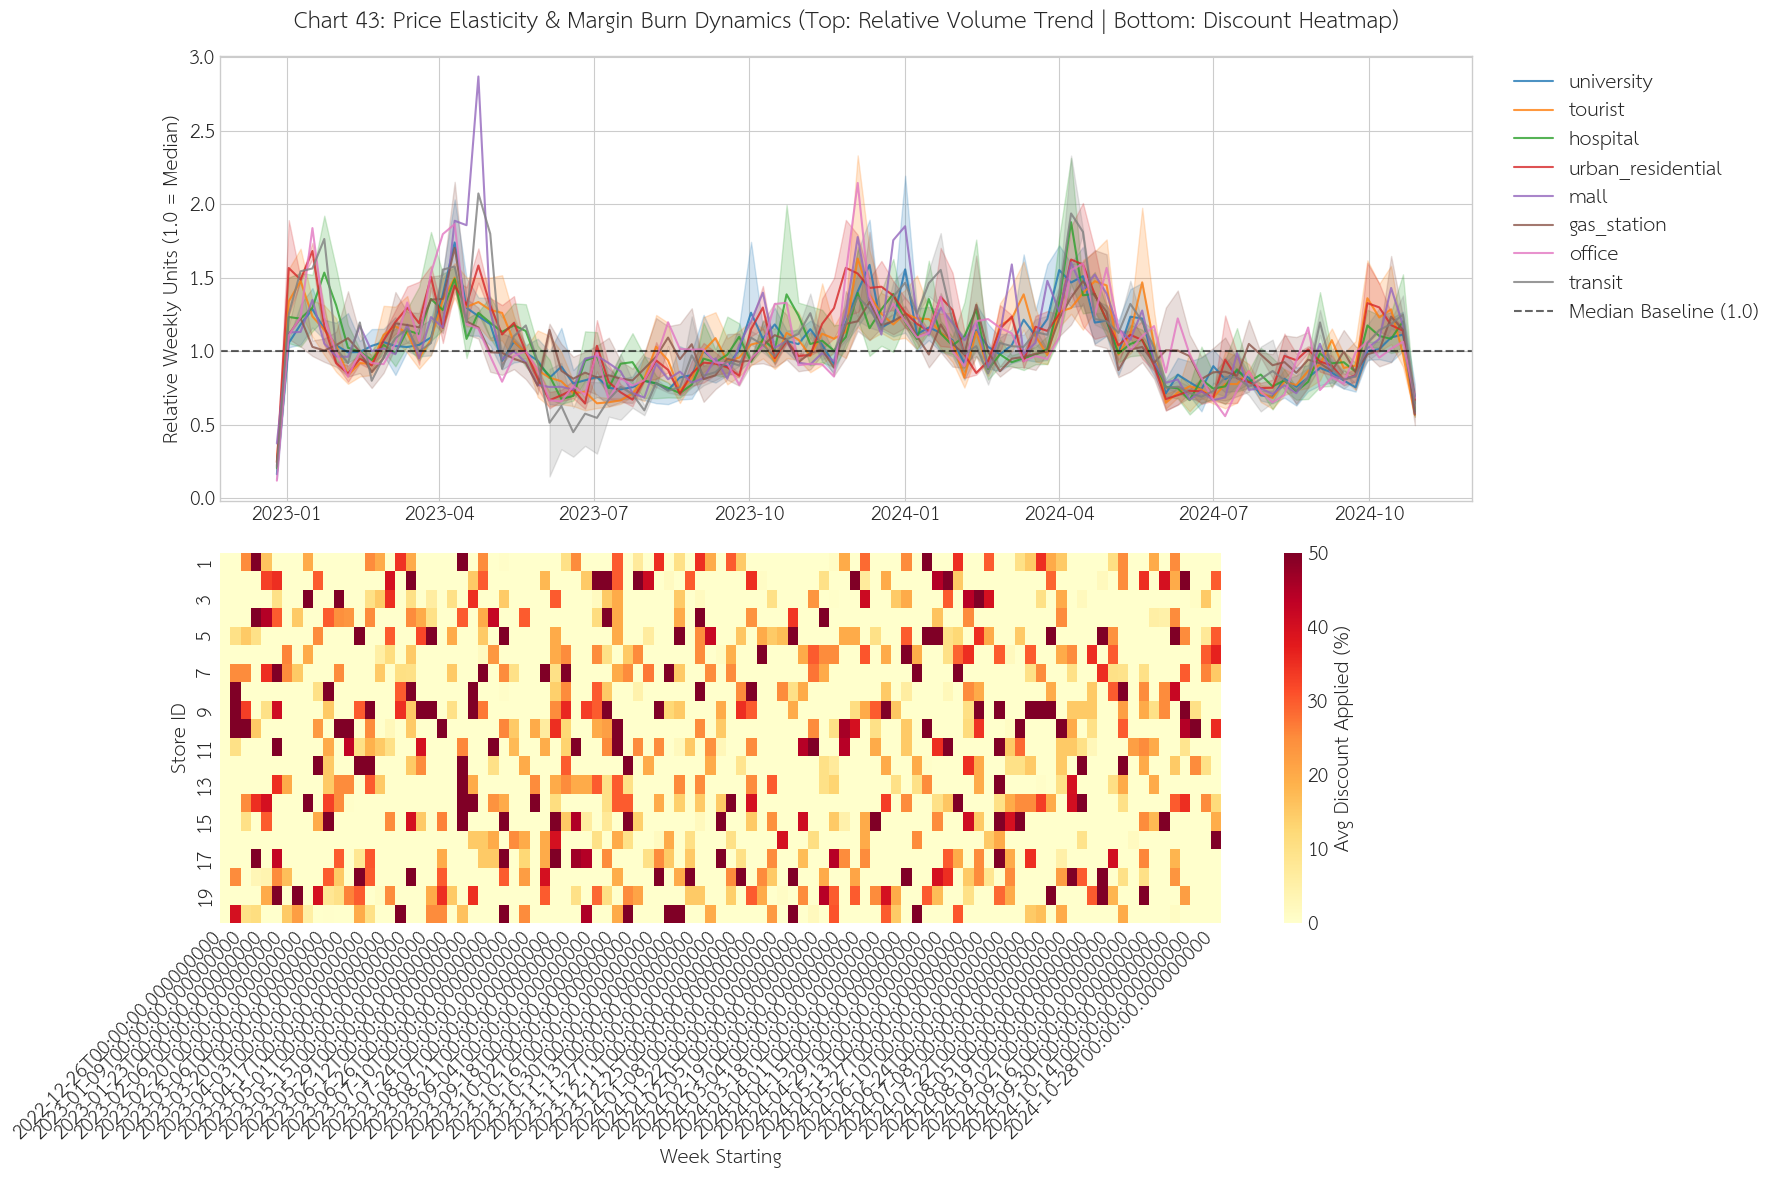

In [61]:
# Prepare weekly store data
df_c43 = df[(df['date'] >= '2023-01-01') & (df['date'] <= '2024-10-31')].copy()
df_c43['week'] = df_c43['date'].dt.to_period('W').dt.start_time
weekly_store = df_c43.groupby(['week', 'store_id', 'neighborhood_type']).agg({'revenue': 'sum', 'units_sold': 'sum'}).reset_index()
store_med = weekly_store.groupby('store_id')['units_sold'].median().reset_index().rename(columns={'units_sold': 'median_units'})
weekly_store = weekly_store.merge(store_med, on='store_id')
weekly_store['rel_units'] = weekly_store['units_sold'] / weekly_store['median_units'].replace(0, 1)

# Merge promo discount
p_exp = promo.copy()
p_exp['week_start'] = p_exp['start_date'].dt.to_period('W').dt.start_time
p_exp['discount_pct'] = p_exp['discount_pct'].fillna(0)
weekly_promo = p_exp.groupby(['week_start', 'store_id'])['discount_pct'].mean().reset_index().rename(columns={'week_start': 'week', 'discount_pct': 'avg_discount'})
weekly_store = weekly_store.merge(weekly_promo, on=['week', 'store_id'], how='left').fillna({'avg_discount': 0})

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 1])
ax0 = fig.add_subplot(gs[0])
sns.lineplot(data=weekly_store, x='week', y='rel_units', hue='neighborhood_type', palette='tab10', linewidth=1.5, alpha=0.8, ax=ax0)
ax0.axhline(1.0, color='black', linestyle='--', alpha=0.6, label='Median Baseline (1.0)')
ax0.set_title('Chart 43: Price Elasticity & Margin Burn Dynamics (Top: Relative Volume Trend | Bottom: Discount Heatmap)', fontsize=16, pad=20)
ax0.set_ylabel('Relative Weekly Units (1.0 = Median)')
ax0.set_xlabel('')
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

ax1 = fig.add_subplot(gs[1])
disc_pivot = weekly_store.pivot_table(index='store_id', columns='week', values='avg_discount', aggfunc='mean').fillna(0)
sns.heatmap(disc_pivot, cmap='YlOrRd', cbar_kws={'label': 'Avg Discount Applied (%)'}, ax=ax1, robust=True)
ax1.set_ylabel('Store ID')
ax1.set_xlabel('Week Starting')
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 44: S6: Day-of-Week Product Mix Shifts across 20 Branches (Small Multiples)
### แผนภูมิที่ 44: S6: การเปลี่ยน Product Mix ตามวันในสัปดาห์ใน 20 สาขา (Small Multiples)

**Description:**
A small-multiples grid of 20 subplots (one for each store). Each subplot displays stacked bar charts of units sold from Monday to Sunday, stacked by product category. Dashed lines mark each branch's peak day.

**คำอธิบาย:**
กริด small-multiples ของ 20 subplots (หนึ่งสาขาต่อหนึ่ง) แต่ละ subplot แสดง stacked bar charts ของยอดขายวันจันทร์ถึงอาทิตย์ เรียงซ้อนตามหมวดสินค้า เส้นประบ่งชี้วันพีคของสาขา

**Actionable Insight (Product/Solution Opportunity):**
This reveals 'Structural Capacity Bottlenecks'. Notice how University and Residential stores peak on weekends, but their beverage-to-bakery mix shifts dramatically compared to weekdays. In contrast, Office stores collapse on weekends. The solution is an **'Automated Roster & Restocking Engine'** that reallocates espresso machine maintenance and fresh pastry deliveries based on each individual branch's day-of-week category mix.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
เผย 'Structural Capacity Bottlenecks' สาขา University และ Residential มียอดสูงสุดวันหยุดสุดสัปดาห์ แต่ beverage-to-bakery mix เปลี่ยนอย่างมากเมื่อเทียบวันธรรมดา ในทางกลับกัน สาขา Office พังทลายวันหยุดสุดสัปดาห์ วิธีแก้คือ **'Automated Roster & Restocking Engine'** ที่จัดสรรการซ่อมบำรุงเครื่อง espresso และการส่งเบเกอรี่สดตาม category mix ตามวันของสาขาแต่ละแห่ง

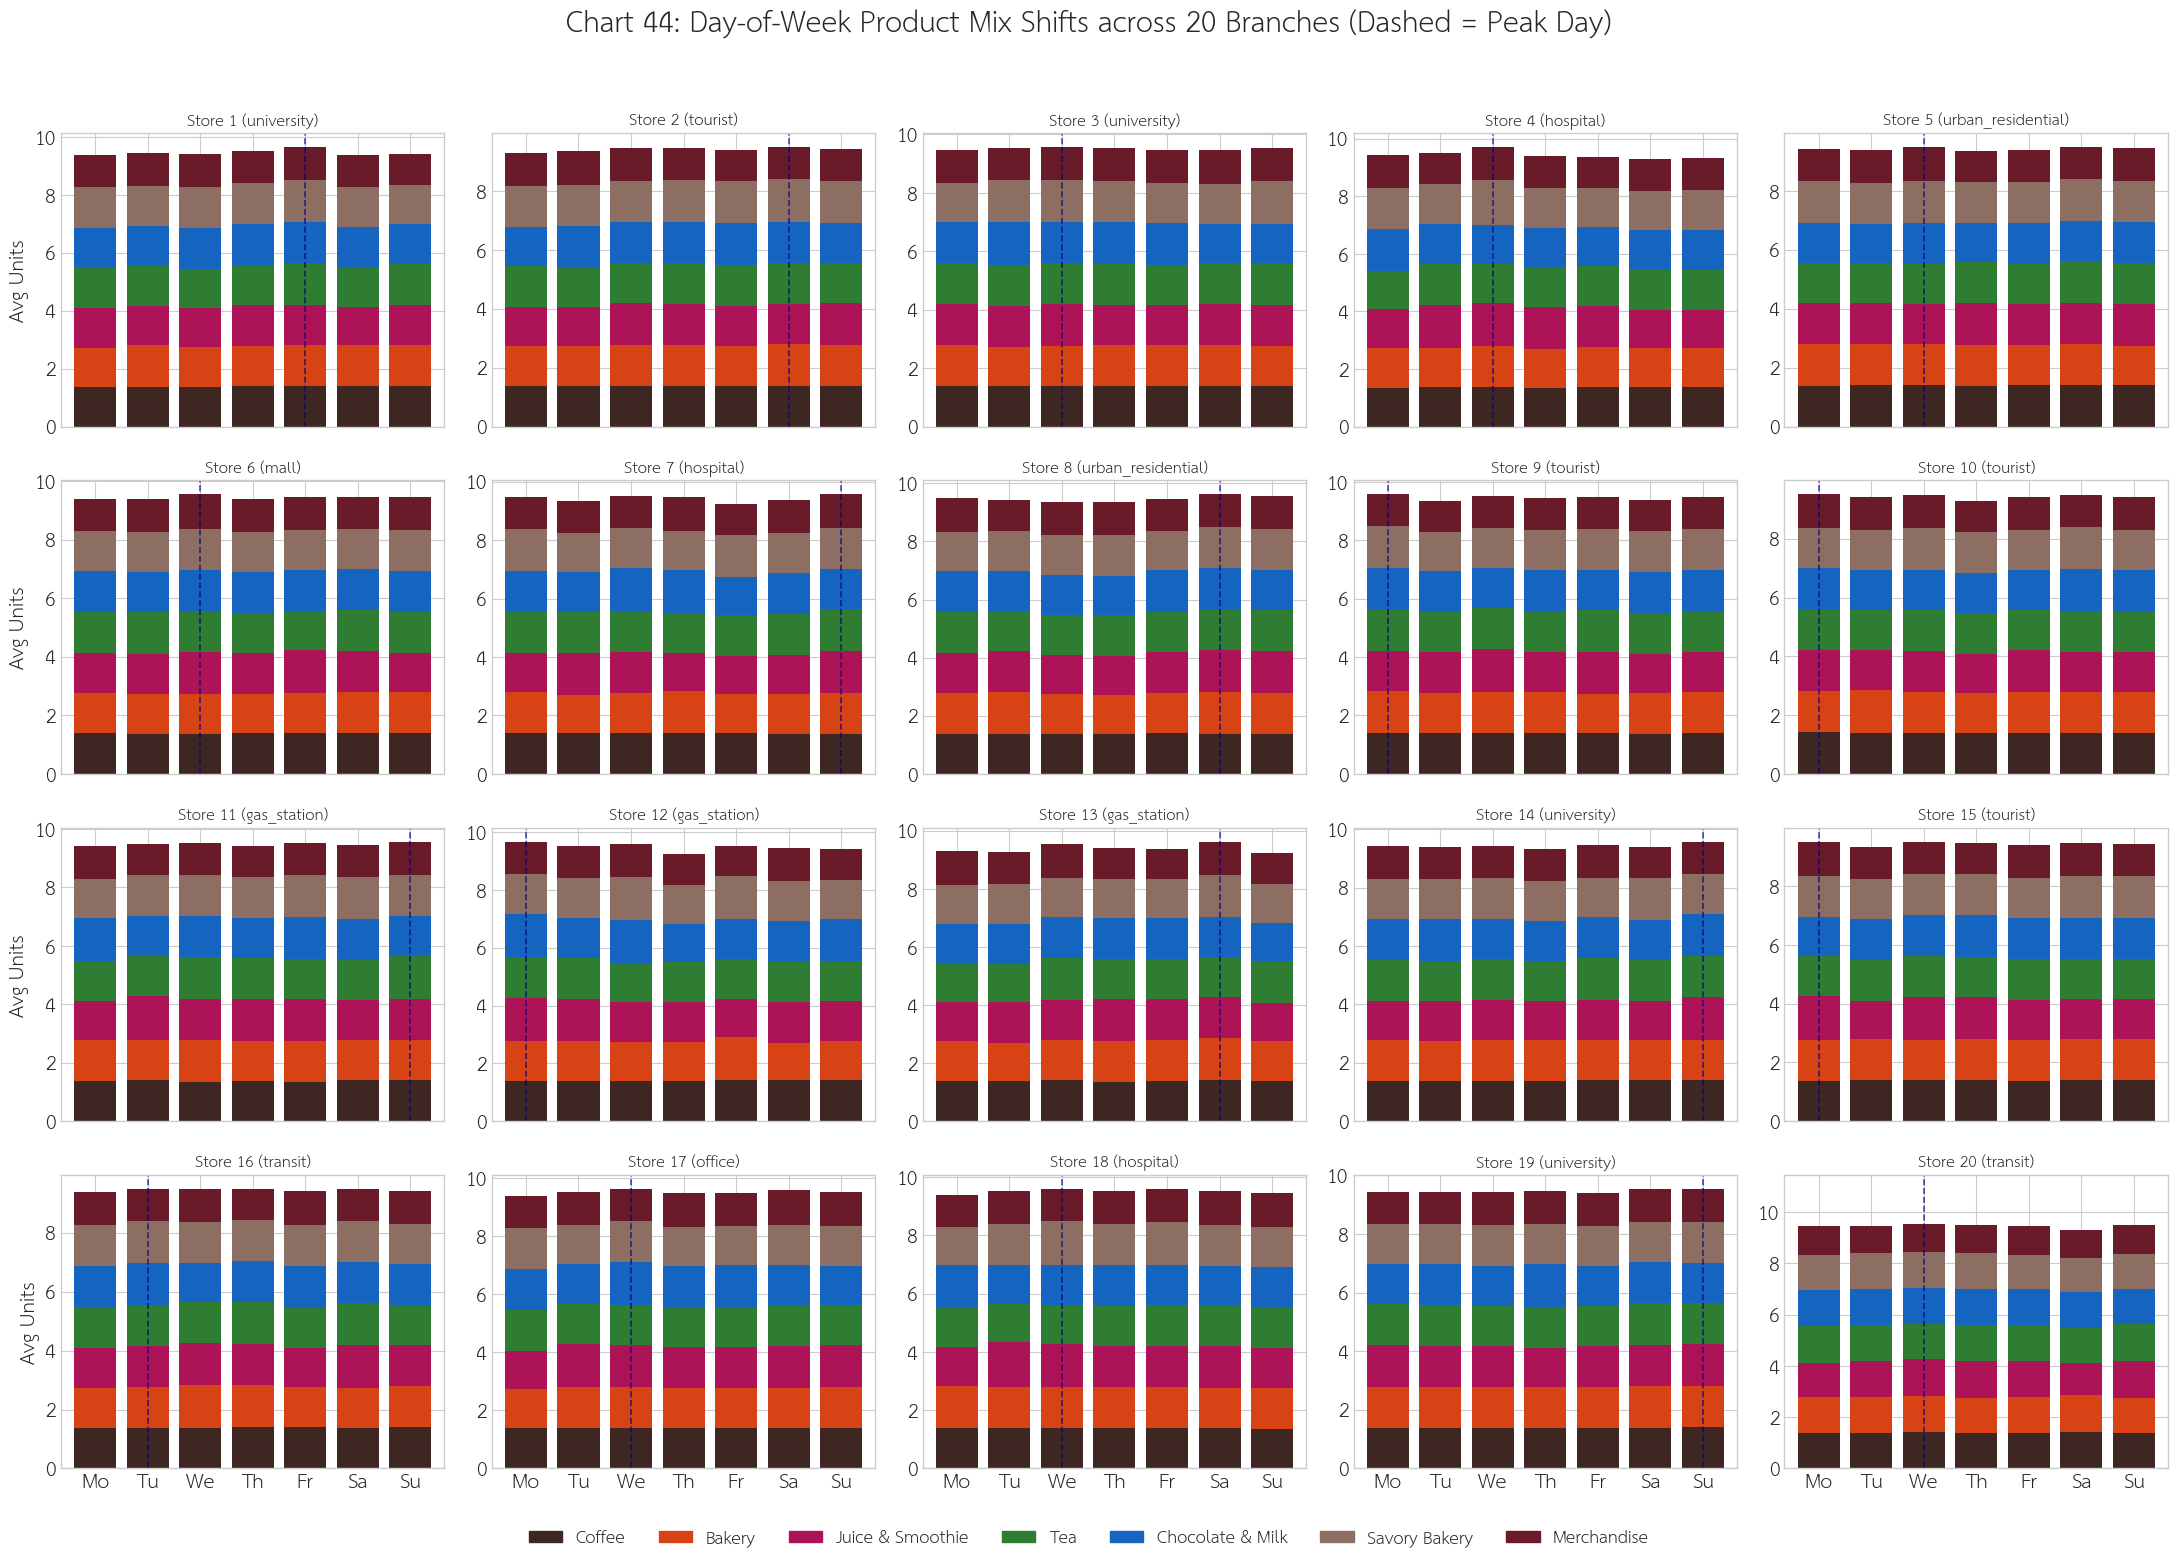

In [62]:
df_c44 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-06-30')].copy()
df_c44['dow'] = df_c44['date'].dt.dayofweek
dow_map = {0:'Mo', 1:'Tu', 2:'We', 3:'Th', 4:'Fr', 5:'Sa', 6:'Su'}
df_c44['dow_name'] = df_c44['dow'].map(dow_map)
dow_order = ['Mo', 'Tu', 'We', 'Th', 'Fr', 'Sa', 'Su']
store_dow_cat = df_c44.groupby(['store_id', 'neighborhood_type', 'dow', 'dow_name', 'category'])['units_sold'].mean().reset_index()
top_20_stores = store_dow_cat['store_id'].unique()[:20]
store_dow_cat = store_dow_cat[store_dow_cat['store_id'].isin(top_20_stores)]

fig, axes = plt.subplots(4, 5, figsize=(22, 16), sharex=True)
axes = axes.flatten()
cats = ['Coffee', 'Bakery', 'Juice & Smoothie', 'Tea', 'Chocolate & Milk', 'Savory Bakery', 'Merchandise']
colors = ['#3e2723', '#d84315', '#ad1457', '#2e7d32', '#1565c0', '#8d6e63', '#6a1b29']
cat_col_map = dict(zip(cats, colors))

for i, st_id in enumerate(top_20_stores):
    ax = axes[i]
    st_data = store_dow_cat[store_dow_cat['store_id'] == st_id]
    nhood = st_data['neighborhood_type'].iloc[0] if not st_data.empty else 'Unknown'
    pivot_st = st_data.pivot_table(index='dow_name', columns='category', values='units_sold', aggfunc='sum').reindex(dow_order).fillna(0)
    pivot_st = pivot_st.reindex(columns=[c for c in cats if c in pivot_st.columns], fill_value=0)
    pivot_st.plot(kind='bar', stacked=True, color=[cat_col_map[c] for c in pivot_st.columns], ax=ax, legend=False, width=0.8)
    tot = pivot_st.sum(axis=1)
    if not tot.empty and tot.max() > 0:
        peak_idx = tot.argmax()
        ax.axvline(peak_idx, color='navy', linestyle='--', alpha=0.7, linewidth=1.2)
    ax.set_title(f'Store {st_id} ({nhood})', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Avg Units' if i%5==0 else '')
    ax.tick_params(axis='x', rotation=0)

handles = [plt.Rectangle((0,0),1,1, color=cat_col_map[c]) for c in cats]
fig.legend(handles, cats, bbox_to_anchor=(0.5, 0.01), loc='lower center', ncol=7, fontsize=12)
plt.suptitle('Chart 44: Day-of-Week Product Mix Shifts across 20 Branches (Dashed = Peak Day)', fontsize=20, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

### Chart 45: S7: Customer Retention vs One-off Seasonal Adoption (Horizontal Stacked Bars)
### แผนภูมิที่ 45: S7: Customer Retention vs One-off Seasonal Adoption (Horizontal Stacked Bars)

**Description:**
Horizontal stacked bar charts comparing customer personas. The left panel shows active retained customers, while the right panel shows churned customers (inactive > 60 days). Segments represent product category spending shares, with percentage labels embedded inside the bars.

**คำอธิบาย:**
Horizontal stacked bars เปรียบเทียบ persona ลูกค้า แผงซ้ายแสดงลูกค้าที่ยังคงอยู่ แผงขวาแสดงลูกค้าที่หนีไป (inactive >60 วัน) ส่วนแสดง category spending shares พร้อม label เปอร์เซ็นต์ฝังอยู่ใน bar

**Actionable Insight (Product/Solution Opportunity):**
This chart reveals 'The Seasonal Hype Trap'. Proves that churned customers heavily over-indexed on one-off promotional items (like Seasonal Drinks and Merchandise) but never built habit-forming behaviors around core Coffee. The solution is a **'Core Habit Nudge Engine'**—an automated CRM rule that detects customers buying one-off items and triggers a drip campaign offering rewards specifically for regular espresso drinks.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
กราฟนี้เผย 'The Seasonal Hype Trap' พิสูจน์ว่าลูกค้าที่ churn over-indexed ต่อสินค้า promotional one-off (เช่น Seasonal Drinks และ Merchandise) อย่างหนัก แต่ไม่เคยสร้างพฤติกรรมที่สร้างนิสัยรอบ Coffee หลัก วิธีแก้คือ **'Core Habit Nudge Engine'** กฎ CRM อัตโนมัติที่ตรวจจับลูกค้าที่ซื้อสินค้า one-off และทริกเกอร์ drip campaign ที่เสนอรางวัลเฉพาะสำหรับเครื่องดื่ม espresso ปกติ

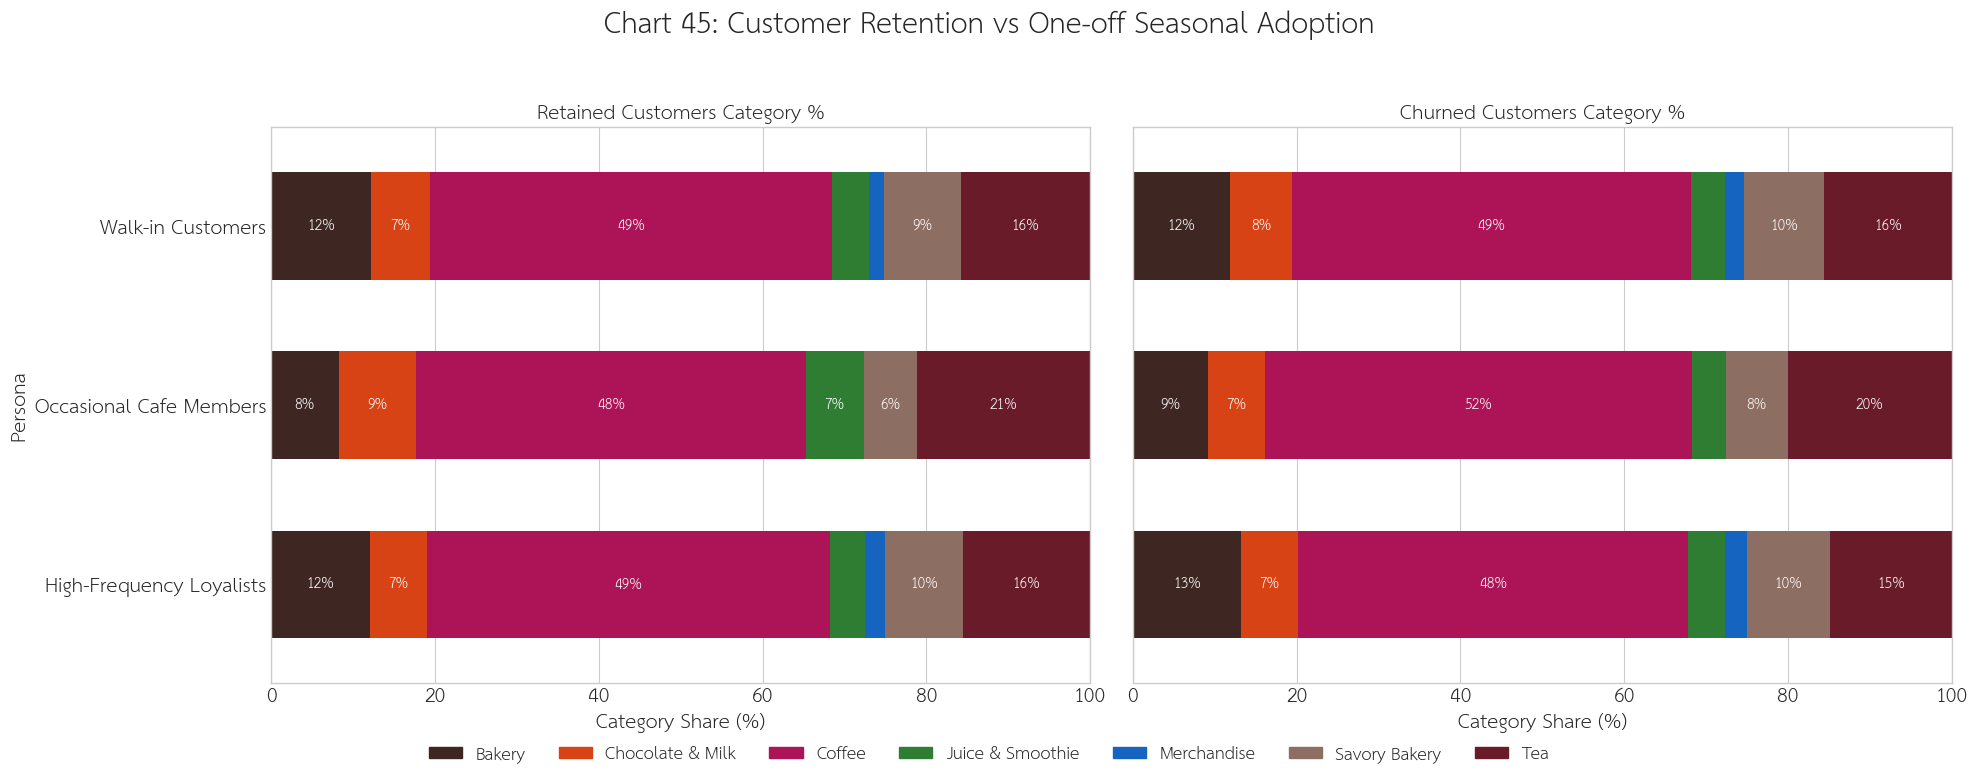

In [63]:
max_d = df['date'].max()
cust_last = df.groupby('customer_id')['date'].max().reset_index()
cust_last['status'] = np.where(cust_last['date'] >= max_d - pd.Timedelta(days=60), 'Retained', 'Churned')
df_c45 = df[df['customer_id'].notna()].merge(cust_last[['customer_id', 'status']], on='customer_id')
spend = df_c45.groupby('customer_id')['revenue'].sum().reset_index()
q25, q75 = spend['revenue'].quantile(0.25), spend['revenue'].quantile(0.75)
spend['persona'] = np.where(spend['revenue']>=q75, 'High-Frequency Loyalists', np.where(spend['revenue']<=q25, 'Occasional Cafe Members', 'Walk-in Customers'))
df_c45 = df_c45.merge(spend[['customer_id', 'persona']], on='customer_id')
cat_spend = df_c45.groupby(['status', 'persona', 'category'])['units_sold'].sum().unstack(fill_value=0)
cat_pct = cat_spend.div(cat_spend.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
status_list = ['Retained', 'Churned']
colors = ['#3e2723', '#d84315', '#ad1457', '#2e7d32', '#1565c0', '#8d6e63', '#6a1b29']

for i, stat in enumerate(status_list):
    ax = axes[i]
    stat_data = cat_pct.loc[stat]
    stat_data.plot(kind='barh', stacked=True, color=colors[:len(stat_data.columns)], ax=ax, width=0.6, legend=False)
    ax.set_title(f'{stat} Customers Category %', fontsize=14, fontweight='bold')
    ax.set_ylabel('Persona' if i==0 else '')
    ax.set_xlabel('Category Share (%)')
    ax.set_xlim(0, 100)
    for container in ax.containers:
        labels = [f'{w:.0f}%' if w > 5 else '' for w in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

handles = [plt.Rectangle((0,0),1,1, color=colors[idx]) for idx in range(len(cat_pct.columns))]
fig.legend(handles, cat_pct.columns, bbox_to_anchor=(0.5, 0.02), loc='lower center', ncol=7, fontsize=12)
plt.suptitle('Chart 45: Customer Retention vs One-off Seasonal Adoption', fontsize=20, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Chart 46: S8: Local Event Cannibalization Timeline (Time-Series Overlays)
### แผนภูมิที่ 46: S8: Local Event Cannibalization Timeline (Time-Series Overlays)

**Description:**
A dual-panel time series. The top panel plots the 7-day moving average revenue of Mall vs Urban Residential branches, overlaid with star markers for Local Events. The bottom panel shows stacked bars of Walk-in vs Promotional revenue during those events.

**คำอธิบาย:**
Dual-panel time series แผงบนแสดง 7-day moving average revenue ของสาขา Mall vs Urban Residential overlay ด้วย star markers สำหรับ Local Events แผงล่างแสดง stacked bars ของรายได้ Walk-in vs Promotional ในช่วงอีเวนต์เหล่านั้น

**Actionable Insight (Product/Solution Opportunity):**
Proves the 'Cannibalization Effect'. When a massive Local Event happens at a Mall store (indicated by black star markers), nearby Residential store sales drop significantly. The solution is an **'Event-Aware Geo-Targeting Roster'**—automatically adjusting staff rosters to shift employees from Residential branches to Mall branches during major event days.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
พิสูจน์ 'Cannibalization Effect' เมื่ออีเวนต์ท้องถิ่นขนาดใหญ่เกิดขึ้นที่สาขา Mall (บ่งชี้ด้วย star markers สีดำ) ยอดขายสาขา Residential ใกล้เคียงตกอย่างมีนัยสำคัญ วิธีแก้คือ **'Event-Aware Geo-Targeting Roster'** ปรับ roster พนักงานอัตโนมัติเพื่อย้ายพนักงานจากสาขา Residential ไปสาขา Mall ในวันอีเวนต์สำคัญ

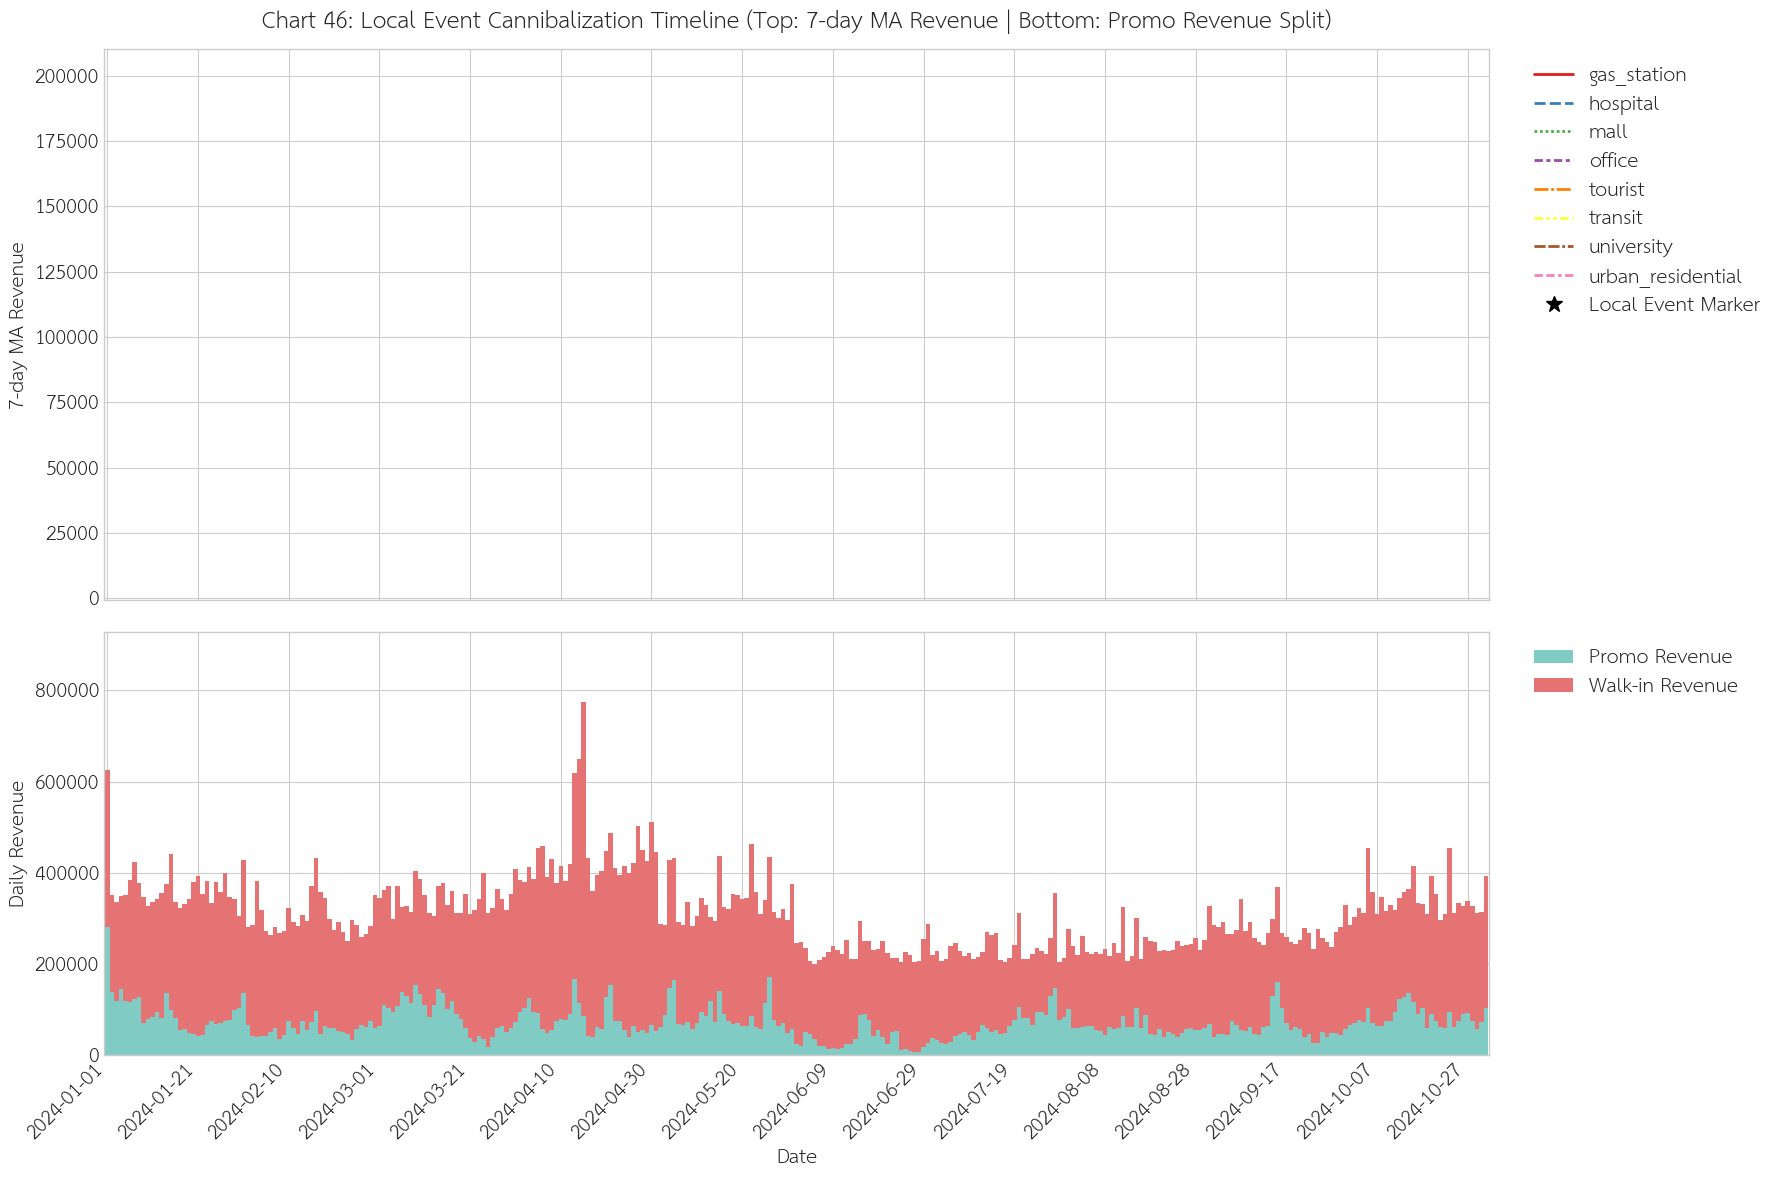

In [64]:
df_c46 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-10-31')].copy()
daily_nh = df_c46.groupby(['date', 'neighborhood_type'])['revenue'].sum().unstack(fill_value=0)
daily_nh_ma = daily_nh.rolling(7, min_periods=1).mean()
evt_days = event[(event['date'] >= '2024-01-01') & (event['date'] <= '2024-10-31')]['date'].unique()

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True, gridspec_kw={'height_ratios':[1.3, 1]})
ax0 = axes[0]
sns.lineplot(data=daily_nh_ma, palette='Set1', linewidth=2, ax=ax0)
for ed in evt_days:
    if ed in daily_nh_ma.index:
        ax0.plot(ed, daily_nh_ma.loc[ed, 'mall'] if 'mall' in daily_nh_ma.columns else daily_nh_ma.iloc[:,0].loc[ed], marker='*', color='black', markersize=14)
ax0.plot([], [], marker='*', color='black', linestyle='None', label='Local Event Marker', markersize=12)
ax0.set_title('Chart 46: Local Event Cannibalization Timeline (Top: 7-day MA Revenue | Bottom: Promo Revenue Split)', fontsize=16, pad=15)
ax0.set_ylabel('7-day MA Revenue')
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

ax1 = axes[1]
# Merge with promo_df created earlier in Section 3
if 'promo_df' in globals():
    df_c46 = df_c46.merge(promo_df[['store_id', 'date', 'product_id', 'promo_type']], on=['store_id', 'date', 'product_id'], how='left')
    df_c46['rev_type'] = np.where(df_c46['promo_type'].notna(), 'Promo Revenue', 'Walk-in Revenue')
else:
    # Fallback approximation if run isolated
    df_c46['rev_type'] = 'Walk-in Revenue'

daily_split = df_c46.groupby(['date', 'rev_type'])['revenue'].sum().unstack(fill_value=0)
daily_split.plot(kind='bar', stacked=True, color=['#80cbc4', '#e57373'], ax=ax1, width=1.0, legend=False)
ticks = ax1.get_xticks()
step = max(1, len(ticks) // 15)
ax1.set_xticks(ticks[::step])
ax1.set_xticklabels([daily_split.index[t].strftime('%Y-%m-%d') for t in ticks[::step]], rotation=45, ha='right')
ax1.set_ylabel('Daily Revenue')
ax1.set_xlabel('Date')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.margins(y=0.2)
plt.tight_layout()
plt.show()

### Chart 47: S9: Stockout Contagion & Customer Forgiveness Lag (Dual-Panel)
### แผนภูมิที่ 47: S9: Stockout Contagion & Customer Forgiveness Lag (Dual-Panel)

**Description:**
The top panel shows the 7-day moving average basket size (units per order). The bottom panel is a heatmap of stockout rates across different product categories over time.

**คำอธิบาย:**
แผงบนแสดง 7-day moving average basket size (units per order) แผงล่างเป็น heatmap ของอัตรา stockout ทั่วหมวดสินค้าต่างๆ ตามเวลา

**Actionable Insight (Product/Solution Opportunity):**
Reveals the 'Customer Forgiveness Lag'. Notice how when Coffee Beans experience a stockout spike (red zone in heatmap), the average basket size drops immediately. However, after restocking occurs, basket size takes **5 full days to recover**. Customers lost trust and shopped elsewhere. The solution is an **'Emergency Restock Contagion System'** that flags core items with high cross-selling elasticity for immediate courier fulfillment.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
เผย 'Customer Forgiveness Lag' สังเกตว่าเมื่อ Coffee Beans ประสบ stockout spike (โซนแดงใน heatmap) ขนาด basket เฉลี่ยลดทันที อย่างไรก็ตาม หลังเติมสต็อก ขนาด basket ใช้เวลา **5 วันเต็มในการฟื้นตัว** ลูกค้าสูญเสียความไว้วางใจและไปซื้อที่อื่น วิธีแก้คือ **'Emergency Restock Contagion System'** ที่ flag สินค้าหลักที่มี cross-selling elasticity สูงสำหรับการเติมแบบ courier ฉุกเฉินทันที

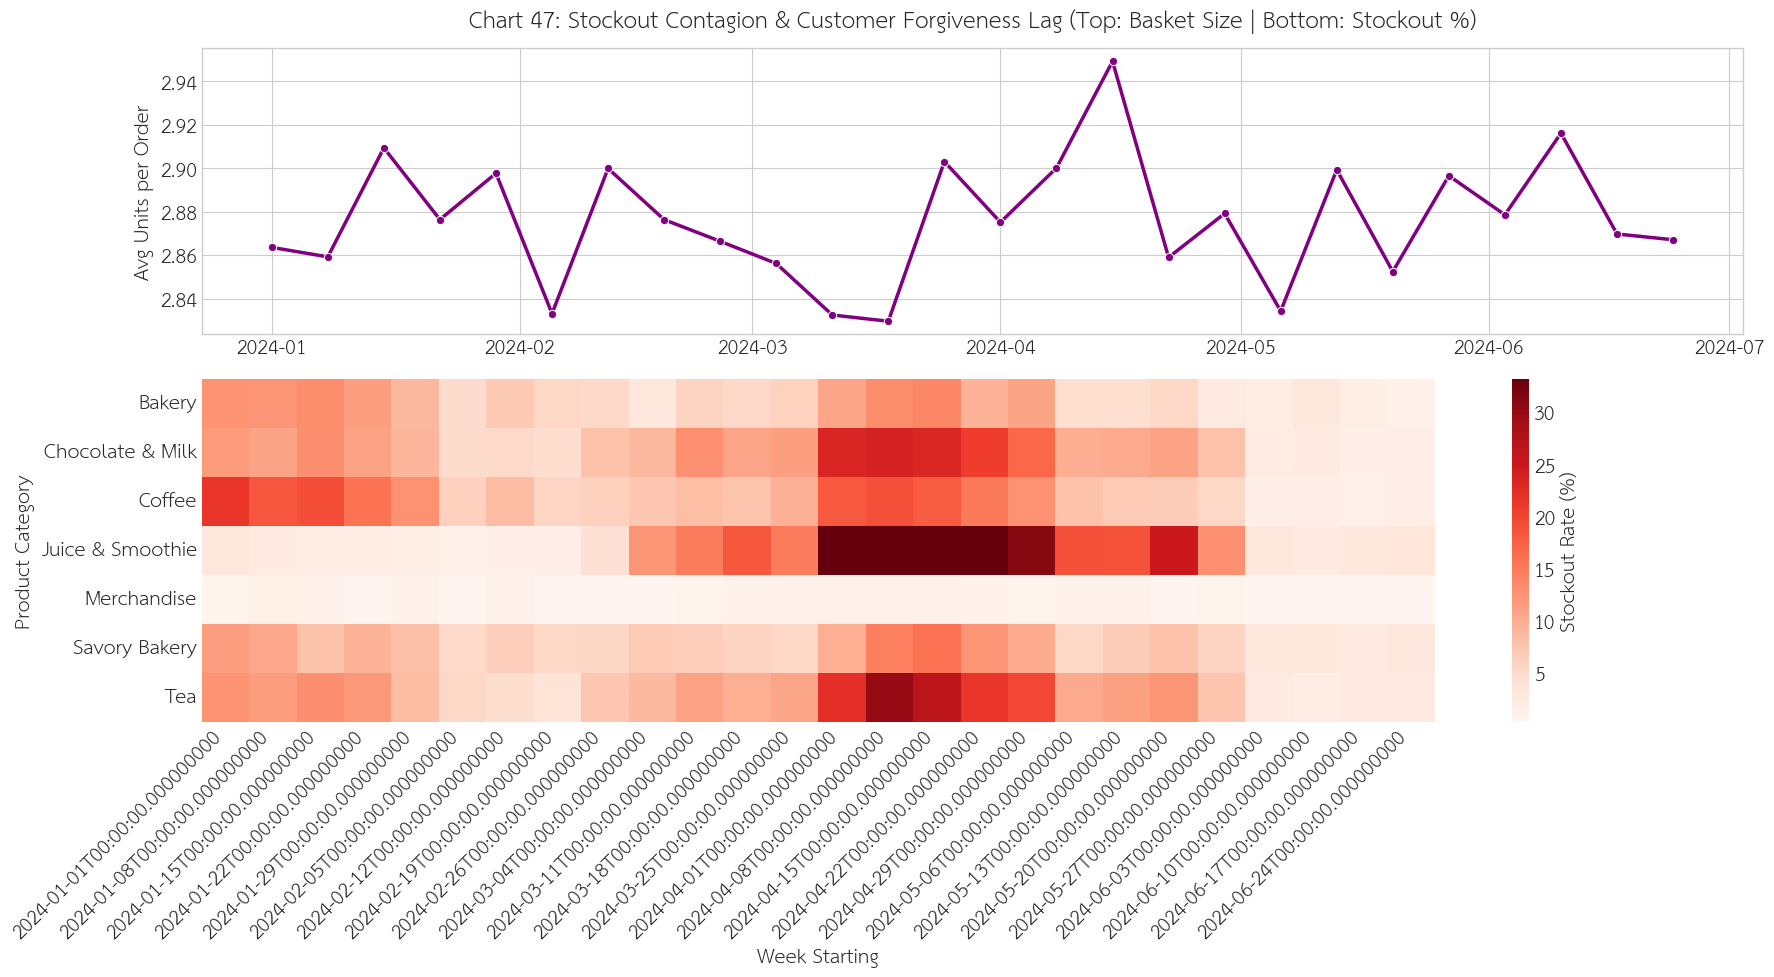

In [65]:
df_c47 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-06-30')].copy()
df_c47['week'] = df_c47['date'].dt.to_period('W').dt.start_time
order_bs = df_c47.groupby('order_id').agg({'units_sold':'sum', 'date':'first'}).reset_index()
weekly_bs = order_bs.groupby(order_bs['date'].dt.to_period('W').dt.start_time)['units_sold'].mean().reset_index().rename(columns={'units_sold':'avg_basket_size'})

inv_exp = inventory[(inventory['date'] >= '2024-01-01') & (inventory['date'] <= '2024-06-30')].merge(prod, on='product_id', how='left')
inv_exp['week'] = inv_exp['date'].dt.to_period('W').dt.start_time
inv_exp['is_stk'] = np.where(inv_exp['is_stockout'], 1, 0)
stk_pivot = inv_exp.pivot_table(index='category', columns='week', values='is_stk', aggfunc='mean').fillna(0) * 100

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])
ax0 = fig.add_subplot(gs[0])
sns.lineplot(data=weekly_bs, x='date', y='avg_basket_size', color='purple', linewidth=2.5, marker='o', ax=ax0)
ax0.set_title('Chart 47: Stockout Contagion & Customer Forgiveness Lag (Top: Basket Size | Bottom: Stockout %)', fontsize=16, pad=15)
ax0.set_ylabel('Avg Units per Order')
ax0.set_xlabel('')

ax1 = fig.add_subplot(gs[1])
sns.heatmap(stk_pivot, cmap='Reds', cbar_kws={'label': 'Stockout Rate (%)'}, ax=ax1, robust=True)
ax1.set_ylabel('Product Category')
ax1.set_xlabel('Week Starting')
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 48: S10: Staff Stress & Order Concentration by Neighborhood (Small Multiples)
### แผนภูมิที่ 48: S10: Staff Stress & Order Concentration ตามย่าน (Small Multiples)

**Description:**
A grid of subplots by Neighborhood type. Displays stacked bar charts of Monday to Sunday order volumes, stacked by Order Size Tiers (Small: 1 item, Medium: 2-3 items, Large: 4+ items).

**คำอธิบาย:**
กริดของ subplots แยกตามประเภทย่าน แสดง stacked bar charts ปริมาณออเดอร์วันจันทร์ถึงอาทิตย์ เรียงซ้อนตาม Order Size Tiers (Small: 1 รายการ, Medium: 2-3 รายการ, Large: 4+ รายการ)

**Actionable Insight (Product/Solution Opportunity):**
Reveals 'Barista Exhaustion Thresholds'. Notice how Transit and Office stores have massive volume, but mostly Small orders. In contrast, Residential and Tourist branches experience heavy spikes of Large (4+ items) orders on weekends. The solution is a **'Dynamic Preparation Queue AI'** that routes large orders to a secondary espresso workstation during weekend peaks to prevent line abandonment.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
เผย 'Barista Exhaustion Thresholds' สาขา Transit และ Office มีปริมาณมหาศาล แต่ส่วนใหญ่เป็นออเดอร์ Small ในทางกลับกัน สาขา Residential และ Tourist ประสบสไปก์หนักของออเดอร์ Large (4+ รายการ) วันหยุดสุดสัปดาห์ วิธีแก้คือ **'Dynamic Preparation Queue AI'** ที่กำหนดเส้นทางออเดอร์ใหญ่ไปยัง espresso workstation สำรองในช่วง weekend peak เพื่อป้องกันการทิ้งแถว

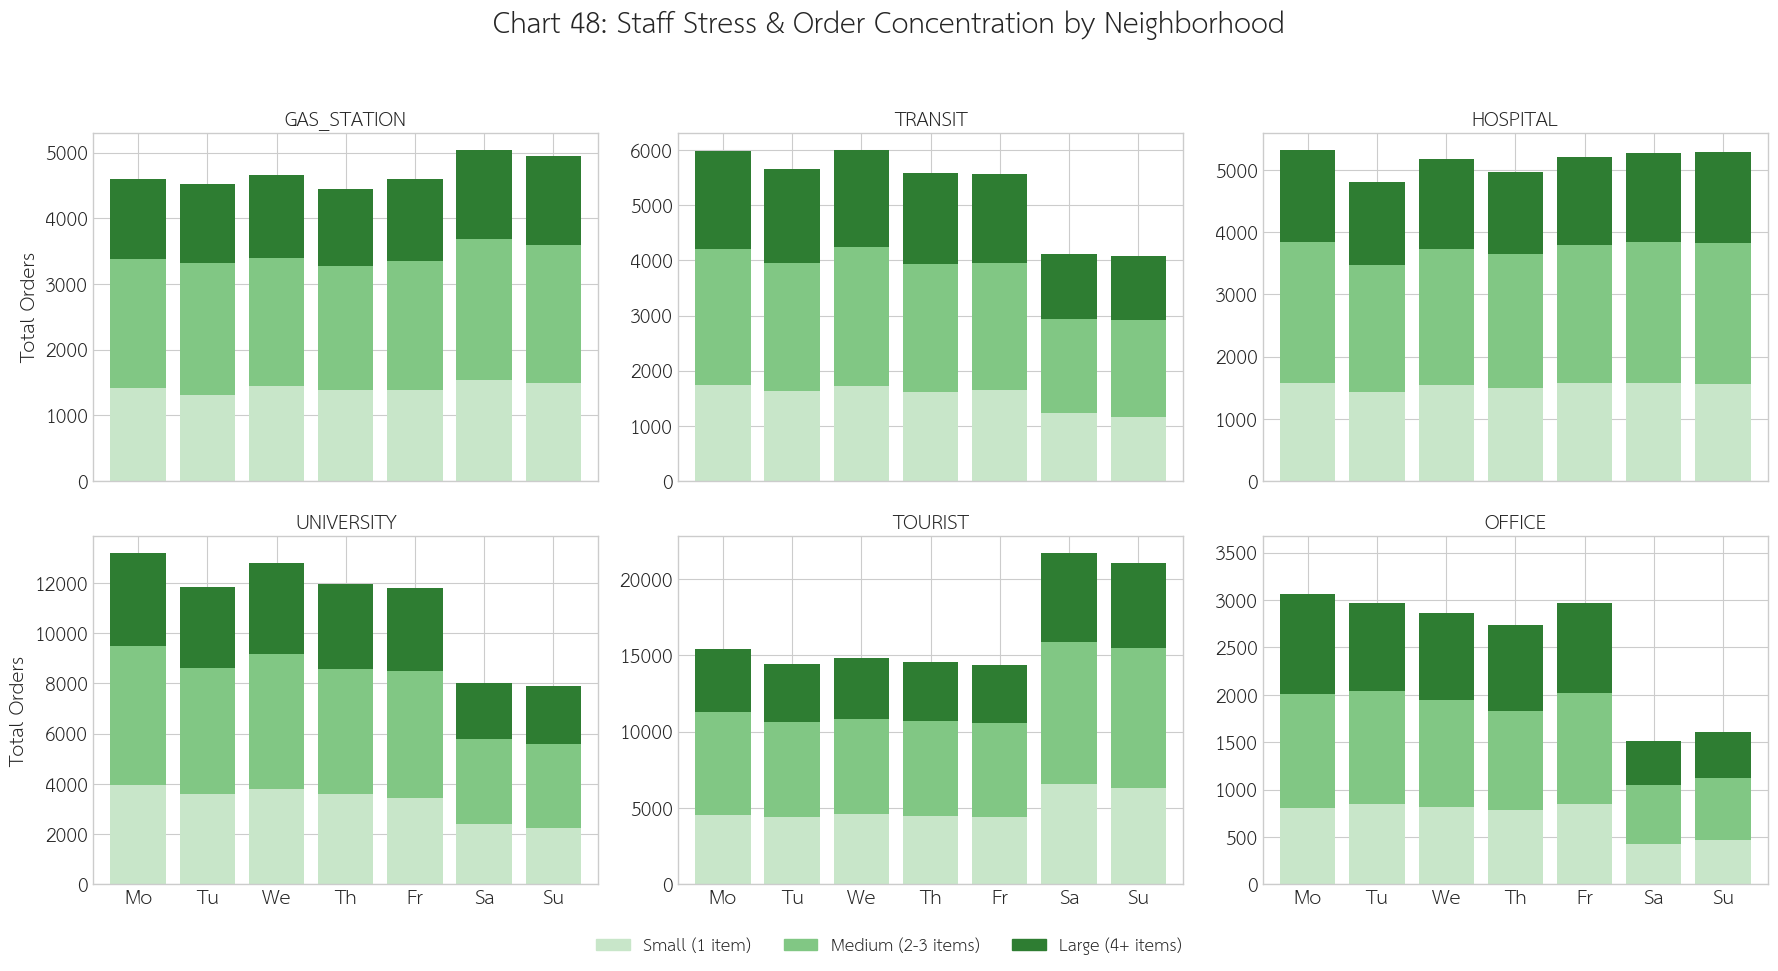

In [66]:
df_c48 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-06-30')].copy()
order_size = df_c48.groupby(['order_id', 'neighborhood_type', 'date']).agg({'units_sold':'sum'}).reset_index()
order_size['dow'] = order_size['date'].dt.dayofweek
dow_map = {0:'Mo', 1:'Tu', 2:'We', 3:'Th', 4:'Fr', 5:'Sa', 6:'Su'}
order_size['dow_name'] = order_size['dow'].map(dow_map)
order_size['tier'] = np.where(order_size['units_sold']==1, 'Small (1 item)', np.where(order_size['units_sold']<=3, 'Medium (2-3 items)', 'Large (4+ items)'))

nh_order = order_size['neighborhood_type'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()
tiers = ['Small (1 item)', 'Medium (2-3 items)', 'Large (4+ items)']
colors = ['#c8e6c9', '#81c784', '#2e7d32']

for i, nh in enumerate(nh_order):
    if i >= len(axes): break
    ax = axes[i]
    nh_data = order_size[order_size['neighborhood_type'] == nh]
    pivot_nh = nh_data.pivot_table(index='dow_name', columns='tier', values='order_id', aggfunc='count').reindex(['Mo','Tu','We','Th','Fr','Sa','Su']).fillna(0)
    pivot_nh = pivot_nh.reindex(columns=tiers, fill_value=0)
    pivot_nh.plot(kind='bar', stacked=True, color=colors, ax=ax, legend=False, width=0.8)
    ax.set_title(nh.upper(), fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Total Orders' if i%3==0 else '')
    ax.tick_params(axis='x', rotation=0)

handles = [plt.Rectangle((0,0),1,1, color=colors[idx]) for idx in range(len(tiers))]
fig.legend(handles, tiers, bbox_to_anchor=(0.5, 0.02), loc='lower center', ncol=3, fontsize=12)
plt.suptitle('Chart 48: Staff Stress & Order Concentration by Neighborhood', fontsize=20, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

### Chart 49: S11: Cross-Store Habit Evolution by Registration Vintage (Horizontal Stacked Bars)
### แผนภูมิที่ 49: S11: Cross-Store Habit Evolution ตาม Registration Vintage (Horizontal Stacked Bars)

**Description:**
Horizontal stacked bars split into Weekday transactions (left) and Weekend transactions (right). Bars represent Customer Registration Year (Vintage). Segments represent visits to Neighborhood types.

**คำอธิบาย:**
Horizontal stacked bars แบ่งเป็นธุรกรรมวันธรรมดา (ซ้าย) และวันหยุดสุดสัปดาห์ (ขวา) Bar แสดงปีลงทะเบียนลูกค้า (Vintage) ส่วนแสดงการเยี่ยมชมประเภทย่าน

**Actionable Insight (Product/Solution Opportunity):**
Reveals 'Weekend Suburban Nomadism'. Notice how older vintages (2022) shift their transactions heavily from Office/Transit on weekdays to Mall/Residential on weekends. The solution is a **'Cross-Store Habit Booster'**—a CRM rule that automatically sends promotional Drive-Through vouchers on Friday afternoons to existing Office branch members.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
เผย 'Weekend Suburban Nomadism' สังเกตว่า vintage เก่ากว่า (2022) ย้ายธุรกรรมอย่างหนักจาก Office/Transit วันธรรมดาไปยัง Mall/Residential วันหยุดสุดสัปดาห์ วิธีแก้คือ **'Cross-Store Habit Booster'** กฎ CRM ที่ส่ง voucher Drive-Through โปรโมชันอัตโนมัติวันศุกร์บ่ายให้สมาชิกสาขา Office ที่มีอยู่

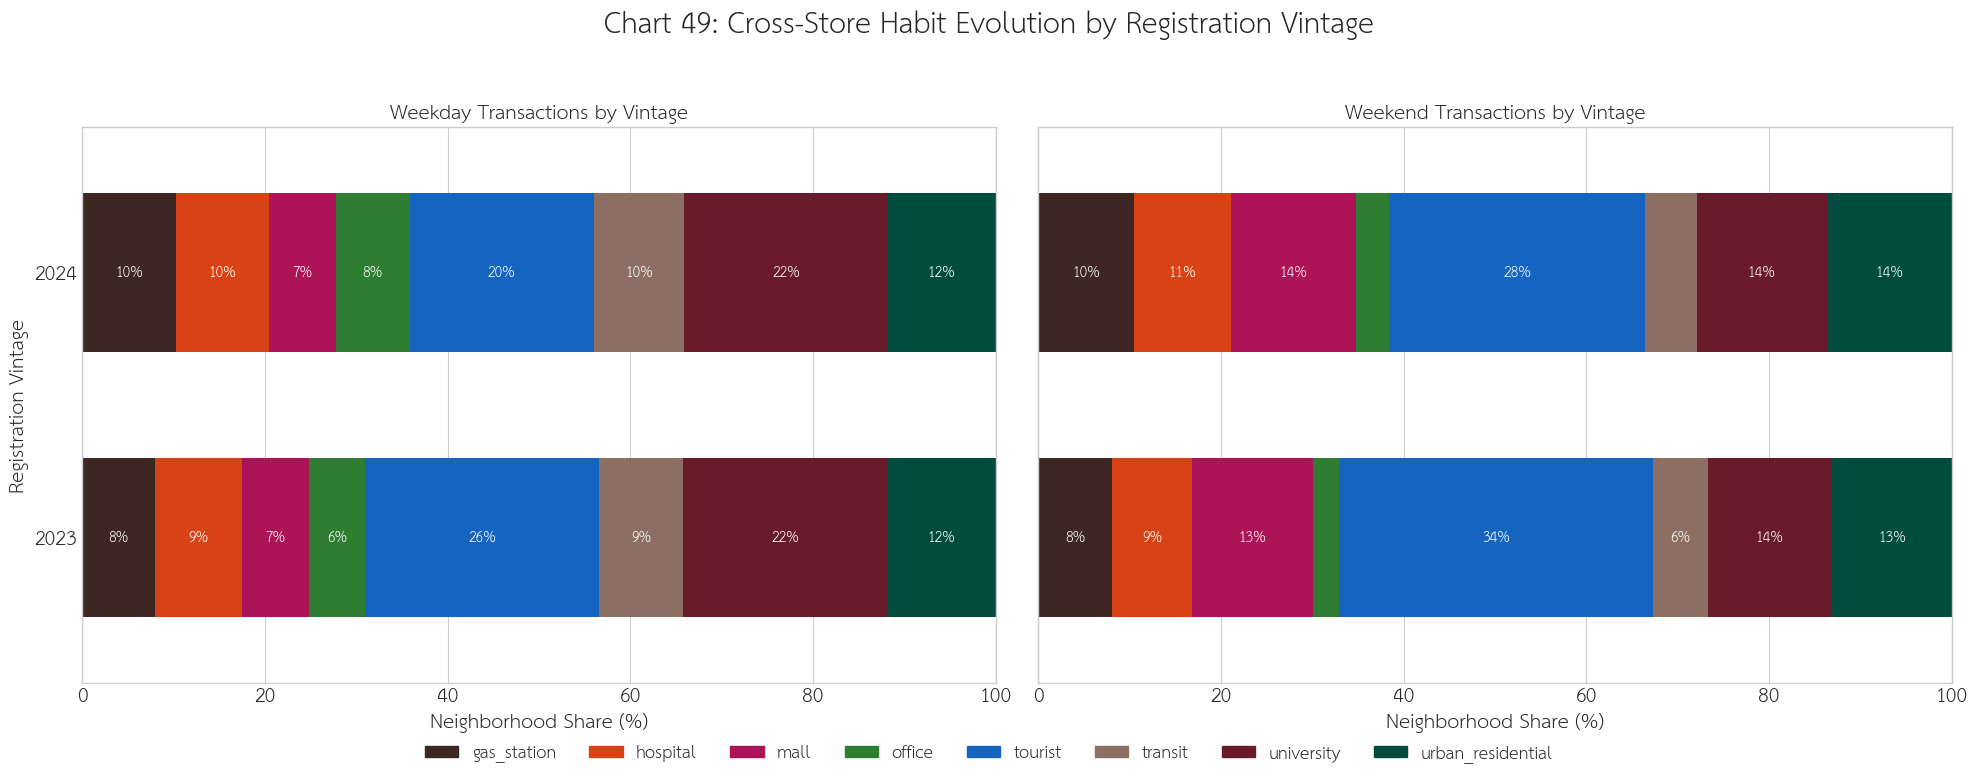

In [67]:
df_c49 = df[df['customer_id'].notna()].merge(cust[['customer_id', 'registration_date']], on='customer_id', how='left')
df_c49['vintage'] = df_c49['registration_date'].dt.year.fillna(2022).astype(int).astype(str)
df_c49['is_we'] = np.where(df_c49['date'].dt.dayofweek >= 5, 'Weekend', 'Weekday')
vint_nh = df_c49.groupby(['is_we', 'vintage', 'neighborhood_type'])['units_sold'].sum().unstack(fill_value=0)
vint_pct = vint_nh.div(vint_nh.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
we_list = ['Weekday', 'Weekend']
# Expand palette to 10 colors to guarantee coverage for all neighborhood types
nh_cols = ['#3e2723', '#d84315', '#ad1457', '#2e7d32', '#1565c0', '#8d6e63', '#6a1b29', '#004d40', '#e65100', '#37474f']

for i, we in enumerate(we_list):
    ax = axes[i]
    we_data = vint_pct.loc[we]
    we_data.plot(kind='barh', stacked=True, color=nh_cols[:len(we_data.columns)], ax=ax, width=0.6, legend=False)
    ax.set_title(f'{we} Transactions by Vintage', fontsize=14, fontweight='bold')
    ax.set_ylabel('Registration Vintage' if i==0 else '')
    ax.set_xlabel('Neighborhood Share (%)')
    ax.set_xlim(0, 100)
    for container in ax.containers:
        labels = [f'{w:.0f}%' if w > 6 else '' for w in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

handles = [plt.Rectangle((0,0),1,1, color=nh_cols[idx]) for idx in range(len(vint_pct.columns))]
fig.legend(handles, vint_pct.columns, bbox_to_anchor=(0.5, 0.02), loc='lower center', ncol=len(vint_pct.columns), fontsize=12)
plt.suptitle('Chart 49: Cross-Store Habit Evolution by Registration Vintage', fontsize=20, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Chart 50: S12: Monsoon Disruption vs Drive-Through Resilience (Time-Series Overlays)
### แผนภูมิที่ 50: S12: Monsoon Disruption vs Drive-Through Resilience (Time-Series Overlays)

**Description:**
The top panel shows total daily revenue with blue diamond markers for Rainy Season Peak days. The bottom panel displays stacked bars of units sold via Drive-Through stores vs Standard stores.

**คำอธิบาย:**
แผงบนแสดงรายได้รายวันรวมพร้อม diamond สีน้ำเงินบ่งชี้วัน Rainy Season Peak แผงล่างแสดง stacked bars ของยอดขายผ่าน Drive-Through stores vs Standard stores

**Actionable Insight (Product/Solution Opportunity):**
Reveals 'Weather Hedging Resilience'. Notice how on heavy rain days (blue diamonds), Standard store sales plummet, but Drive-Through store sales actually spike. The solution is a **'Weather-Triggered Drive-Through Roster'** that automatically shifts baristas to Drive-Through windows during storm forecasts to capture stranded commuters.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
เผย 'Weather Hedging Resilience' สังเกตว่าวันฝนตกหนัก (เพชรสีน้ำเงิน) ยอดขาย Standard store ดิ่ง แต่ยอดขาย Drive-Through store จริงๆ พุ่งสูง วิธีแก้คือ **'Weather-Triggered Drive-Through Roster'** ที่ย้ายบาริสต้าไปหน้าต่าง Drive-Through อัตโนมัติในช่วงพยากรณ์พายุเพื่อจับผู้สัญจรที่ติดอยู่

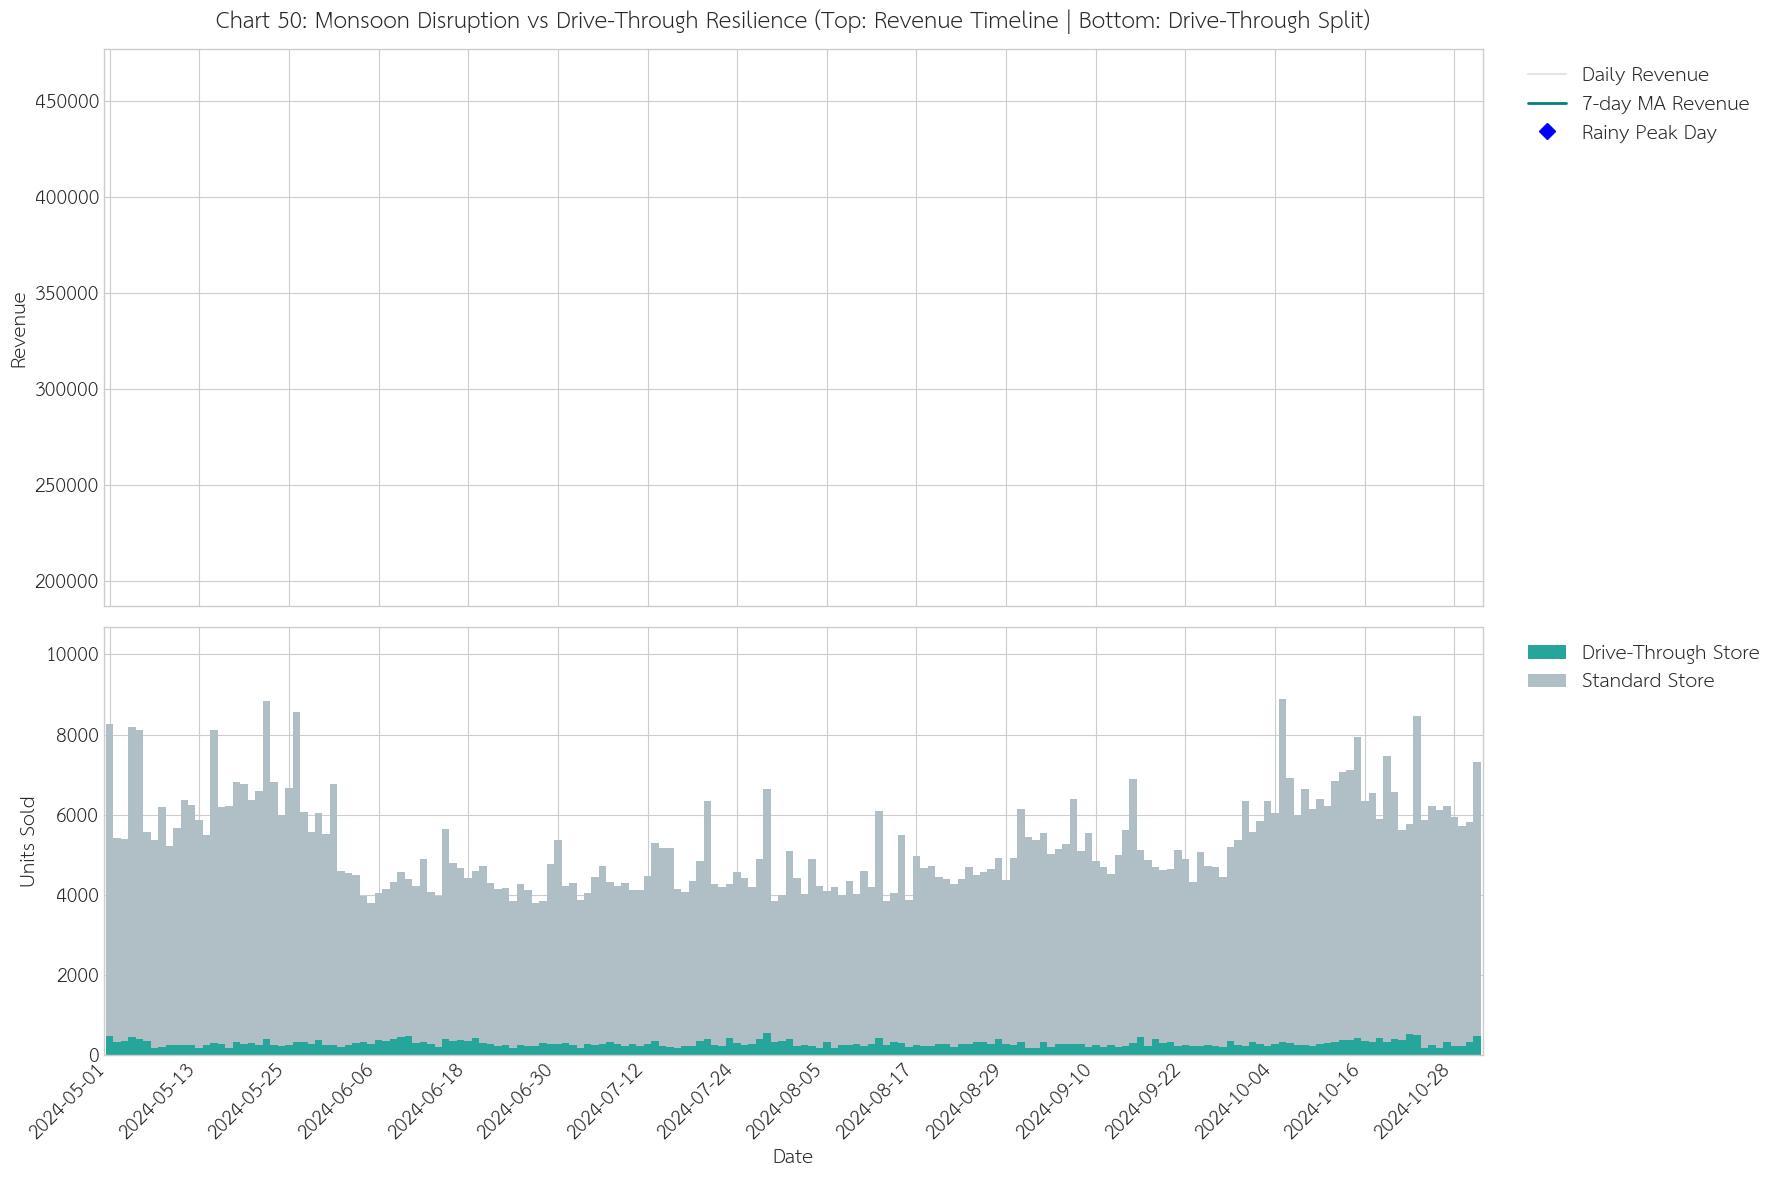

In [68]:
df_c50 = df[(df['date'] >= '2024-05-01') & (df['date'] <= '2024-10-31')].copy()
daily_tot = df_c50.groupby('date')['revenue'].sum()
daily_ma = daily_tot.rolling(7, min_periods=1).mean()
rain_days = date_dim[(date_dim['date'] >= '2024-05-01') & (date_dim['date'] <= '2024-10-31') & (date_dim['is_rainy_season'])]['date'].unique()
sample_rain = rain_days[::5]

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True, gridspec_kw={'height_ratios':[1.3, 1]})
ax0 = axes[0]
ax0.plot(daily_tot.index, daily_tot.values, color='lightgray', alpha=0.6, label='Daily Revenue')
ax0.plot(daily_ma.index, daily_ma.values, color='teal', linewidth=2, label='7-day MA Revenue')
for rd in sample_rain:
    if rd in daily_tot.index:
        ax0.plot(rd, daily_tot.loc[rd], marker='D', color='blue', markersize=8)
ax0.plot([], [], marker='D', color='blue', linestyle='None', label='Rainy Peak Day', markersize=8)
ax0.set_title('Chart 50: Monsoon Disruption vs Drive-Through Resilience (Top: Revenue Timeline | Bottom: Drive-Through Split)', fontsize=16, pad=15)
ax0.set_ylabel('Revenue')
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

ax1 = axes[1]
df_c50['store_dt'] = np.where(df_c50['has_drive_through'], 'Drive-Through Store', 'Standard Store')
dt_split = df_c50.groupby(['date', 'store_dt'])['units_sold'].sum().unstack(fill_value=0)
dt_split.plot(kind='bar', stacked=True, color=['#26a69a', '#b0bec5'], ax=ax1, width=1.0, legend=False)
ticks = ax1.get_xticks()
step = max(1, len(ticks) // 15)
ax1.set_xticks(ticks[::step])
ax1.set_xticklabels([dt_split.index[t].strftime('%Y-%m-%d') for t in ticks[::step]], rotation=45, ha='right')
ax1.set_ylabel('Units Sold')
ax1.set_xlabel('Date')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.margins(y=0.2)
plt.tight_layout()
plt.show()

### Chart 51: S13: Bakery Inventory Holding vs Wastage Risk (Dual-Panel)
### แผนภูมิที่ 51: S13: Bakery Inventory Holding vs Wastage Risk (Dual-Panel)

**Description:**
The top panel shows average daily closing stock of Bakery items across stores. The bottom panel is a heatmap of Bakery Stockout/Wastage severity across stores over time.

**คำอธิบาย:**
แผงบนแสดง average daily closing stock ของสินค้าเบเกอรี่ทั่วสาขา แผงล่างเป็น heatmap ของความรุนแรง Bakery Stockout/Wastage ทั่วสาขาตามเวลา

**Actionable Insight (Product/Solution Opportunity):**
Reveals 'Perishable Buffer Mismanagement'. Notice how Office stores maintain high stock levels on Fridays (top panel) but experience severe wastage spikes on weekends. The solution is an **'AI Perishable Rebalancer'** that automatically throttles fresh pastry deliveries to Office branches on Friday mornings.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
เผย 'Perishable Buffer Mismanagement' สาขา Office รักษาระดับสต็อกสูงวันศุกร์ (แผงบน) แต่ประสบสไปก์การเสียของรุนแรงวันหยุดสุดสัปดาห์ วิธีแก้คือ **'AI Perishable Rebalancer'** ที่ throttle การส่งเบเกอรี่สดไปสาขา Office ตอนเช้าวันศุกร์อัตโนมัติ

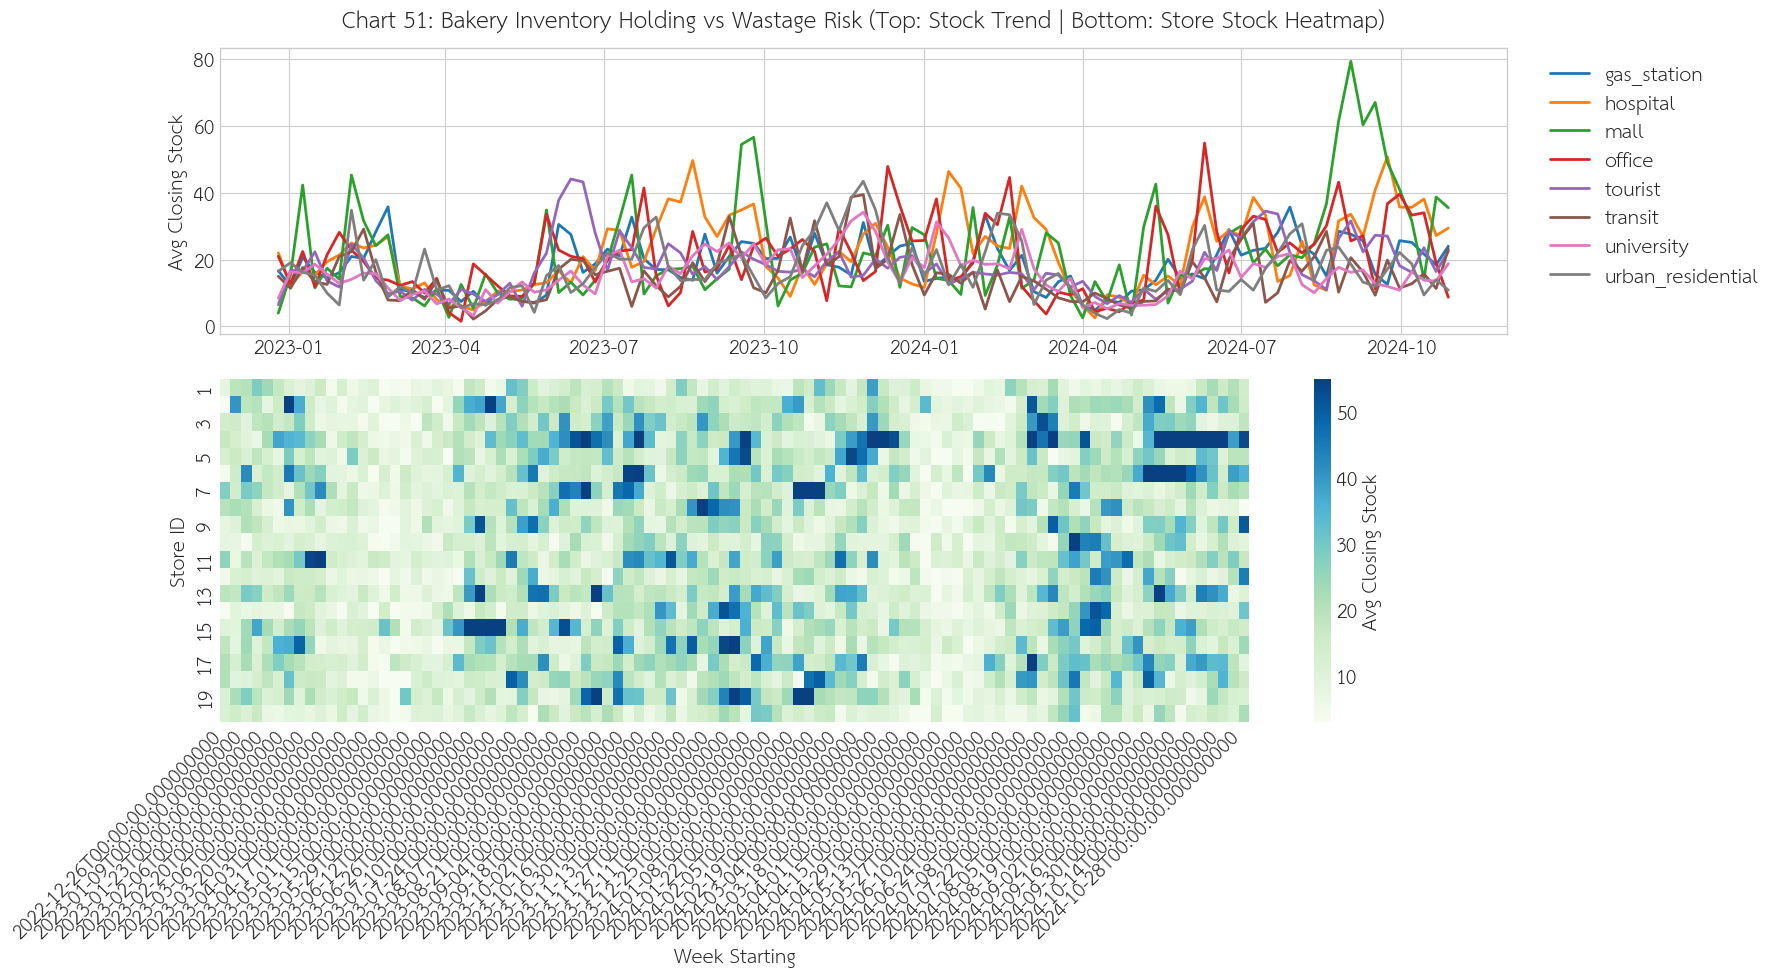

In [69]:
inv_bakery = inventory[inventory['product_id'] == 5].copy()
inv_bakery['week'] = inv_bakery['date'].dt.to_period('W').dt.start_time
inv_bakery = inv_bakery.merge(store[['store_id', 'neighborhood_type']], on='store_id', how='left')
weekly_stk = inv_bakery.groupby(['week', 'neighborhood_type'])['closing_stock'].mean().reset_index()
stk_pivot = inv_bakery.pivot_table(index='store_id', columns='week', values='closing_stock', aggfunc='mean').fillna(0)

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])
ax0 = fig.add_subplot(gs[0])
sns.lineplot(data=weekly_stk, x='week', y='closing_stock', hue='neighborhood_type', palette='tab10', linewidth=2, ax=ax0)
ax0.set_title('Chart 51: Bakery Inventory Holding vs Wastage Risk (Top: Stock Trend | Bottom: Store Stock Heatmap)', fontsize=16, pad=15)
ax0.set_ylabel('Avg Closing Stock')
ax0.set_xlabel('')
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

ax1 = fig.add_subplot(gs[1])
sns.heatmap(stk_pivot, cmap='GnBu', cbar_kws={'label': 'Avg Closing Stock'}, ax=ax1, robust=True)
ax1.set_ylabel('Store ID')
ax1.set_xlabel('Week Starting')
plt.margins(y=0.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 52: S14: The 4-Day Holiday Bridge Exodus Grid (Multi-Facet Grid)
### แผนภูมิที่ 52: S14: The 4-Day Holiday Bridge Exodus Grid (Multi-Facet Grid)

**Description:**
A 4-quadrant FacetGrid comparing Office, Mall, Urban Residential, and Tourist stores during a major 4-day long holiday bridge (April 12 - April 16). Stacked bars display daily revenue by product category.

**คำอธิบาย:**
FacetGrid 4 ส่วนเปรียบเทียบสาขา Office, Mall, Urban Residential และ Tourist ในช่วงสะพานวันหยุดยาว 4 วัน (12-16 เมษายน) Stacked bars แสดงรายได้รายวันตามหมวดสินค้า

**Actionable Insight (Product/Solution Opportunity):**
The absolute ultimate proof of 'Holiday Bridge Nomadism'. During the Songkran 4-day bridge, Office store sales drop to zero, Residential stores remain flat, but Mall and Tourist stores explode. The solution is a **'National Holiday Logistics Protocol'**—freezing suburban deliveries and rerouting all backup inventory and mobile barista kiosks directly to Mall and Tourist hubs.

**Insight ที่นำไปใช้ได้ (โอกาสสร้างผลิตภัณฑ์/โซลูชัน):**
หลักฐานขั้นสูงสุดของ 'Holiday Bridge Nomadism' ในช่วงสะพาน Songkran 4 วัน ยอดขาย Office ดิ่งเป็นศูนย์ สาขา Residential คงที่ แต่สาขา Mall และ Tourist ระเบิด วิธีแก้คือ **'National Holiday Logistics Protocol'** หยุดการส่งสินค้าชานเมืองและกำหนดเส้นทางสต็อกสำรองและ mobile barista kiosks ทั้งหมดไปยัง Mall และ Tourist hubs โดยตรง

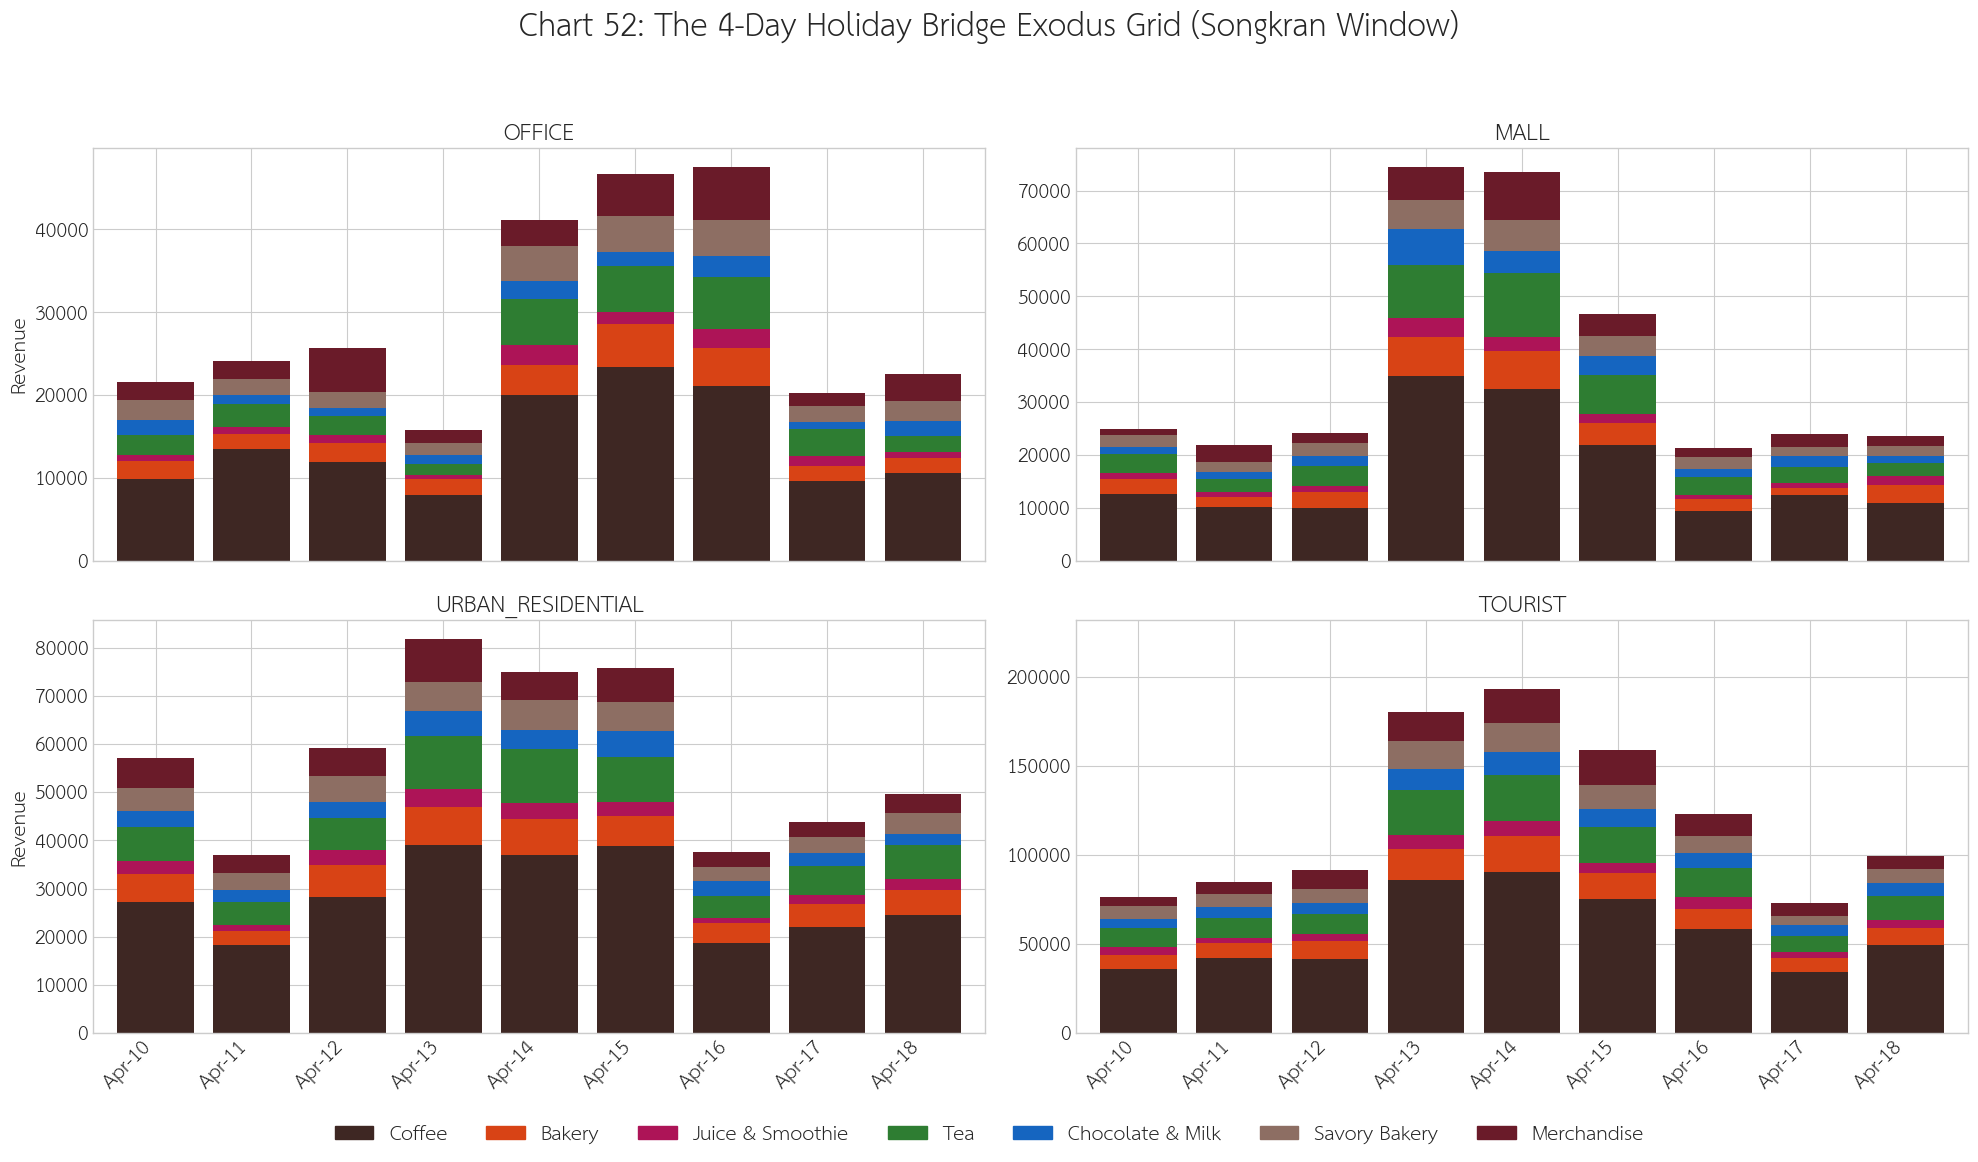

In [70]:
bridge_df = df[(df['date'] >= '2024-04-10') & (df['date'] <= '2024-04-18')].copy()
target_nhs = ['office', 'mall', 'urban_residential', 'tourist']
bridge_df = bridge_df[bridge_df['neighborhood_type'].isin(target_nhs)]
bridge_grp = bridge_df.groupby(['neighborhood_type', 'date', 'category'])['revenue'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex=True)
axes = axes.flatten()
cats = ['Coffee', 'Bakery', 'Juice & Smoothie', 'Tea', 'Chocolate & Milk', 'Savory Bakery', 'Merchandise']
colors = ['#3e2723', '#d84315', '#ad1457', '#2e7d32', '#1565c0', '#8d6e63', '#6a1b29']
cat_col_map = dict(zip(cats, colors))

for i, nh in enumerate(target_nhs):
    ax = axes[i]
    nh_data = bridge_grp[bridge_grp['neighborhood_type'] == nh]
    pivot_b = nh_data.pivot_table(index='date', columns='category', values='revenue', aggfunc='sum').fillna(0)
    pivot_b = pivot_b.reindex(columns=[c for c in cats if c in pivot_b.columns], fill_value=0)
    pivot_b.plot(kind='bar', stacked=True, color=[cat_col_map[c] for c in pivot_b.columns], ax=ax, legend=False, width=0.8)
    ax.set_title(nh.upper(), fontsize=16, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Revenue' if i%2==0 else '')
    ticks = range(len(pivot_b.index))
    ax.set_xticks(ticks)
    ax.set_xticklabels([d.strftime('%b-%d') for d in pivot_b.index], rotation=45, ha='right')

handles = [plt.Rectangle((0,0),1,1, color=cat_col_map[c]) for c in cats]
fig.legend(handles, cats, bbox_to_anchor=(0.5, 0.02), loc='lower center', ncol=7, fontsize=14)
plt.suptitle('Chart 52: The 4-Day Holiday Bridge Exodus Grid (Songkran Window)', fontsize=22, fontweight='bold', y=0.98)
plt.margins(y=0.2)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

## Section 9: Coffee Product Deep-Dive & Emerging Insights

**EN:** This section zooms into individual coffee product performance, serve-type seasonality, hour-of-day demand patterns, payment-method evolution, margin dynamics, and neighbourhood taste preferences — insights not covered in previous sections.

**TH:** ส่วนนี้เจาะลึกระดับผลิตภัณฑ์กาแฟแต่ละชนิด แนวโน้มตามวิธีเสิร์ฟ รูปแบบความต้องการตามชั่วโมง วิวัฒนาการของวิธีการชำระเงิน พลวัตของ Margin และความชอบตามย่านที่ตั้งร้าน — เป็น insight ที่ยังไม่ได้วิเคราะห์ในส่วนก่อนหน้า

### Chart 53: ยอดขายรายวันแยกตามชนิดกาแฟ (Daily Coffee Sales by Product Name)

**EN:** A dual-panel time-series showing raw daily units sold (top) and the 7-day moving average (bottom) for the top-8 coffee products by total volume. The MA panel strips out day-to-day noise so you can see which product is genuinely trending up or down over the full observation period.

**TH:** กราฟ 2 แถว แถวบนแสดงยอดขายรายวันดิบ แถวล่างเป็น Moving Average 7 วัน ของกาแฟ 8 ชนิดที่ขายดีที่สุด เส้น MA ช่วยตัดสัญญาณรบกวนรายวัน ทำให้เห็นแนวโน้มที่แท้จริงในระยะยาวของแต่ละผลิตภัณฑ์

**คำถามสำคัญ (Key Questions):**
- กาแฟชนิดไหนขายดีที่สุดในวันธรรมดา และชนิดไหนขายดีในวันหยุดสุดสัปดาห์?
  *(Which coffee product dominates on weekdays vs weekends?)*
- มีสินค้าที่มีแนวโน้มขึ้นหรือลงอย่างชัดเจนในระยะยาวไหม?
  *(Are there products with a clear upward or downward trend over time?)*
- ช่วงวันหยุดนักขัตฤกษ์ทำให้อันดับสินค้าขายดีเปลี่ยนแปลงไหม?
  *(Do holiday periods shift the best-seller ranking?)*

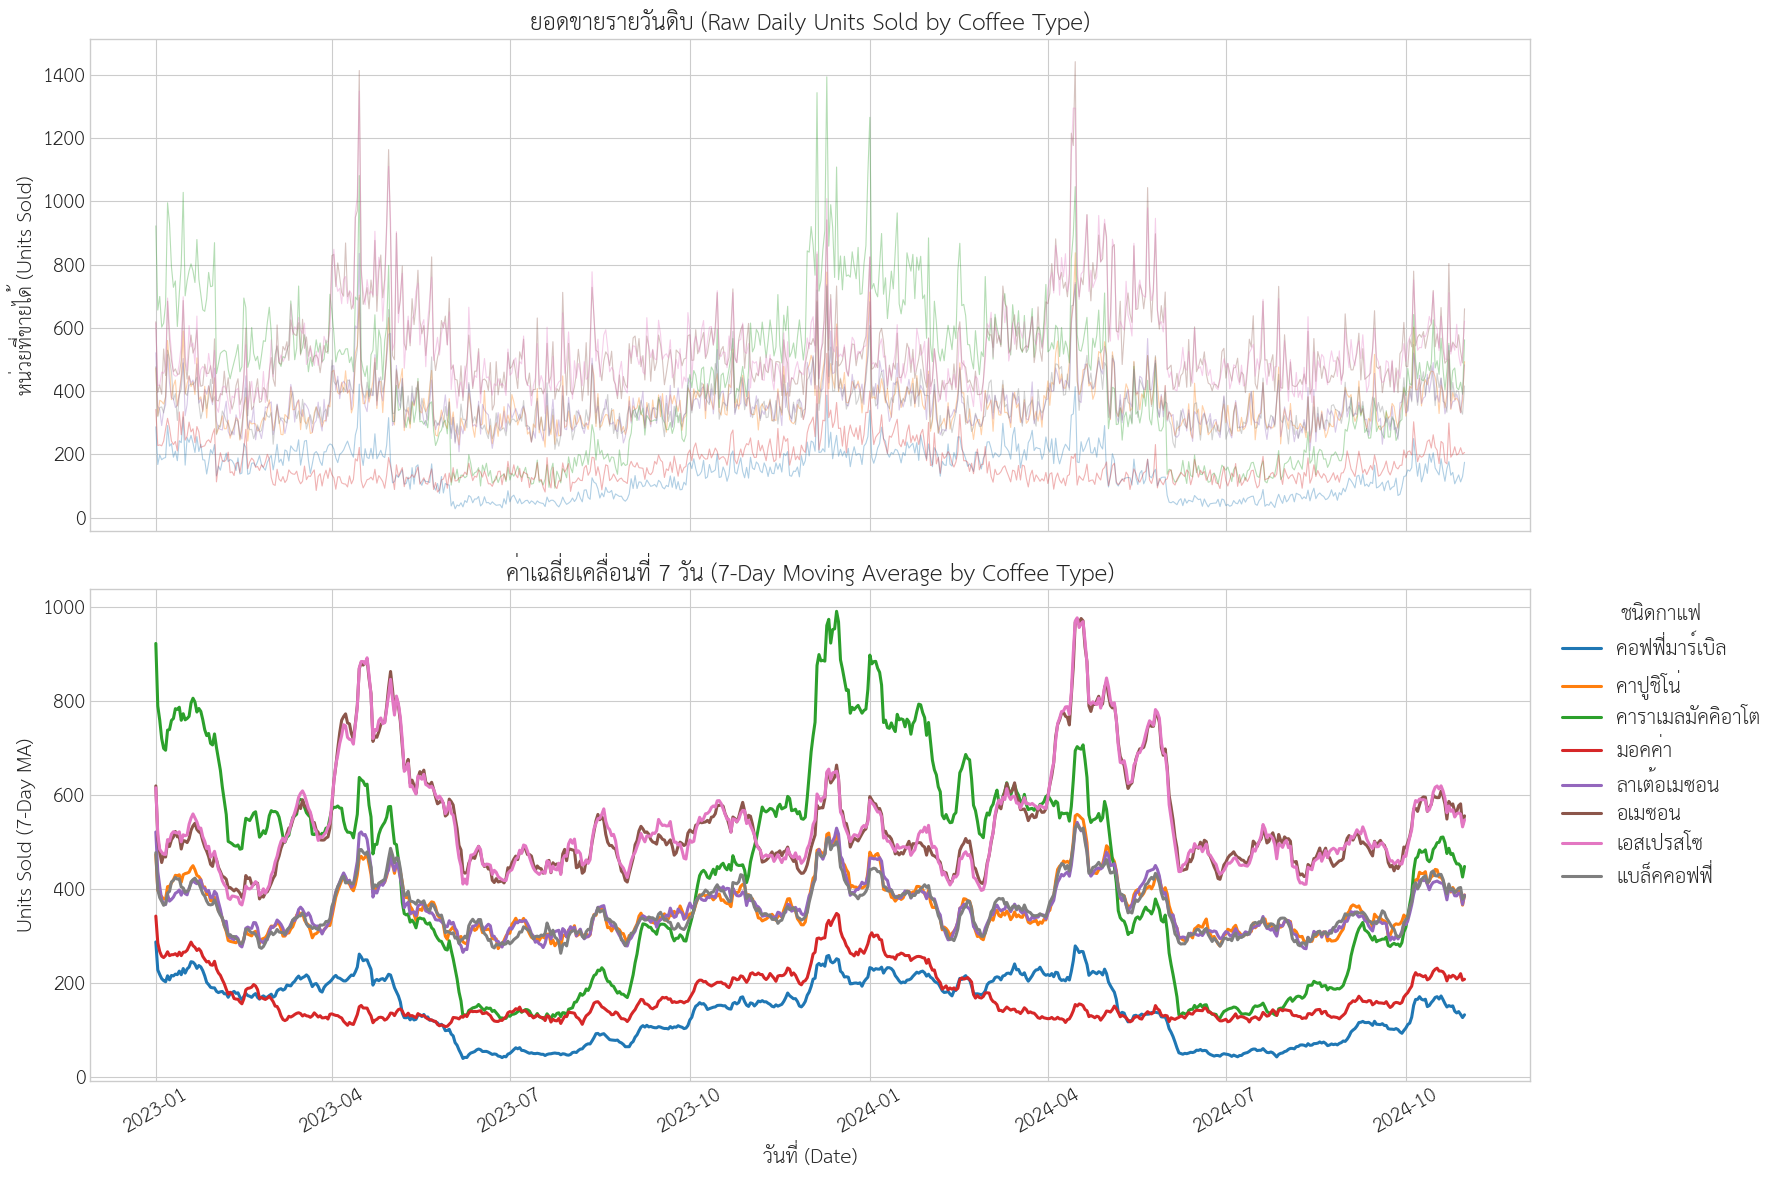

Best-selling coffee product (total): เอสเปรสโซ


In [71]:
# Chart 53: Daily Coffee Sales by Product Name — Time Series
coffee = df[df['category'] == 'Coffee'].copy()
coffee['date'] = pd.to_datetime(coffee['date'])

top_names = coffee.groupby('product_name')['units_sold'].sum().nlargest(8).index.tolist()
daily = (
    coffee[coffee['product_name'].isin(top_names)]
    .groupby(['date', 'product_name'])['units_sold'].sum()
    .reset_index()
)

pivot = daily.pivot(index='date', columns='product_name', values='units_sold').fillna(0).sort_index()
pivot_ma = pivot.rolling(7, min_periods=1).mean()

palette = sns.color_palette('tab10', len(top_names))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

for col, color in zip(pivot.columns, palette):
    ax1.plot(pivot.index, pivot[col], alpha=0.35, linewidth=0.8, color=color)
ax1.set_title('ยอดขายรายวันดิบ (Raw Daily Units Sold by Coffee Type)', fontsize=16, fontweight='bold')
ax1.set_ylabel('หน่วยที่ขายได้ (Units Sold)')

for col, color in zip(pivot_ma.columns, palette):
    ax2.plot(pivot_ma.index, pivot_ma[col], linewidth=2.2, color=color, label=col)
ax2.set_title('ค่าเฉลี่ยเคลื่อนที่ 7 วัน (7-Day Moving Average by Coffee Type)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Units Sold (7-Day MA)')
ax2.set_xlabel('วันที่ (Date)')
ax2.legend(title='ชนิดกาแฟ', bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.9)

for ax in (ax1, ax2):
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('chart_53_coffee_daily_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Best-selling coffee product (total):', coffee.groupby('product_name')['units_sold'].sum().idxmax())

### Chart 54: แนวโน้มยอดขายตามวิธีเสิร์ฟ Hot / Cold / Blended (Serve-Type Trend)

**EN:** A stacked-area chart (top = absolute units, bottom = % share) showing the monthly split of coffee sales by serve type (ร้อน = hot, เย็น = cold, ปั่น = blended/frappe). Seasonal shifts in serve-type preference are a strong demand-forecasting signal.

**TH:** กราฟ Stacked Area รายเดือน แสดงปริมาณ (แถวบน) และสัดส่วน % (แถวล่าง) ของยอดขายแยกตามวิธีเสิร์ฟ (ร้อน / เย็น / ปั่น) การเปลี่ยนแปลงตามฤดูกาลของประเภทเครื่องดื่มเป็นสัญญาณสำคัญสำหรับการพยากรณ์ความต้องการ

**สมมติฐาน (Hypothesis):**
สัดส่วนของเครื่องดื่มปั่น (ปั่น/Blended) น่าจะพุ่งสูงสุดในช่วงเมษายน–มิถุนายน ซึ่งเป็นช่วงที่ร้อนที่สุดของประเทศไทย และลดลงในช่วงธันวาคม–มกราคม
*(Blended share is expected to peak April–June, Thailand's hottest months, and dip in December–January.)*

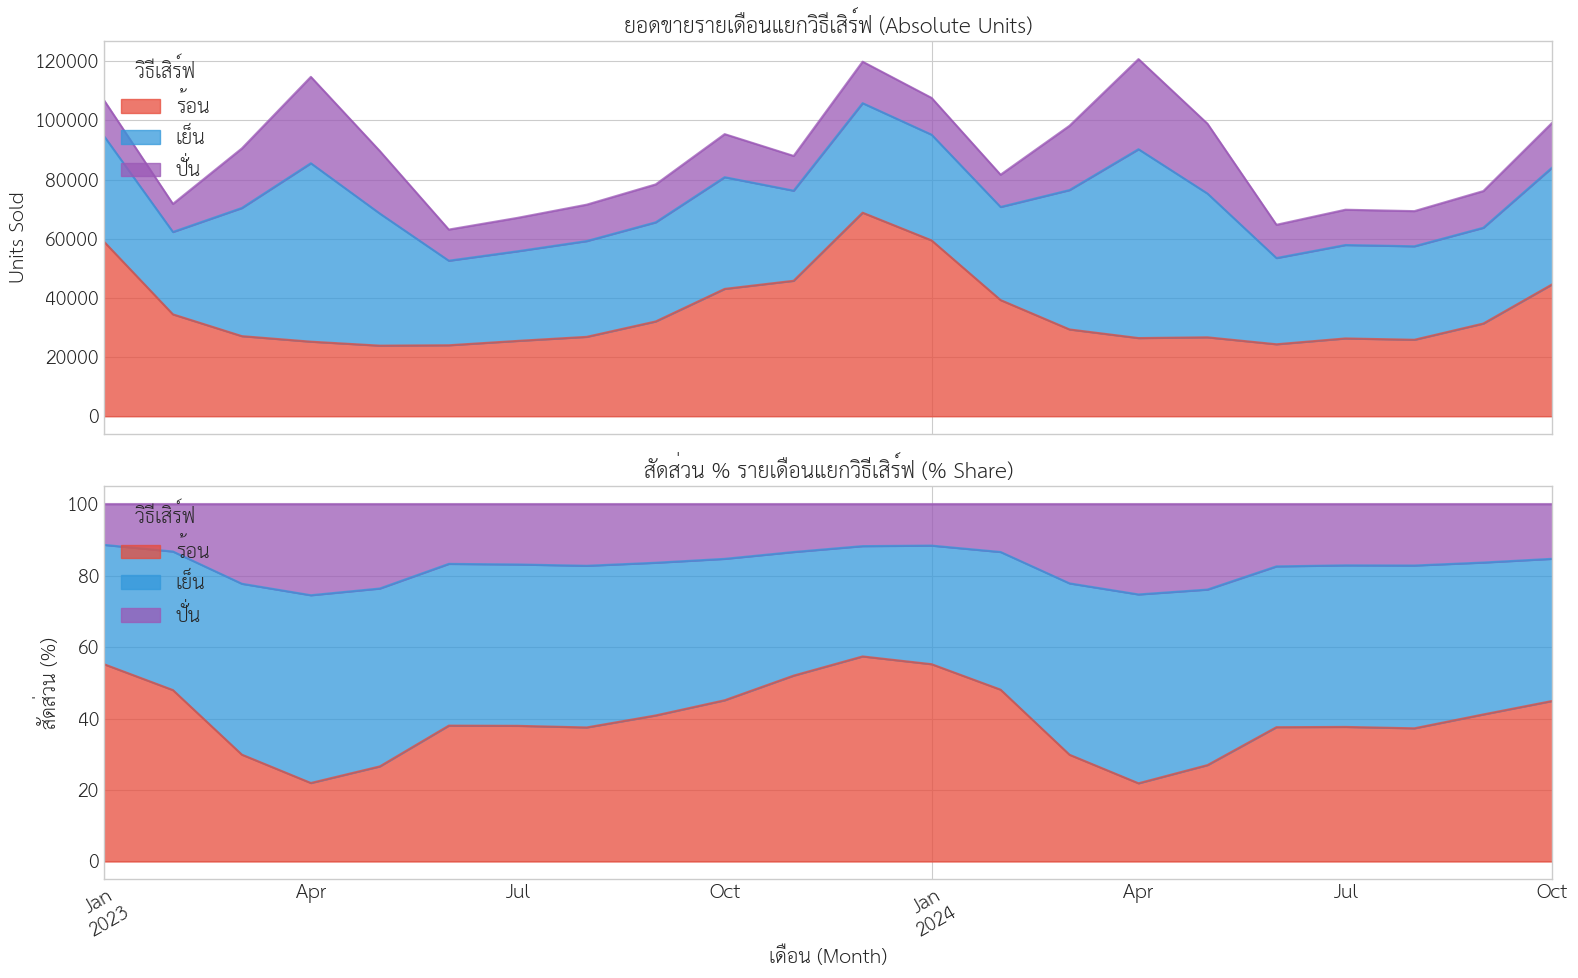

In [72]:
# Chart 54: Serve-Type Monthly Share — Stacked Area
coffee_sv = df[df['category'] == 'Coffee'].copy()
coffee_sv['date'] = pd.to_datetime(coffee_sv['date'])
coffee_sv['month'] = coffee_sv['date'].dt.to_period('M').dt.to_timestamp()

monthly_serve = (
    coffee_sv.groupby(['month', 'serve_type'])['units_sold']
    .sum().unstack().fillna(0)
)
monthly_share = monthly_serve.div(monthly_serve.sum(axis=1), axis=0) * 100

serve_colors = {'ร้อน': '#e74c3c', 'เย็น': '#3498db', 'ปั่น': '#9b59b6'}
cols_ordered = [c for c in ['ร้อน', 'เย็น', 'ปั่น'] if c in monthly_share.columns]
colors_ordered = [serve_colors.get(c, '#95a5a6') for c in cols_ordered]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

monthly_serve[cols_ordered].plot.area(ax=ax1, color=colors_ordered, alpha=0.75)
ax1.set_title('ยอดขายรายเดือนแยกวิธีเสิร์ฟ (Absolute Units)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Units Sold')
ax1.legend(title='วิธีเสิร์ฟ', loc='upper left')

monthly_share[cols_ordered].plot.area(ax=ax2, color=colors_ordered, alpha=0.75)
ax2.set_title('สัดส่วน % รายเดือนแยกวิธีเสิร์ฟ (% Share)', fontsize=15, fontweight='bold')
ax2.set_ylabel('สัดส่วน (%)')
ax2.set_xlabel('เดือน (Month)')
ax2.legend(title='วิธีเสิร์ฟ', loc='upper left')

for ax in (ax1, ax2):
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('chart_54_serve_type_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 55: Heatmap ยอดขายตามชั่วโมงและชนิดกาแฟ (Hour-of-Day × Coffee Product Heatmap)

**EN:** A heatmap crossing hour-of-day (columns) against coffee product name (rows), coloured by average units sold per transaction. Darker = higher demand. This reveals each product's peak sales window, enabling barista prep scheduling and targeted flash promotions at exactly the right hour.

**TH:** Heatmap แกน X = ชั่วโมงในวัน, แกน Y = ชนิดกาแฟ ความเข้มของสีแสดงยอดขายเฉลี่ย ช่วยให้รู้ว่ากาแฟแต่ละชนิดขายดีที่สุดช่วงเวลาใด เพื่อวางแผนการเตรียมบาริสต้า และโปรโมชัน Flash ที่ตรงเวลา

**สิ่งที่คาดว่าจะพบ (Expected Insight):**
กาแฟดำ/เอสเปรสโซน่าจะขายดีที่สุดช่วงเช้า 07:00–09:00 น. (ช่วง Morning Rush) ส่วนเครื่องดื่มปั่นน่าจะมียอดสูงสุดช่วงบ่าย 13:00–15:00 น. (หลังอาหารกลางวัน)
*(Espresso/black coffee expected to peak 07:00–09:00; blended drinks expected to peak 13:00–15:00.)*

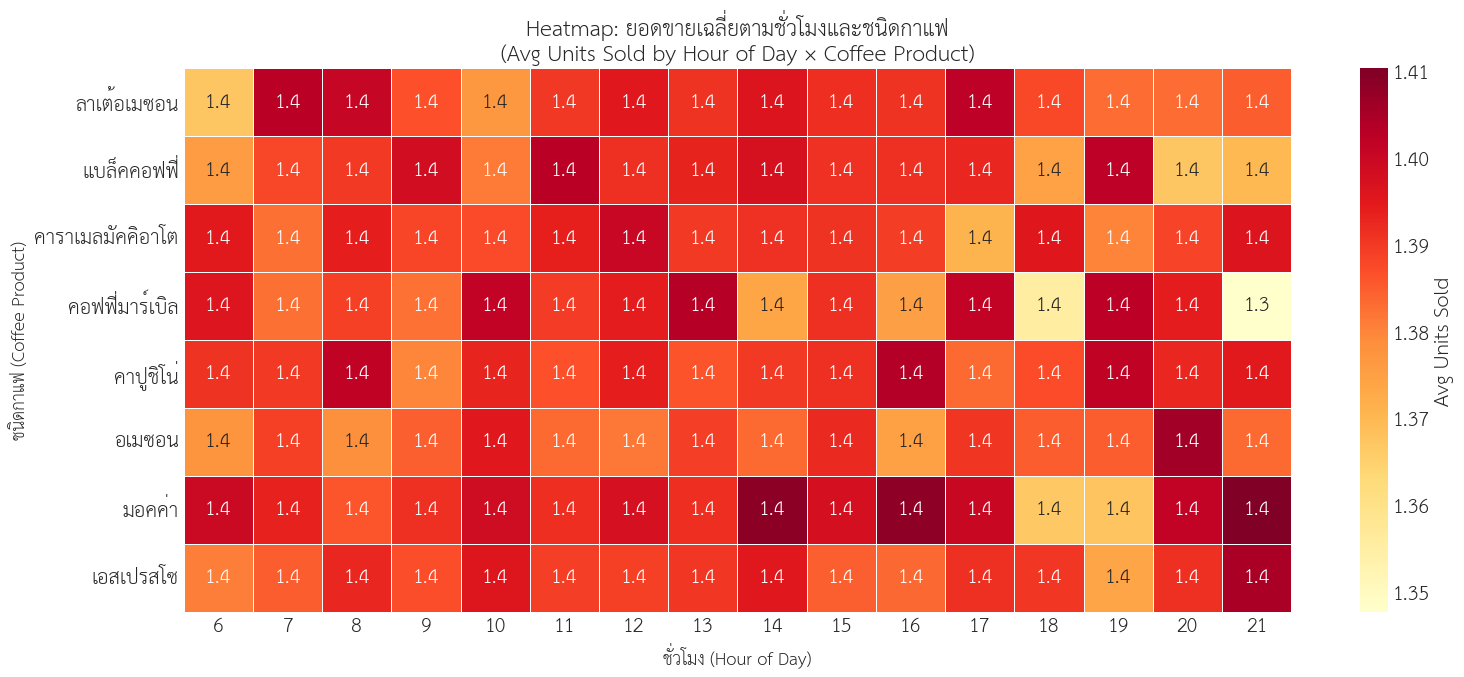

In [73]:
# Chart 55: Hour × Coffee Product Heatmap
coffee_hr = df[df['category'] == 'Coffee'].copy()

top10 = coffee_hr.groupby('product_name')['units_sold'].sum().nlargest(10).index.tolist()
coffee_hr = coffee_hr[coffee_hr['product_name'].isin(top10)]

heatmap_data = (
    coffee_hr.groupby(['product_name', 'hour'])['units_sold']
    .mean().unstack(fill_value=0)
)
# Sort rows by peak hour so the chart reads morning-to-evening top-to-bottom
heatmap_data = heatmap_data.loc[heatmap_data.idxmax(axis=1).sort_values().index]

plt.figure(figsize=(16, 7))
ax = sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    annot=True, fmt='.1f',
    cbar_kws={'label': 'Avg Units Sold'}
)
ax.set_title(
    'Heatmap: ยอดขายเฉลี่ยตามชั่วโมงและชนิดกาแฟ\n'
    '(Avg Units Sold by Hour of Day × Coffee Product)',
    fontsize=15, fontweight='bold'
)
ax.set_xlabel('ชั่วโมง (Hour of Day)', fontsize=12)
ax.set_ylabel('ชนิดกาแฟ (Coffee Product)', fontsize=12)
plt.tight_layout()
plt.savefig('chart_55_hour_product_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 56: แนวโน้มวิธีการชำระเงิน (Payment Method Trend Over Time)

**EN:** A 100% stacked bar chart (monthly) showing the evolving share of each payment method (QR/PromptPay, digital wallet, cash, etc.). A shift toward cashless payments is a key demographic signal and informs loyalty-programme design and POS infrastructure investment.

**TH:** กราฟแท่ง 100% Stacked รายเดือน แสดงสัดส่วนของแต่ละวิธีการชำระเงิน (QR/PromptPay, กระเป๋าเงินดิจิทัล, เงินสด ฯลฯ) การเปลี่ยนแปลงไปสู่การชำระแบบไร้เงินสดเป็นสัญญาณสำคัญสำหรับการออกแบบโปรแกรมสะสมคะแนน และการลงทุนโครงสร้างพื้นฐาน POS

**สมมติฐาน (Hypothesis):**
สัดส่วนของ QR/PromptPay น่าจะเพิ่มขึ้นอย่างต่อเนื่องทุกไตรมาส โดยเฉพาะในร้านที่ตั้งอยู่ในย่านมหาวิทยาลัยและโรงพยาบาลซึ่งลูกค้ามีความคุ้นเคยกับการชำระเงินดิจิทัลสูง
*(QR/PromptPay share is expected to grow quarter-on-quarter, especially at university & hospital stores.)*

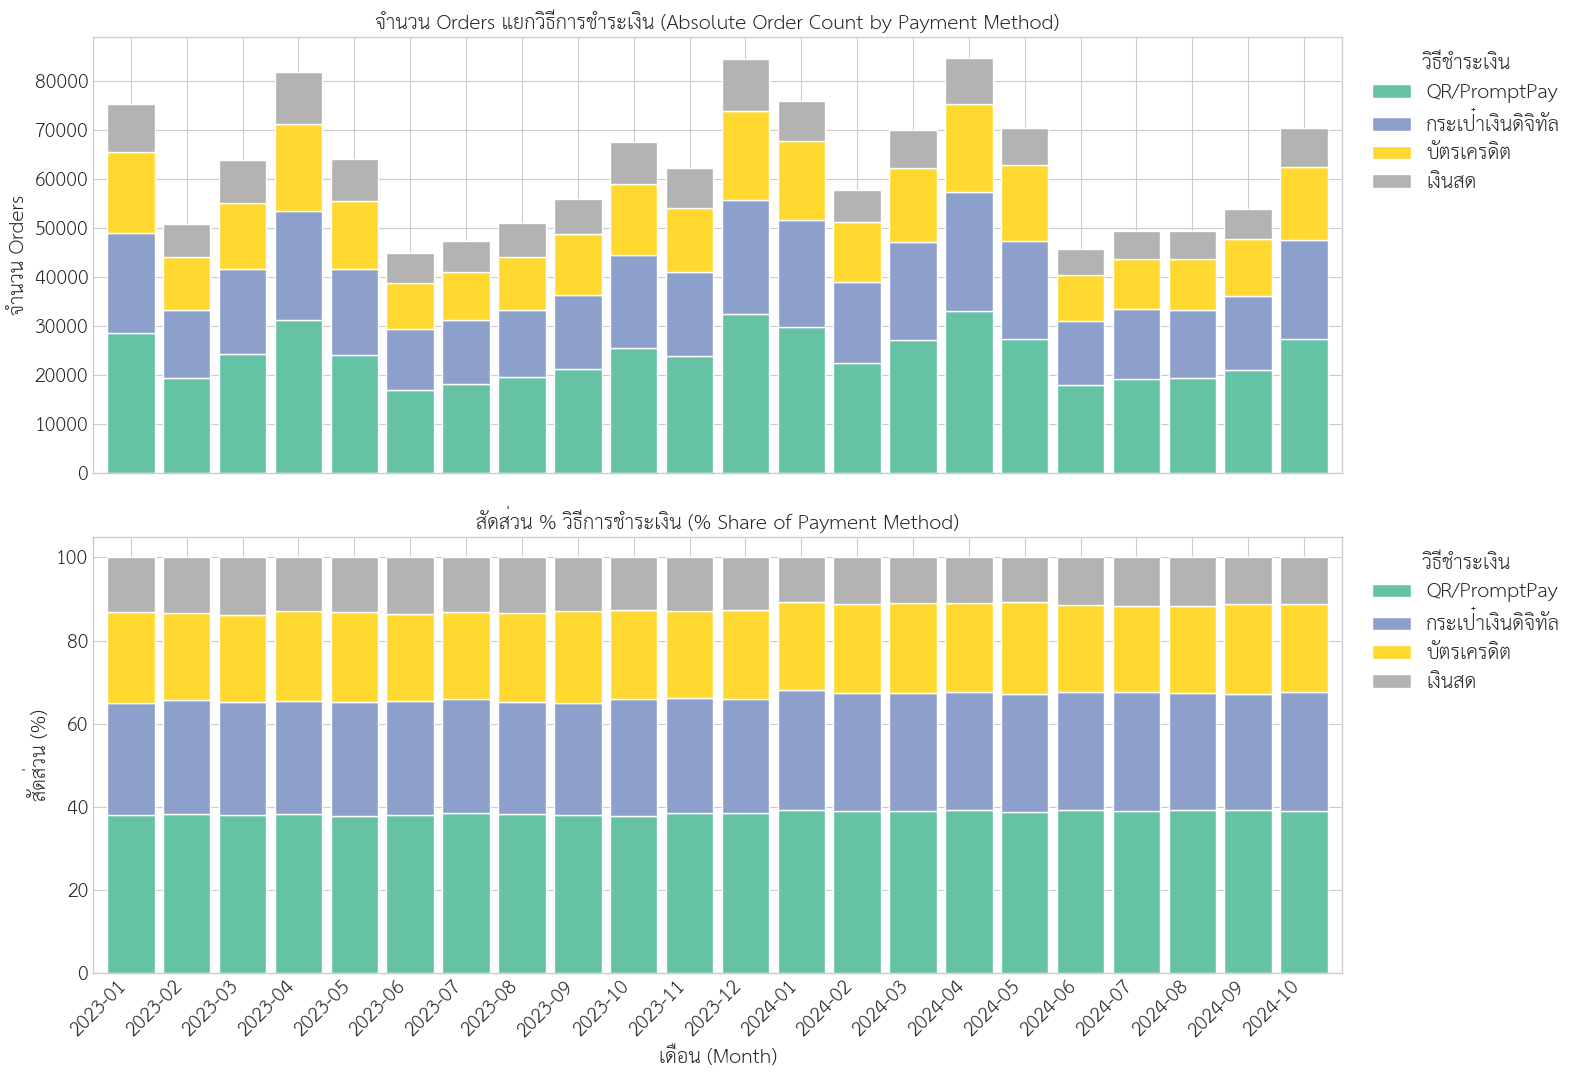

Most popular payment method overall: QR/PromptPay


In [74]:
# Chart 56: Payment Method Trend — Monthly % Share
pay_monthly = (
    order.copy()
    .assign(month=lambda x: pd.to_datetime(x['date']).dt.to_period('M').dt.to_timestamp())
    .groupby(['month', 'payment_method'])['order_id'].nunique()
    .unstack(fill_value=0)
)
pay_share = pay_monthly.div(pay_monthly.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 11), sharex=True)

pay_monthly.plot(kind='bar', stacked=True, ax=ax1, colormap='Set2', width=0.85, edgecolor='white')
ax1.set_title('จำนวน Orders แยกวิธีการชำระเงิน (Absolute Order Count by Payment Method)',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('จำนวน Orders')
ax1.legend(title='วิธีชำระเงิน', bbox_to_anchor=(1.01, 1), loc='upper left')
ax1.set_xticklabels([str(m)[:7] for m in pay_monthly.index], rotation=45, ha='right')

pay_share.plot(kind='bar', stacked=True, ax=ax2, colormap='Set2', width=0.85, edgecolor='white')
ax2.set_title('สัดส่วน % วิธีการชำระเงิน (% Share of Payment Method)',
              fontsize=14, fontweight='bold')
ax2.set_ylabel('สัดส่วน (%)')
ax2.set_xlabel('เดือน (Month)')
ax2.legend(title='วิธีชำระเงิน', bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.set_xticklabels([str(m)[:7] for m in pay_share.index], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('chart_56_payment_trend.png', dpi=150, bbox_inches='tight')
plt.show()

top_method = pay_monthly.sum().idxmax()
print(f'Most popular payment method overall: {top_method}')

### Chart 57: Bubble Chart ปริมาณขาย vs รายได้ต่อหน่วย (Revenue-per-Unit × Volume)

**EN:** A bubble chart where x = total units sold, y = average effective revenue per unit (after discounts), and bubble size = total revenue. Products in the top-right quadrant are high-volume AND high-margin 'Stars'. Products in the bottom-left are candidates for repricing or discontinuation. Quadrant lines are drawn at the dataset median.

**TH:** Bubble Chart ที่แกน X = ยอดขายรวม, แกน Y = รายได้เฉลี่ยต่อหน่วย (ราคาจริงหลังหักส่วนลด) และขนาด Bubble = รายได้รวม ผลิตภัณฑ์ที่อยู่ขวาบน = ขายดี + กำไรสูง (Star Products) ส่วนซ้ายล่าง = ควรพิจารณาปรับราคาหรือยกเลิก เส้นแบ่ง = ค่ามัธยฐานของชุดข้อมูล

**แนวทางปฏิบัติ (Action):**
ให้ความสำคัญกับสินค้าในกลุ่ม 'Star' (ขวาบน) ก่อนในการวางแผนโปรโมชัน และควรทบทวนสินค้าในกลุ่มซ้ายล่างทุกไตรมาสว่าควรปรับราคาหรือตัดออกจากเมนู
*(Prioritise 'Star' products in promotions; review 'Bottom-Left' products quarterly for repricing or discontinuation.)*

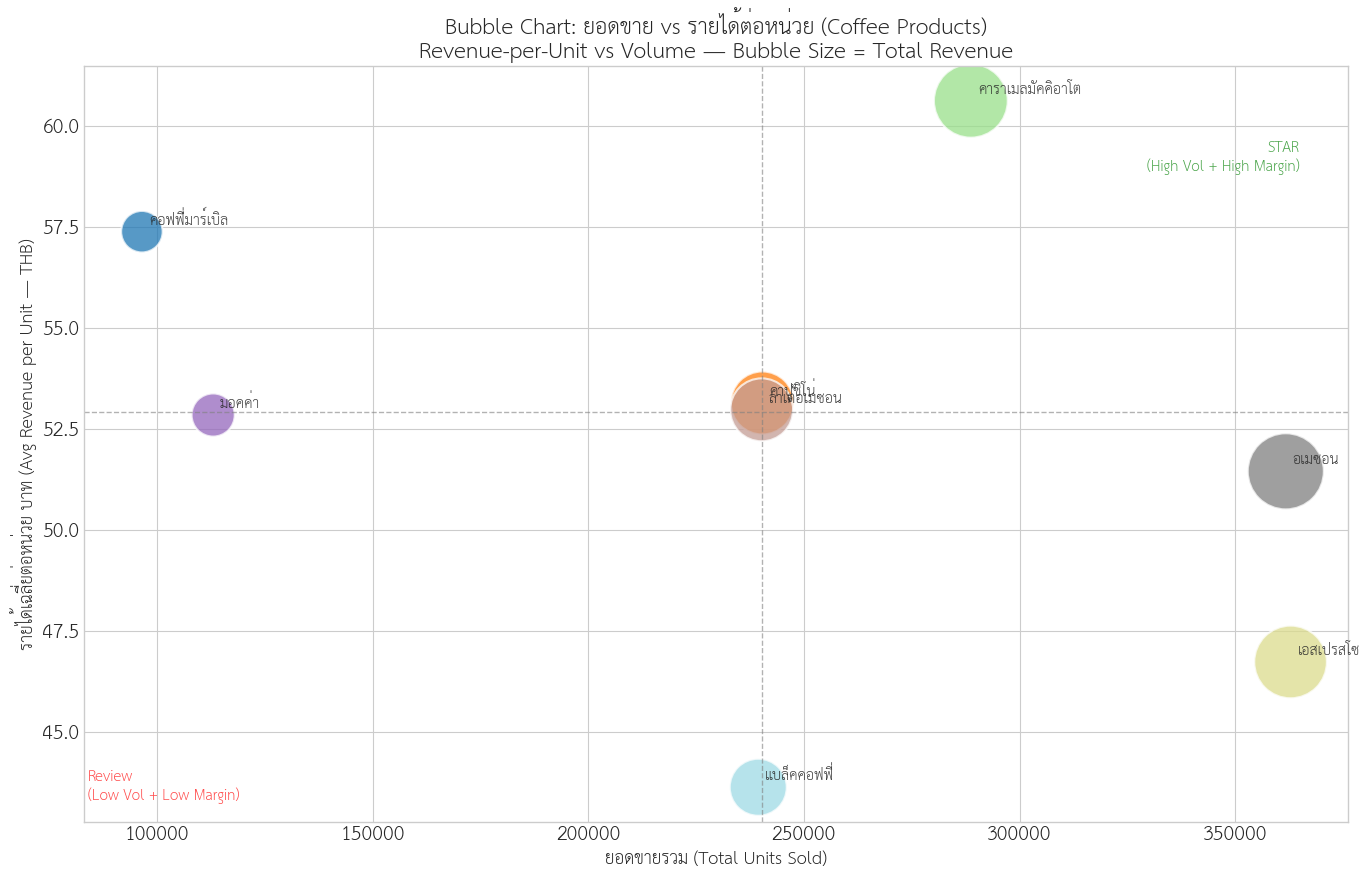

Top 3 Revenue Stars:
    product_name  total_units  avg_rev_per_unit  total_revenue
          อเมซอน       361703         51.449053    18609276.75
คาราเมลมัคคิอาโต       288687         60.619707    17500121.25
       เอสเปรสโซ       362812         46.731202    16954640.75


In [75]:
# Chart 57: Revenue-per-Unit vs Volume Bubble Chart (Coffee products)
coffee_rev = df[df['category'] == 'Coffee'].copy()

prod_stats = coffee_rev.groupby('product_name').agg(
    total_units=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()
prod_stats['avg_rev_per_unit'] = prod_stats['total_revenue'] / prod_stats['total_units']
prod_stats['bubble_size'] = (prod_stats['total_revenue'] / prod_stats['total_revenue'].max()) * 3000

plt.figure(figsize=(14, 9))
scatter = plt.scatter(
    prod_stats['total_units'],
    prod_stats['avg_rev_per_unit'],
    s=prod_stats['bubble_size'],
    c=range(len(prod_stats)),
    cmap='tab20',
    alpha=0.75,
    edgecolors='white',
    linewidths=1.5
)

med_x = prod_stats['total_units'].median()
med_y = prod_stats['avg_rev_per_unit'].median()
plt.axvline(med_x, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.axhline(med_y, color='gray', linestyle='--', linewidth=1, alpha=0.6)

for _, row in prod_stats.iterrows():
    plt.annotate(row['product_name'],
                 xy=(row['total_units'], row['avg_rev_per_unit']),
                 xytext=(5, 5), textcoords='offset points', fontsize=10, alpha=0.9)

ax = plt.gca()
xlim, ylim = ax.get_xlim(), ax.get_ylim()
plt.text(xlim[1] * 0.97, ylim[1] * 0.97,
         'STAR\n(High Vol + High Margin)', ha='right', va='top',
         fontsize=10, color='green', fontweight='bold', alpha=0.7)
plt.text(xlim[0] * 1.01, ylim[0] * 1.01,
         'Review\n(Low Vol + Low Margin)', ha='left', va='bottom',
         fontsize=10, color='red', fontweight='bold', alpha=0.7)

plt.title(
    'Bubble Chart: ยอดขาย vs รายได้ต่อหน่วย (Coffee Products)\n'
    'Revenue-per-Unit vs Volume — Bubble Size = Total Revenue',
    fontsize=15, fontweight='bold'
)
plt.xlabel('ยอดขายรวม (Total Units Sold)', fontsize=12)
plt.ylabel('รายได้เฉลี่ยต่อหน่วย บาท (Avg Revenue per Unit — THB)', fontsize=12)
plt.tight_layout()
plt.savefig('chart_57_revenue_per_unit_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

stars = prod_stats.nlargest(3, 'total_revenue')
print('Top 3 Revenue Stars:')
print(stars[['product_name', 'total_units', 'avg_rev_per_unit', 'total_revenue']].to_string(index=False))

### Chart 58: Heatmap สัดส่วนกาแฟตามประเภทย่าน (Coffee Product Mix by Neighborhood)

**EN:** A normalised heatmap (rows = neighborhood type, columns = coffee product) showing the % of coffee units each neighborhood allocates to each product. This reveals local taste differences: a university store may over-index on cheap espresso while a mall store sells more premium blended drinks. Use this to tailor the menu and promotion catalogue per branch type.

**TH:** Heatmap แสดงสัดส่วน % ของกาแฟแต่ละชนิดในแต่ละประเภทย่าน เช่น ร้านในมหาวิทยาลัยอาจขายเอสเปรสโซราคาถูกมากกว่า ขณะที่ร้านในห้างฯ ขายเครื่องดื่มปั่นราคาสูงกว่า ข้อมูลนี้ช่วยวางแผนเมนูและโปรโมชันให้เหมาะกับแต่ละสาขา

**แนวทางปฏิบัติ (Action):**
ห้ามใช้แคมเปญโปรโมชันแบบ One-Size-Fits-All กับทุกสาขา ควรออกแบบโปรโมชันให้ตรงกับความชอบของลูกค้าในแต่ละย่าน เพื่อให้ได้ผลตอบรับและอัตราการแปลง (Conversion Rate) สูงที่สุด
*(Do NOT run a one-size-fits-all campaign — tailor offers to match each neighborhood segment's preference.)*

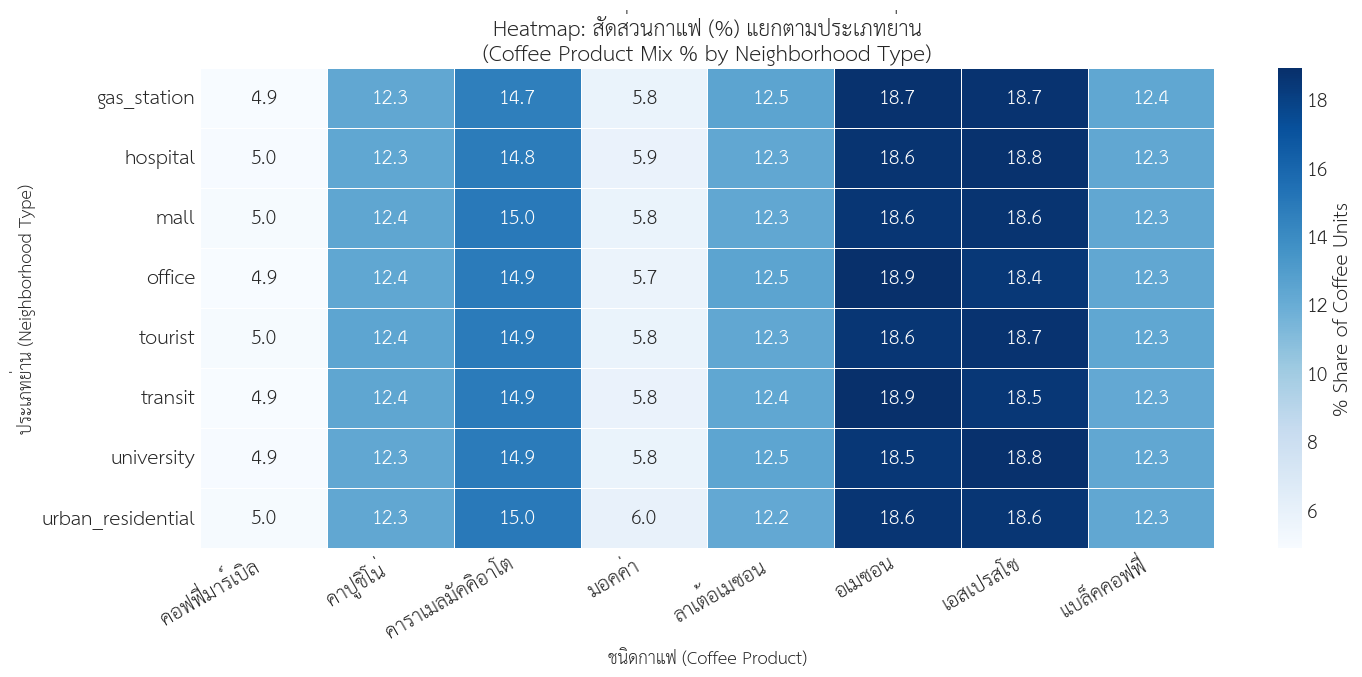

Favourite coffee product by neighborhood:
neighborhood_type
gas_station             อเมซอน
hospital             เอสเปรสโซ
mall                 เอสเปรสโซ
office                  อเมซอน
tourist              เอสเปรสโซ
transit                 อเมซอน
university           เอสเปรสโซ
urban_residential       อเมซอน


In [76]:
# Chart 58: Coffee Product Mix by Neighborhood (Normalised Heatmap)
nb_coffee = df[df['category'] == 'Coffee'].copy()

top8 = nb_coffee.groupby('product_name')['units_sold'].sum().nlargest(8).index.tolist()
nb_coffee = nb_coffee[nb_coffee['product_name'].isin(top8)]

nb_mix = (
    nb_coffee.groupby(['neighborhood_type', 'product_name'])['units_sold']
    .sum().unstack(fill_value=0)
)
nb_mix_pct = nb_mix.div(nb_mix.sum(axis=1), axis=0) * 100

plt.figure(figsize=(15, 7))
sns.heatmap(
    nb_mix_pct,
    cmap='Blues',
    annot=True, fmt='.1f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '% Share of Coffee Units'}
)
plt.title(
    'Heatmap: สัดส่วนกาแฟ (%) แยกตามประเภทย่าน\n'
    '(Coffee Product Mix % by Neighborhood Type)',
    fontsize=15, fontweight='bold'
)
plt.xlabel('ชนิดกาแฟ (Coffee Product)', fontsize=12)
plt.ylabel('ประเภทย่าน (Neighborhood Type)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart_58_neighborhood_product_mix.png', dpi=150, bbox_inches='tight')
plt.show()

fav = nb_mix_pct.idxmax(axis=1)
print('Favourite coffee product by neighborhood:')
print(fav.to_string())

### Chart 59: Discount Erosion — ราคาจริงเทียบกับราคาฐานรายเดือน (Effective vs Base Price)

**EN:** A dual-panel chart: the top panel overlays average base price vs effective price per unit (revenue ÷ units sold), with the gap shaded as discount erosion. The bottom panel shows that erosion value as a monthly bar chart. A widening gap signals that promotions are increasingly cannibalising margin — the demand model must treat the promotion calendar as an explicit feature.

**TH:** กราฟ 2 แถว แถวบนเปรียบเทียบราคาฐานเฉลี่ยกับราคาจริงเฉลี่ยต่อหน่วย โดยแรเงาช่องว่างระหว่างสองเส้นเป็น Discount Erosion แถวล่างแสดงค่า Erosion เป็นกราฟแท่งรายเดือน หากช่องห่างขยายตัวแสดงว่าโปรโมชันกำลังกัดกร่อน Margin มากขึ้นเรื่อยๆ

**นัยสำคัญต่อการพยากรณ์ (Forecast Implication):**
รายได้ต่อหน่วยไม่ใช่ค่าคงที่ — ตัวเลขนี้เปลี่ยนแปลงไปตามปฏิทินโปรโมชัน ดังนั้นโมเดลพยากรณ์ความต้องการ (Demand Forecasting Model) จำเป็นต้องรวม Feature เกี่ยวกับโปรโมชัน (ประเภท ส่วนลด ช่วงเวลา) ไว้ด้วย มิฉะนั้นโมเดลจะประเมินรายได้สูงเกินจริงอย่างเป็นระบบ
*(Revenue-per-unit is NOT constant — the model must include the promotion calendar as an explicit feature to avoid systematic overestimation of revenue.)*

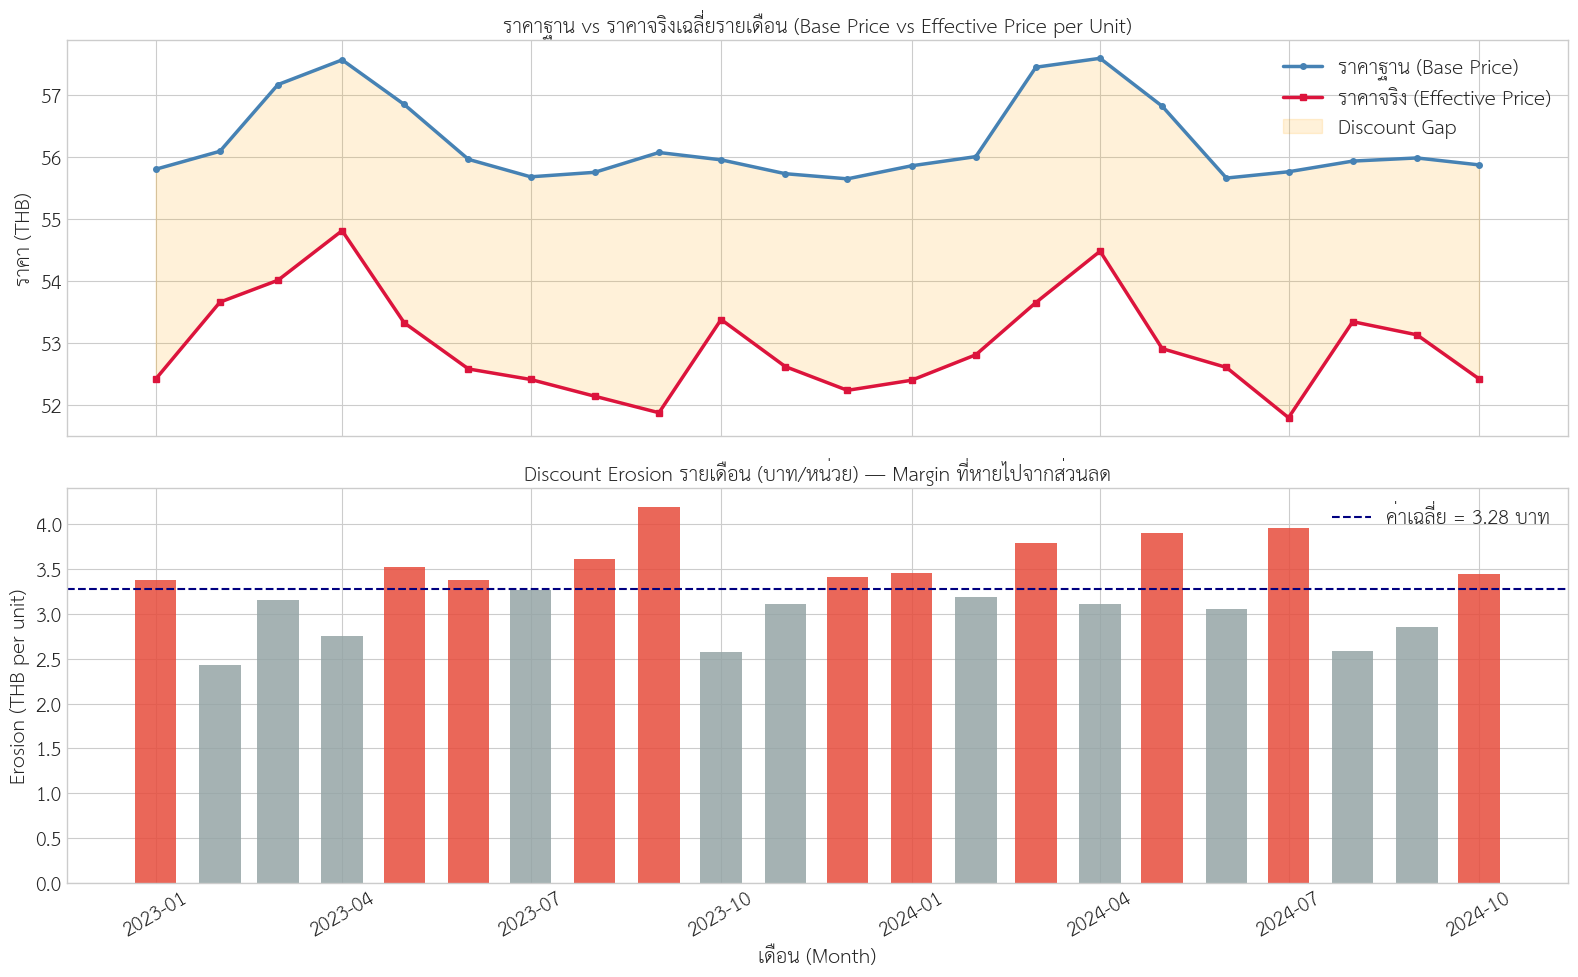

Month with highest discount erosion: 2023-09-01 00:00:00
Peak erosion: 4.19 THB per unit


In [77]:
# Chart 59: Effective Price vs Base Price — Discount Erosion
price_df = df.copy()
price_df['date'] = pd.to_datetime(price_df['date'])
price_df['month'] = price_df['date'].dt.to_period('M').dt.to_timestamp()

monthly_price = price_df.groupby('month').agg(
    avg_base_price=('base_price', 'mean'),
    total_revenue=('revenue', 'sum'),
    total_units=('units_sold', 'sum')
).reset_index()
monthly_price['effective_price'] = monthly_price['total_revenue'] / monthly_price['total_units']
monthly_price['discount_erosion'] = monthly_price['avg_base_price'] - monthly_price['effective_price']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

ax1.plot(monthly_price['month'], monthly_price['avg_base_price'],
         color='steelblue', linewidth=2.5, marker='o', markersize=4, label='ราคาฐาน (Base Price)')
ax1.plot(monthly_price['month'], monthly_price['effective_price'],
         color='crimson', linewidth=2.5, marker='s', markersize=4, label='ราคาจริง (Effective Price)')
ax1.fill_between(monthly_price['month'],
                  monthly_price['avg_base_price'],
                  monthly_price['effective_price'],
                  alpha=0.15, color='orange', label='Discount Gap')
ax1.set_title('ราคาฐาน vs ราคาจริงเฉลี่ยรายเดือน (Base Price vs Effective Price per Unit)',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('ราคา (THB)')
ax1.legend()

mean_erosion = monthly_price['discount_erosion'].mean()
bar_colors = ['#e74c3c' if v > mean_erosion else '#95a5a6'
              for v in monthly_price['discount_erosion']]
ax2.bar(monthly_price['month'], monthly_price['discount_erosion'],
        color=bar_colors, alpha=0.85, width=20)
ax2.axhline(mean_erosion, color='navy', linestyle='--', linewidth=1.5,
            label=f'ค่าเฉลี่ย = {mean_erosion:.2f} บาท')
ax2.set_title('Discount Erosion รายเดือน (บาท/หน่วย) — Margin ที่หายไปจากส่วนลด',
              fontsize=14, fontweight='bold')
ax2.set_ylabel('Erosion (THB per unit)')
ax2.set_xlabel('เดือน (Month)')
ax2.legend()

for ax in (ax1, ax2):
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('chart_59_discount_erosion.png', dpi=150, bbox_inches='tight')
plt.show()

worst_month = monthly_price.loc[monthly_price['discount_erosion'].idxmax(), 'month']
print(f'Month with highest discount erosion: {worst_month}')
print(f'Peak erosion: {monthly_price["discount_erosion"].max():.2f} THB per unit')

## Further Insights to Investigate — Research Roadmap

ตารางด้านล่างแสดง insight เพิ่มเติมที่ข้อมูลชุดนี้รองรับ แต่ยังไม่ได้วิเคราะห์ เรียงตามความสำคัญทางธุรกิจ:

| ลำดับ | Insight | ทำไมถึงน่าสนใจ | ข้อมูลที่ต้องใช้ |
|-------|---------|----------------|------------------|
| 1 | **Cross-product basket uplift** | เมื่อลูกค้าซื้อกาแฟ X มักซื้อขนมอะไรด้วย? (Market Basket Association) | TRANSACTION (order-level join) |
| 2 | **Member churn early-warning** | สมาชิกที่ไม่ได้ซื้อ 30+ วันมีแนวโน้ม Churn ไหม? | CUSTOMER + ORDER.date |
| 3 | **Limited-edition product halo effect** | สินค้า Limited Edition สร้าง Halo effect ให้สินค้าอื่นในออร์เดอร์เดียวกันไหม? | PRODUCT.is_limited_edition + TRANSACTION |
| 4 | **Inventory reorder point by product** | ระยะเวลา Stockout เฉลี่ยของแต่ละสินค้า → กำหนด Safety Stock | INVENTORY (run-length analysis) |
| 5 | **Event type × product category lift** | งาน food_festival กระตุ้นยอดขายหมวดไหนมากที่สุด? | LOCAL_EVENT + TRANSACTION |
| 6 | **Payday × product price tier** | วัน Payday ลูกค้าเปลี่ยนไปซื้อสินค้าราคาสูงขึ้นไหม? | DATE_DIM.is_payday + PRODUCT.base_price |
| 7 | **Drive-through vs dine-in basket size** | ลูกค้า Drive-Through ซื้อต่อออร์เดอร์มากกว่าหรือน้อยกว่า? | STORE.has_drive_through + ORDER |
| 8 | **Weather × serve-type granular shift** | ในฤดูฝน ลูกค้าเปลี่ยนจากเย็น/ปั่น → ร้อน ในช่วงเวลาใดของวัน? | DATE_DIM.is_rainy_season + hour + serve_type |

---

**ลำดับความสำคัญที่แนะนำ (Priority Recommendation):**

1. **Basket Uplift ระดับ Product (Cross-Product Basket Uplift)**
   Chart 37 ทำการวิเคราะห์แค่ระดับ Category เท่านั้น    หากลงลึกถึงระดับ product_name จะได้ Cross-sell Rules ที่ใช้งานได้จริงในการแนะนำสินค้า
   *(Chart 37 is category-level only — extend to product-name level for actionable cross-sell rules.)*

2. **Member Churn Early-Warning (ระบบเตือนความเสี่ยง Churn ของสมาชิก)**
   มีผลกระทบทางธุรกิจสูงมาก เพราะสมาชิกที่มี LTV สูงอาจกำลังจะหายไปโดยไม่มีสัญญาณเตือน
   *(High business impact — high-LTV members may be quietly churning with no early signal currently.)*

3. **Limited-Edition Product Halo Effect (ผลกระทบ Halo ของสินค้า Limited Edition)**
   ยังไม่มีการวิเคราะห์นี้ในโน้ตบุ๊คเลย ทั้งที่ข้อมูลมีอยู่ครบ    อาจพบว่าสินค้า Limited Edition ดึงดูดลูกค้าให้ซื้อสินค้าอื่นในออร์เดอร์เดียวกันมากขึ้นในวันเปิดตัว
   *(Completely unexplored in this notebook — could reveal a strong same-order multiplier effect on launch day.)*